# Notebook 2 — Bayesian censored spatial modelling

**Project**: Probabilistic soil-contamination mapping under detection-limit censoring at the
Santa Bárbara mercury mine, Huancavelica, Peru.

**Research question**

> When a large fraction of environmental measurements arrive as "below the detection limit", what
> can still be asserted about risk across a territory, and with how much confidence?

**The conceptual answer that organises everything**: treating censoring changes a conclusion only
when the regulatory threshold and the detection limit are of the same order of magnitude. Measured
across the whole OEFA soil archive, the median ECA/LOD ratio is 220 for mercury, 35 for lead, 14
for arsenic and **2.8 for cadmium**.

**Contents**

| Section | Milestone |
|---|---|
| 1–4 | Setup, exploratory analysis, spatial structure, anisotropy (H2) |
| 5 | Prior elicitation and prior predictive checks (H3) |
| 6 | Parameter recovery on simulated fields (H4) |
| 7 | Main hierarchical censored GP models (H5) |
| 8 | Masking experiment on real complete fields (H6) |
| 9 | Spatial cross-validation on the real data (H7) |
| 10 | Geochemical background versus mining input (H8) |
| 11 | Exceedance maps (H9) |
| 12 | Monitoring design (H10) |
| 13 | Coregionalisation and preferential sampling (H11) |
| 14 | Publication maps (H12) |

## 1. Setup

In [1]:
from __future__ import annotations

import json
import os
import sys
import time
import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 20260906
rng = np.random.default_rng(SEED)

PROJ = Path(r"c:\Users\diego\OneDrive\Documentos\ANALISIS BAYESIANO\proyecto_metales_bayesiano")
DIR_FINAL = PROJ / "data" / "final"
DIR_FIG = PROJ / "figuras"
DIR_OUT = PROJ / "outputs"
DIR_IDATA = DIR_OUT / "idata"
DIR_COV = PROJ / "data" / "fase1" / "covariables"
for d in (DIR_FIG, DIR_OUT, DIR_IDATA):
    d.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJ / "notebooks" / "_src"))

CRS_UTM = "EPSG:32718"
ECA = {"As": (50.0, 50.0, 140.0), "Pb": (70.0, 140.0, 800.0), "Cd": (1.4, 10.0, 22.0),
       "Hg": (6.6, 6.6, 24.0), "Ba": (750.0, 500.0, 2000.0)}
TRUTH_FIELDS = ["Hg", "Pb", "As"]          # H6 masking experiment
MAIN_METALS = ["Hg", "Pb", "As", "Ba", "Cd"]  # H5 main models
N_CPU = os.cpu_count()

print("Python", sys.version.split()[0], "| PyMC", pm.__version__, "| ArviZ", az.__version__)
print("CPUs available:", N_CPU)
print("Seed:", SEED)

g++ not available, if using conda: `conda install gxx`


Python 3.14.5 | PyMC 6.3.1 | ArviZ 1.2.0
CPUs available: 20
Seed: 20260906


In [2]:
MM = 1 / 25.4
W1, W15, W2 = 90 * MM, 140 * MM, 190 * MM

# Kept as a dictionary and applied through a function because third-party imports overwrite it.
# `import preliz` silently sets savefig.bbox back to "tight", which crops each figure to its content
# and shifts a 190 mm figure to 193 mm. Any import that touches matplotlib styling has to be
# followed by apply_style().
RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    # 8 pt minimum at final print size, ticks and legends included. The figure audit
    # (src/auditar_figuras.py) measured the previous values on the PDF and they were below the
    # journal floor across the whole set.
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 0.9,
    "savefig.dpi": 600, "savefig.bbox": "standard",
    "pdf.fonttype": 42, "ps.fonttype": 42, "figure.dpi": 140,
}


def apply_style():
    plt.rcParams.update(RC)


apply_style()
OI = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#56B4E9", "#CC79A7", "#F0E442", "#000000"]


def save_fig(fig, stem, dpi_tiff=600):
    """Export to vector PDF and TIFF, and verify the width that actually reached disk."""
    apply_style()                      # defend against any import that reset the style
    fig.savefig(DIR_FIG / f"{stem}.pdf")
    fig.savefig(DIR_FIG / f"{stem}.tif", dpi=dpi_tiff, pil_kwargs={"compression": "tiff_lzw"})
    declared = fig.get_size_inches()[0] * 25.4
    from PIL import Image
    actual = Image.open(DIR_FIG / f"{stem}.tif").size[0] / dpi_tiff * 25.4
    flag = "" if abs(actual - declared) < 0.6 else f"  <-- CHECK, declared {declared:.0f} mm"
    print(f"saved: {stem} | width {actual:.0f} mm | {dpi_tiff} dpi{flag}")


def to_latex(df, name, caption, label, floatfmt=3):
    d2 = df.copy()
    for c in d2.columns:
        if pd.api.types.is_float_dtype(d2[c]):
            d2[c] = d2[c].map(lambda v: "" if pd.isna(v) else f"{v:.{floatfmt}f}")
    body = d2.to_latex(index=False, escape=True,
                       column_format="l" * 2 + "r" * max(0, d2.shape[1] - 2))
    (DIR_FIG / f"{name}.tex").write_text(
        "\\begin{table}[htbp]\n\\centering\n\\caption{" + caption + "}\n\\label{" + label
        + "}\n\\footnotesize\n" + body + "\\end{table}\n", encoding="utf-8")


def save_table(df, name, caption=None, label=None, index=False, floatfmt=3):
    df.to_csv(DIR_FIG / f"{name}.csv", index=index, encoding="utf-8")
    if caption:
        to_latex(df.reset_index() if index else df, name, caption, label or name, floatfmt)
    print(f"table: {name}.csv" + (" + .tex" if caption else ""))


def scale_bar(ax, length_km=1.0, label=None, pos=(0.06, 0.04)):
    x0, y0 = ax.get_xlim()[0], ax.get_ylim()[0]
    dx, dy = np.diff(ax.get_xlim())[0], np.diff(ax.get_ylim())[0]
    xa, ya = x0 + pos[0] * dx, y0 + pos[1] * dy
    ax.plot([xa, xa + length_km], [ya, ya], color="k", lw=1.4, solid_capstyle="butt", zorder=10)
    ax.text(xa + length_km / 2, ya + 0.015 * dy, label or f"{length_km:g} km",
            ha="center", va="bottom", fontsize=8, zorder=10)


def north_arrow(ax, pos=(0.88, 0.86), length=0.06):
    ax.annotate("N", xy=(pos[0], pos[1] + length), xytext=pos, xycoords="axes fraction",
                textcoords="axes fraction", ha="center", va="bottom", fontsize=8,
                fontweight="bold",
                arrowprops=dict(arrowstyle="-|>", color="k", lw=0.8, mutation_scale=7))


def cache_idata(name, build, force=False):
    """Fit once and reuse. Keeps the notebook idempotent across reruns."""
    p = DIR_IDATA / f"{name}.nc"
    if p.exists() and not force:
        print(f"[cache] loaded {name}")
        return az.from_netcdf(p)
    t0 = time.time()
    idata = build()
    idata.to_netcdf(p)
    print(f"[fit] {name} in {time.time()-t0:.0f} s")
    return idata

## 2. Data

In [3]:
df = pd.read_csv(DIR_FINAL / "santa_barbara_soil.csv")
workings = pd.read_csv(DIR_FINAL / "mine_workings.csv")
print("rows:", len(df), "| locations:", df.location_id.nunique(), "| analytes:", df.analyte.nunique())

# One row per location with the covariates
loc = (df.drop_duplicates("location_id")
       .set_index("location_id")[["easting", "northing", "lon", "lat", "elev_oefa", "elev_dem",
                                  "slope_deg", "aspect_deg", "stratum", "sample_type", "sector",
                                  "dist_waste_dump_m", "dist_adit_m", "dist_city_m", "coord_flag"]]
       .sort_index())
print("locations table:", loc.shape)

# Coordinates in kilometres, centred: the GP length scale is then read directly in km
XY = np.c_[loc["easting"].to_numpy(float), loc["northing"].to_numpy(float)] / 1000.0
XY = XY - XY.mean(0)
DIST = np.sqrt(((XY[:, None] - XY[None]) ** 2).sum(-1))
iu = np.triu_indices(len(XY), 1)
print(f"pairwise distance (km): min {DIST[iu].min():.3f}, median {np.median(DIST[iu]):.3f}, "
      f"max {DIST[iu].max():.3f}")

# Covariates for the GP mean, standardised
COVARS = ["elev_oefa", "slope_deg", "log_dist_dump", "log_dist_city"]
loc["log_dist_dump"] = np.log(loc["dist_waste_dump_m"].clip(lower=1.0))
loc["log_dist_city"] = np.log(loc["dist_city_m"])
COV = loc[COVARS].to_numpy(float)
COV = (COV - COV.mean(0)) / COV.std(0)
print("covariates (standardised):", COVARS)

IS_BACKGROUND = (loc["stratum"] == "background").to_numpy()
IS_COMPOSITE = (loc["sample_type"] == "composite").to_numpy()
IS_UNLABELLED = (loc["stratum"] == "unlabelled").to_numpy()
print(f"background {IS_BACKGROUND.sum()} | potential interest {(~IS_BACKGROUND & ~IS_UNLABELLED).sum()} "
      f"| unlabelled {IS_UNLABELLED.sum()}")
print("stratum equals support:", bool((IS_BACKGROUND == IS_COMPOSITE).all()))


def metal_arrays(analyte):
    """Return the observation arrays for one analyte, aligned with the location table."""
    g = df[df.analyte == analyte].set_index("location_id").loc[loc.index]
    cens = g["censored"].to_numpy(bool)
    val = g["value"].to_numpy(float)
    lod = float(g["reported_limit"].iloc[0]) if np.isfinite(g["reported_limit"].iloc[0]) else np.nan
    res = float(g["resolution"].iloc[0])
    return dict(value=val, censored=cens, lod=lod, resolution=res,
                log_value=np.where(cens, np.nan, np.log(np.where(cens, 1.0, val))),
                eca=ECA.get(analyte, (np.nan,) * 3))

rows: 1140 | locations: 114 | analytes: 10
locations table: (114, 15)
pairwise distance (km): min 0.004, median 2.239, max 5.369
covariates (standardised): ['elev_oefa', 'slope_deg', 'log_dist_dump', 'log_dist_city']
background 30 | potential interest 80 | unlabelled 4
stratum equals support: True


## 3. Exploratory analysis (H2)

### 3.1 Descriptive statistics by stratum

The stratified design is the reason this site can answer a question Cuajone could not: it lets the
geochemical background be estimated from data rather than assumed.

In [4]:
rows = []
for a in MAIN_METALS + ["Co", "Sb", "Ag", "Bi", "Ni"]:
    for st in ["background", "potential_interest", "all"]:
        g = df[df.analyte == a]
        if st != "all":
            g = g[g.stratum == st]
        if not len(g):
            continue
        q = g["value"].dropna()
        thr = ECA.get(a, (np.nan,))[0]
        rows.append({
            "analyte": a, "stratum": st, "n": len(g),
            "pct_censored": 100 * g["censored"].mean(),
            "gm_quantified": float(np.exp(np.log(q).mean())) if len(q) else np.nan,
            "median_quantified": q.median() if len(q) else np.nan,
            "max_quantified": q.max() if len(q) else np.nan,
            "sd_log": float(np.std(np.log(q))) if len(q) > 2 else np.nan,
            "pct_above_eca": 100 * (g["value"] > thr).sum() / len(g) if np.isfinite(thr) else np.nan,
        })
desc = pd.DataFrame(rows).round(3)
print(desc[desc.stratum == "all"].to_string(index=False))
save_table(desc, "TABLE4_descriptives_by_stratum",
           caption="Descriptive statistics by analyte and sampling stratum. Concentrations in "
                   "mg kg$^{-1}$; sd$_{\\log}$ is the standard deviation of the natural logarithm of "
                   "the quantified values.",
           label="tab:desc")

analyte stratum   n  pct_censored  gm_quantified  median_quantified  max_quantified  sd_log  pct_above_eca
     Hg     all 114         0.000         50.872             60.625          1178.0   1.800         85.088
     Pb     all 114         0.000        401.950            386.000         58000.0   1.793         78.947
     As     all 114         0.000        108.118             91.000          1730.0   1.109         70.175
     Ba     all 114         0.000        240.383            248.150          5199.0   1.317         21.053
     Cd     all 114        79.825          8.802              7.000            46.4   0.637         20.175
     Co     all 114        37.719         11.495             11.900            75.2   0.741            NaN
     Sb     all 114        76.316        137.927            188.800          3170.0   1.245            NaN
     Ag     all 114        78.070         10.252             11.200           148.2   1.207            NaN
     Bi     all 114        84.211    

table: TABLE4_descriptives_by_stratum.csv + .tex


### 3.2 A confounding the design forces on us

The background points are not interspersed among the potential-interest points: they form two
compact clusters. So the stratum is partly a *location* label, and the stratum effect will be
partly absorbed by the spatial field. This is quantified rather than asserted.

In [5]:
def _n_clusters(d, thresh):
    """Number of single-linkage clusters at a distance threshold. Descriptive only."""
    from scipy.cluster.hierarchy import fcluster, linkage
    from scipy.spatial.distance import squareform
    dd = d.copy()
    np.fill_diagonal(dd, 0.0)
    return int(fcluster(linkage(squareform(dd, checks=False), "single"), thresh, "distance").max())


# Nearest neighbour within the same stratum against nearest in the other stratum. If the background
# points were interspersed the two would be similar; if segregated, the same-stratum neighbour is
# much closer.
D_ns = DIST.copy()
np.fill_diagonal(D_ns, np.inf)
nn_same_bg = D_ns[np.ix_(IS_BACKGROUND, IS_BACKGROUND)].min(1)
nn_other_bg = D_ns[np.ix_(IS_BACKGROUND, ~IS_BACKGROUND)].min(1)
seg_ratio = float(np.median(nn_other_bg) / np.median(nn_same_bg))
n_bg_clusters = _n_clusters(DIST[np.ix_(IS_BACKGROUND, IS_BACKGROUND)], 0.3)

print(f"background point, nearest background neighbour : median {np.median(nn_same_bg)*1000:6.0f} m")
print(f"background point, nearest other-stratum point  : median {np.median(nn_other_bg)*1000:6.0f} m")
print(f"segregation ratio                              : {seg_ratio:.1f}x")
print(f"background clusters (single linkage at 300 m)  : {n_bg_clusters}")
print("\nThe background points sit in a small number of compact clusters rather than being\n"
      "interspersed among the potential-interest points, so the stratum label carries spatial\n"
      "information as well as design information. The model can still separate the two because the\n"
      "spatial field is continuous while the stratum enters as a step, but that separation rests on\n"
      "the smoothness assumption. It is reported as a limitation, not as an estimate free of doubt.")

background point, nearest background neighbour : median     44 m
background point, nearest other-stratum point  : median    487 m
segregation ratio                              : 11.1x
background clusters (single linkage at 300 m)  : 2

The background points sit in a small number of compact clusters rather than being
interspersed among the potential-interest points, so the stratum label carries spatial
information as well as design information. The model can still separate the two because the
spatial field is continuous while the stratum enters as a step, but that separation rests on
the smoothness assumption. It is reported as a limitation, not as an estimate free of doubt.


### 3.3 Distributions and log-normality

saved: FIG2_Hg_log_distribution | width 90 mm | 600 dpi


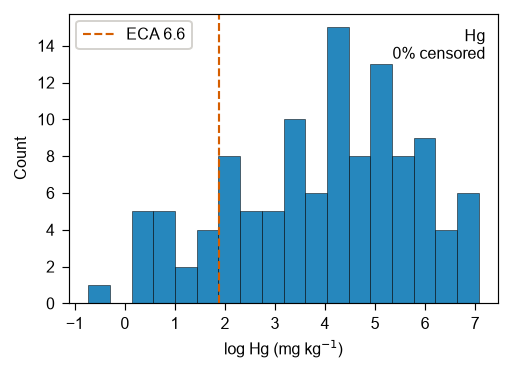

saved: FIG2_Pb_log_distribution | width 90 mm | 600 dpi


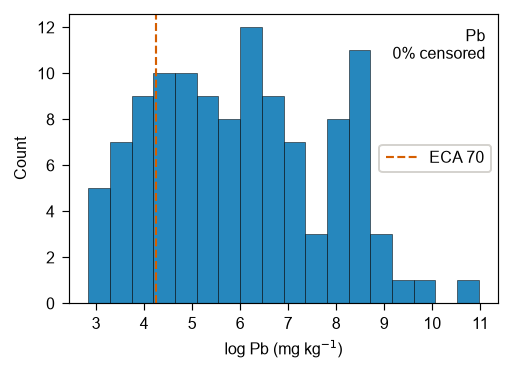

saved: FIG2_As_log_distribution | width 90 mm | 600 dpi


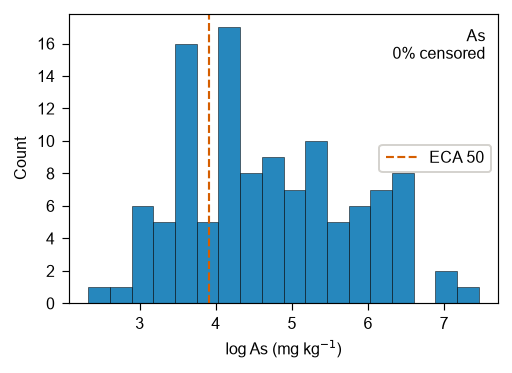

saved: FIG2_Ba_log_distribution | width 90 mm | 600 dpi


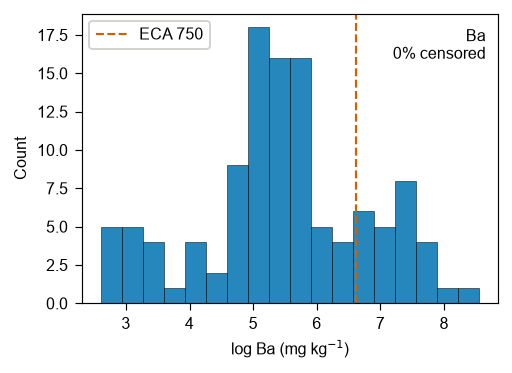

saved: FIG2_Cd_log_distribution | width 90 mm | 600 dpi


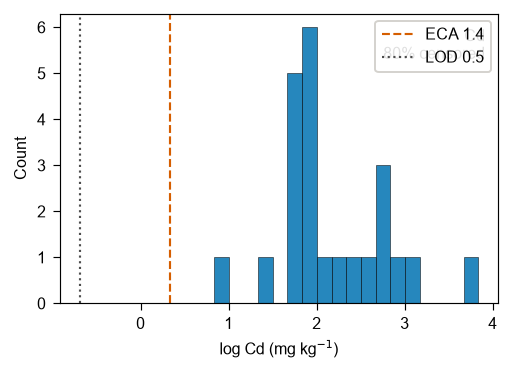

saved: FIG2_Sb_log_distribution | width 90 mm | 600 dpi


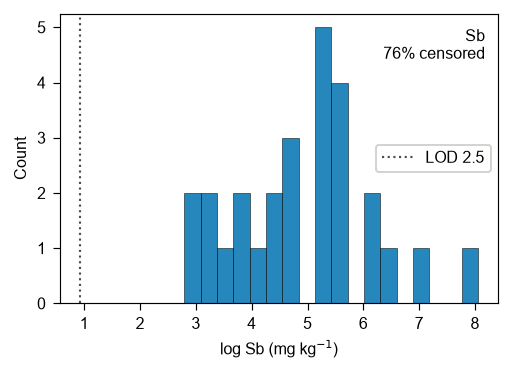

In [6]:
from scipy import stats

# One analyte per file: at most two panels per figure, and a histogram per analyte is easier to
# place in a manuscript than a six-panel block that has to be reproduced at full page width.
for a in MAIN_METALS + ["Sb"]:
    fig, ax = plt.subplots(figsize=(W1, W1 * 0.72), constrained_layout=True)
    g = df[df.analyte == a]
    q = np.log(g["value"].dropna())
    ax.hist(q, bins=18, color=OI[0], edgecolor="k", linewidth=0.3, alpha=0.85)
    thr = ECA.get(a, (np.nan,))[0]
    if np.isfinite(thr):
        ax.axvline(np.log(thr), color=OI[1], lw=1.1, ls="--", label=f"ECA {thr:g}")
    lod = g["reported_limit"].iloc[0]
    if np.isfinite(lod):
        ax.axvline(np.log(lod), color="0.3", lw=1.1, ls=":", label=f"LOD {lod:g}")
    ax.set_xlabel(f"log {a} (mg kg$^{{-1}}$)")
    ax.set_ylabel("Count")
    ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", loc="best")
    ax.text(0.97, 0.95, f"{a}\n{100 * g['censored'].mean():.0f}% censored",
            transform=ax.transAxes, ha="right", va="top", fontsize=8)
    save_fig(fig, f"FIG2_{a}_log_distribution")
    plt.show()

saved: FIG3_Hg_qq | width 90 mm | 600 dpi


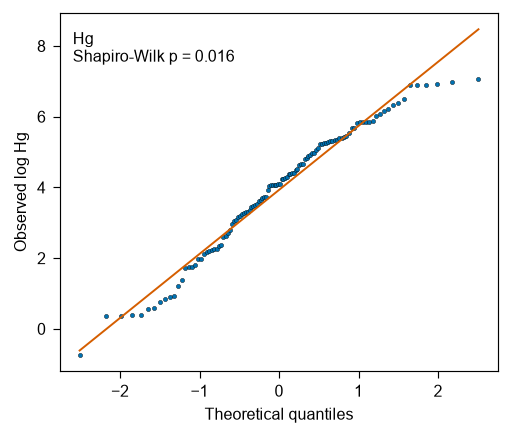

saved: FIG3_Pb_qq | width 90 mm | 600 dpi


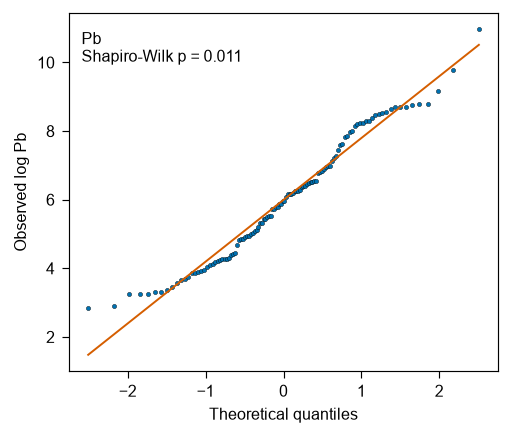

saved: FIG3_As_qq | width 90 mm | 600 dpi


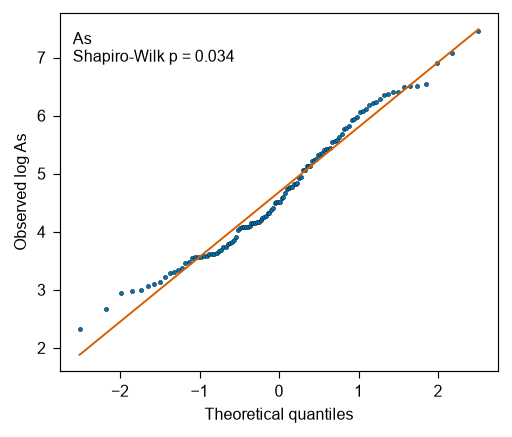


These three analytes have no censored values at all, so unlike the previous phase of this
project the quantile plot uses the complete distribution and not a truncated upper tail.


In [7]:
for a in TRUTH_FIELDS:
    fig, ax = plt.subplots(figsize=(W1, W1 * 0.85), constrained_layout=True)
    q = np.log(df[df.analyte == a]["value"].dropna())
    stats.probplot(q, dist="norm", plot=ax)
    ax.get_lines()[0].set(marker="o", markersize=2.2, markerfacecolor=OI[0],
                          markeredgecolor="k", markeredgewidth=0.2, linestyle="none")
    ax.get_lines()[1].set(color=OI[1], lw=1.0)
    ax.set_title("")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel(f"Observed log {a}")
    sw = stats.shapiro(q)
    ax.text(0.03, 0.95, f"{a}\nShapiro-Wilk p = {sw.pvalue:.3f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8)
    save_fig(fig, f"FIG3_{a}_qq")
    plt.show()
print("\nThese three analytes have no censored values at all, so unlike the previous phase of this\n"
      "project the quantile plot uses the complete distribution and not a truncated upper tail.")

## 4. Spatial structure (H2)

### 4.1 Empirical variogram

Computed on the four analytes with **zero censoring**, where no substitution is involved and the
empirical variogram is therefore unbiased. `use_nugget=True` is essential: `scikit-gstat` fixes
the nugget at zero by default, which forces the fitted model through the origin and understates
the noise fraction.

In [8]:
import skgstat as skg

VARIO_METALS = ["Hg", "Pb", "As", "Ba"]
vario_rows, variograms = [], {}
for a in VARIO_METALS:
    y = np.log(metal_arrays(a)["value"])
    for model in ["exponential", "spherical", "matern"]:
        V = skg.Variogram(XY, y, model=model, n_lags=15, maxlag=0.5 * DIST[iu].max(),
                          use_nugget=True, normalize=False)
        d = V.describe()
        vario_rows.append({"analyte": a, "model": model, "nugget": d["nugget"], "sill": d["sill"],
                           "effective_range_km": d["effective_range"],
                           "nugget_ratio": d["nugget"] / d["sill"] if d["sill"] else np.nan,
                           "rmse": V.rmse})
        if model == "exponential":
            variograms[a] = V
vario = pd.DataFrame(vario_rows).round(4)
print(vario.to_string(index=False))
save_table(vario, "TABLE5_variogram_fits",
           caption="Empirical variogram fits on the log-concentration of the four uncensored "
                   "analytes. The nugget ratio is the proportion of variance not spatially "
                   "structured.", label="tab:vario")

best = vario.loc[vario.groupby("analyte")["rmse"].idxmin()]
print("\nbest-fitting model per analyte:")
print(best[["analyte", "model", "effective_range_km", "nugget_ratio", "rmse"]].to_string(index=False))

analyte       model  nugget   sill  effective_range_km  nugget_ratio   rmse
     Hg exponential  0.0000 3.9068              2.6841        0.0000 1.2079
     Hg   spherical  0.5806 3.3432              2.6841        0.1737 1.1661
     Hg      matern  1.0617 2.8865              2.6841        0.3678 1.1826
     Pb exponential  0.0000 3.7985              1.7494        0.0000 1.4346
     Pb   spherical  0.0255 3.7907              1.6556        0.0067 1.3686
     Pb      matern  0.5997 3.1874              1.5898        0.1881 1.3971
     As exponential  0.0000 1.2714              0.8560        0.0000 0.4133
     As   spherical  0.0000 1.2679              0.7577        0.0000 0.3937
     As      matern  0.0000 1.2731              0.7141        0.0000 0.3938
     Ba exponential  0.0000 1.8919              1.2772        0.0000 0.9194
     Ba   spherical  0.0373 1.9104              1.4327        0.0195 0.8970
     Ba      matern  0.0137 1.8827              1.0953        0.0073 0.9008
table: TABLE

### 4.2 Directional variogram

`skgstat.DirectionalVariogram` fails with recent SciPy releases, so the direction-restricted
Matheron estimator is implemented directly: for each pair the azimuth is computed, pairs are kept
when their direction falls within a tolerance of the target azimuth, and the classic estimator
$\hat\gamma(h)=\frac{1}{2N(h)}\sum (z_i-z_j)^2$ is evaluated on the retained pairs.

In [9]:
def directional_variogram(xy, z, azimuth_deg, tol_deg=22.5, n_lags=12, maxlag=None):
    """Matheron estimator restricted to pairs within tol_deg of the target azimuth."""
    i, j = np.triu_indices(len(xy), 1)
    dv = xy[j] - xy[i]
    h = np.hypot(dv[:, 0], dv[:, 1])
    # azimuth measured clockwise from north, folded to [0, 180)
    az_ = (np.degrees(np.arctan2(dv[:, 0], dv[:, 1])) + 180.0) % 180.0
    target = azimuth_deg % 180.0
    diff = np.minimum(np.abs(az_ - target), 180.0 - np.abs(az_ - target))
    keep = diff <= tol_deg
    maxlag = maxlag or 0.5 * h.max()
    edges = np.linspace(0, maxlag, n_lags + 1)
    sq = 0.5 * (z[i] - z[j]) ** 2
    out = []
    for k in range(n_lags):
        m = keep & (h > edges[k]) & (h <= edges[k + 1])
        out.append({"lag_km": 0.5 * (edges[k] + edges[k + 1]), "gamma": sq[m].mean() if m.sum() else np.nan,
                    "n_pairs": int(m.sum())})
    return pd.DataFrame(out)


AZIMUTHS = [0, 45, 90, 135]

# The maximum lag has to be common to all directions, and that is dictated by the *narrow* side of
# the domain. Santa Bárbara is 2.37 km east-west and 5.37 km north-south, so beyond about 1.2 km
# there are simply no east-west pairs: the domain is not that wide. Comparing "sills" across
# directions over a lag axis that only some directions can reach measures the shape of the survey
# area, not anisotropy of the field. Both versions are computed below to make that explicit.
EXT_EW = float(np.ptp(XY[:, 0]))
EXT_NS = float(np.ptp(XY[:, 1]))
MAXLAG_COMMON = 0.5 * min(EXT_EW, EXT_NS)
print(f"domain extent: {EXT_EW:.2f} km E-W x {EXT_NS:.2f} km N-S")
print(f"common maximum lag (half the narrow side): {MAXLAG_COMMON:.2f} km")

dir_rows = []
for a in VARIO_METALS:
    y = np.log(metal_arrays(a)["value"])
    for azm in AZIMUTHS:
        for tag, ml in [("naive", 0.5 * DIST[iu].max()), ("comparable", MAXLAG_COMMON)]:
            dv = directional_variogram(XY, y, azm, n_lags=12 if tag == "naive" else 8, maxlag=ml)
            dv["analyte"], dv["azimuth"], dv["lag_scheme"] = a, azm, tag
            dir_rows.append(dv)
dirvar = pd.concat(dir_rows, ignore_index=True)
save_table(dirvar.round(4), "TABLE_S1_directional_variogram")


def anisotropy_table(scheme, q=0.6):
    out = []
    for a in VARIO_METALS:
        s, npair = {}, {}
        for azm in AZIMUTHS:
            g = dirvar[(dirvar.analyte == a) & (dirvar.azimuth == azm) & (dirvar.lag_scheme == scheme)]
            outer = g[g.lag_km > g.lag_km.quantile(q)]
            s[azm] = outer["gamma"].mean()
            npair[azm] = int(outer["n_pairs"].sum())
        vals = np.array([s[k] for k in AZIMUTHS], float)
        out.append({"analyte": a, **{f"gamma_{k}deg": s[k] for k in AZIMUTHS},
                    "min_pairs_outer": min(npair.values()),
                    "anisotropy_ratio": np.nanmax(vals) / np.nanmin(vals)})
    return pd.DataFrame(out).round(3)


aniso_naive = anisotropy_table("naive", q=0.66)
aniso = anisotropy_table("comparable", q=0.6)
print("\nNaive version (each direction taken to half its own maximum lag):")
print(aniso_naive.to_string(index=False))
print("\nComparable version (all directions capped at the common maximum lag):")
print(aniso.to_string(index=False))
save_table(aniso, "TABLE6_anisotropy",
           caption="Directional variogram sills and anisotropy ratios for the uncensored analytes, "
                   "with all azimuths restricted to a common maximum lag of "
                   f"{MAXLAG_COMMON:.2f} km imposed by the east-west extent of the survey area.",
           label="tab:aniso")
save_table(aniso_naive, "TABLE_S2_anisotropy_naive")

ANISO_MAX = float(aniso["anisotropy_ratio"].max())
USE_ANISOTROPIC = ANISO_MAX > 2.0
worst = aniso.loc[aniso["anisotropy_ratio"].idxmax(), "analyte"]
print(f"\nmaximum anisotropy ratio with comparable lags: {ANISO_MAX:.2f} (analyte {worst})")
print(f"naive maximum would have been {aniso_naive['anisotropy_ratio'].max():.2f}, inflated by the "
      f"elongated shape of the survey area")
print(f"decision: use an {'anisotropic (ARD)' if USE_ANISOTROPIC else 'isotropic'} kernel "
      f"(threshold fixed at 2.0 before inspecting the data)")

# Which direction is most continuous? The smallest semivariance marks the direction of greatest
# continuity, and that determines what an axis-aligned kernel has to represent.
mean_gamma = aniso[[f"gamma_{k}deg" for k in AZIMUTHS]].mean()
print("\nmean semivariance by azimuth across analytes:")
for k in AZIMUTHS:
    print(f"  {k:3d} deg : {mean_gamma[f'gamma_{k}deg']:.2f}")
print(f"most continuous direction: {AZIMUTHS[int(np.argmin(mean_gamma.values))]} deg "
      f"(north-south, along the valley and its drainage)")
print("An axis-aligned ARD kernel with separate length scales for easting and northing captures\n"
      "this. A full rotation angle was considered and rejected: with 114 points it adds a poorly\n"
      "identified parameter for a secondary effect.")

domain extent: 2.37 km E-W x 5.37 km N-S
common maximum lag (half the narrow side): 1.18 km


table: TABLE_S1_directional_variogram.csv



Naive version (each direction taken to half its own maximum lag):
analyte  gamma_0deg  gamma_45deg  gamma_90deg  gamma_135deg  min_pairs_outer  anisotropy_ratio
     Hg       2.259        1.625        1.776         6.503               77             4.003
     Pb       2.479        2.738        3.334         2.600               77             1.345
     As       0.713        0.963        0.829         1.114               77             1.562
     Ba       0.578        1.187        0.731         2.331               77             4.031

Comparable version (all directions capped at the common maximum lag):
analyte  gamma_0deg  gamma_45deg  gamma_90deg  gamma_135deg  min_pairs_outer  anisotropy_ratio
     Hg       1.635        2.530        2.108         2.251              128             1.547
     Pb       1.439        1.804        2.294         2.980              128             2.071
     As       0.721        0.836        1.199         2.554              128             3.543
     Ba

### 4.3 Moran's I

A second, model-free check of spatial autocorrelation, using a k-nearest-neighbour weights matrix.

In [10]:
from libpysal.weights import KNN
from esda.moran import Moran

W = KNN.from_array(XY, k=8)
W.transform = "r"
moran_rows = []
for a in VARIO_METALS + ["Cd"]:
    m = metal_arrays(a)
    if m["censored"].all():
        continue
    y = np.where(m["censored"], np.log(m["lod"] / 2), np.log(m["value"]))
    mi = Moran(y, W, permutations=999)
    moran_rows.append({"analyte": a, "morans_I": mi.I, "expected_I": mi.EI,
                       "z_score": mi.z_sim, "p_value": mi.p_sim,
                       "note": "L/2 substitution used only for this exploratory statistic"
                               if m["censored"].any() else ""})
moran = pd.DataFrame(moran_rows).round(4)
print(moran.to_string(index=False))
save_table(moran, "TABLE7_morans_i",
           caption="Moran's I of the log-concentration using an 8-nearest-neighbour row-standardised "
                   "weights matrix, with pseudo p-values from 999 permutations.", label="tab:moran")

analyte  morans_I  expected_I  z_score  p_value                                                      note
     Hg    0.6781     -0.0088  16.4286    0.001                                                          
     Pb    0.8005     -0.0088  18.9254    0.001                                                          
     As    0.4963     -0.0088  11.8988    0.001                                                          
     Ba    0.7266     -0.0088  17.6202    0.001                                                          
     Cd    0.2717     -0.0088   7.1077    0.001 L/2 substitution used only for this exploratory statistic
table: TABLE7_morans_i.csv + .tex


### 4.4 Variogram figure

saved: FIG4_variograms | width 190 mm | 600 dpi


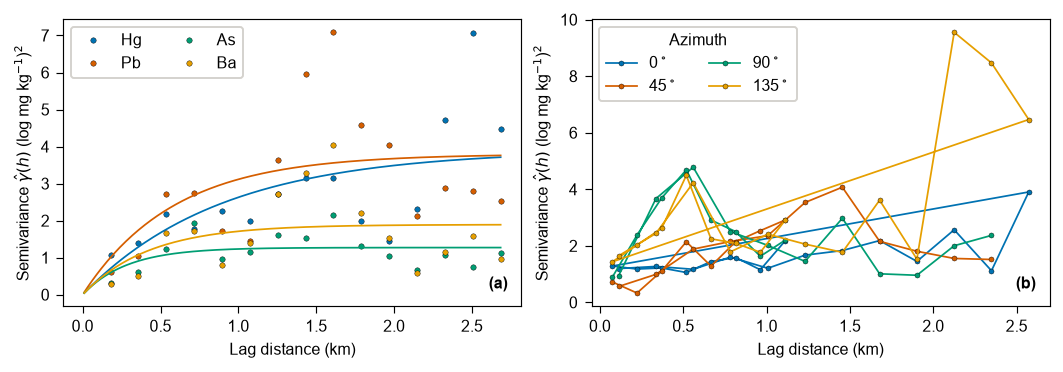

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(W2, W2 * 0.34), constrained_layout=True)

ax = axes[0]
for k, a in enumerate(VARIO_METALS):
    V = variograms[a]
    ax.plot(V.bins, V.experimental, "o", ms=2.8, color=OI[k], mec="k", mew=0.2, label=a)
    xh = np.linspace(0.01, V.bins.max(), 200)
    ax.plot(xh, V.fitted_model(xh), "-", color=OI[k], lw=0.9)
ax.set_xlabel("Lag distance (km)")
ax.set_ylabel(r"Semivariance $\hat\gamma(h)$ (log mg kg$^{-1}$)$^2$")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", ncol=2)
ax.text(0.97, 0.05, "(a)", transform=ax.transAxes, ha="right", va="bottom", fontweight="bold")

ax = axes[1]
a = "Hg"
for k, azm in enumerate(AZIMUTHS):
    g = dirvar[(dirvar.analyte == a) & (dirvar.azimuth == azm)]
    ax.plot(g.lag_km, g.gamma, "-o", ms=2.6, lw=0.9, color=OI[k], mec="k", mew=0.2,
            label=f"{azm}$^\\circ$")
ax.set_xlabel("Lag distance (km)")
ax.set_ylabel(r"Semivariance $\hat\gamma(h)$ (log mg kg$^{-1}$)$^2$")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", ncol=2, title="Azimuth", title_fontsize=8)
ax.text(0.97, 0.05, "(b)", transform=ax.transAxes, ha="right", va="bottom", fontweight="bold")

save_fig(fig, "FIG4_variograms")
plt.show()

### 4.5 What the exploratory analysis settles

The numbers above fix three modelling decisions that the rest of the notebook inherits.

In [12]:
h2 = {
    "n_locations": int(len(XY)),
    "domain_extent_km": float(DIST[iu].max()),
    "median_pair_distance_km": float(np.median(DIST[iu])),
    "domain_extent_ew_km": EXT_EW, "domain_extent_ns_km": EXT_NS,
    "anisotropy_maxlag_common_km": MAXLAG_COMMON,
    "anisotropy_ratio_max": ANISO_MAX,
    "anisotropy_ratio_max_naive": float(aniso_naive["anisotropy_ratio"].max()),
    "kernel": "anisotropic ARD Matern 5/2" if USE_ANISOTROPIC else "isotropic Matern 5/2",
    "variogram_best": best.set_index("analyte")[["model", "effective_range_km", "nugget_ratio"]].to_dict("index"),
    "morans_I": moran.set_index("analyte")[["morans_I", "p_value"]].to_dict("index"),
    "background_segregation_ratio": seg_ratio,
}
(DIR_OUT / "h2_spatial_structure.json").write_text(json.dumps(h2, indent=2), encoding="utf-8")
print(json.dumps(h2, indent=2))

{
  "n_locations": 114,
  "domain_extent_km": 5.3690894945052285,
  "median_pair_distance_km": 2.239273542913953,
  "domain_extent_ew_km": 2.367999999999995,
  "domain_extent_ns_km": 5.369000000000597,
  "anisotropy_maxlag_common_km": 1.1839999999999975,
  "anisotropy_ratio_max": 3.552,
  "anisotropy_ratio_max_naive": 4.031,
  "kernel": "anisotropic ARD Matern 5/2",
  "variogram_best": {
    "As": {
      "model": "spherical",
      "effective_range_km": 0.7577,
      "nugget_ratio": 0.0
    },
    "Ba": {
      "model": "spherical",
      "effective_range_km": 1.4327,
      "nugget_ratio": 0.0195
    },
    "Hg": {
      "model": "spherical",
      "effective_range_km": 2.6841,
      "nugget_ratio": 0.1737
    },
    "Pb": {
      "model": "spherical",
      "effective_range_km": 1.6556,
      "nugget_ratio": 0.0067
    }
  },
  "morans_I": {
    "Hg": {
      "morans_I": 0.6781,
      "p_value": 0.001
    },
    "Pb": {
      "morans_I": 0.8005,
      "p_value": 0.001
    },
    "As"

## 5. Priors: elicitation and prior predictive checks (H3)

The priors follow `notas_obsidian/Priors del GP censurado - como se definen.md`. The guiding
principle is *weakly informative on the scale of the data*, not "uninformative": a flat prior on
an unbounded scale is a strong and almost always false statement.

| Parameter | Prior | Reason |
|---|---|---|
| $\beta$ (standardised covariates) | $N(0,\,0.5)$ | A coefficient of 0.5 means one standard deviation of the covariate moves log-concentration by half a unit, a factor of 1.65. The scale is not a round guess: it comes from the prior predictive check below, which **rejected** 1.0 |
| $\beta_0$ | $N(\bar y,\, 0.7)$ | Centred on the data mean. This is empirical Bayes and is declared as such |
| $b_{\text{background}}$ | $N(0,\,0.5)$ | The stratum shift. Centred at zero, so the model is not told in advance that background is cleaner |
| $\ell$ (length scale, one per axis) | InverseGamma calibrated | A GP identifies neither $\ell$ below the typical point spacing nor above the domain diameter. The InverseGamma penalises $\ell \to 0$, the regime where the GP degenerates into noise |
| $(\eta, \sigma_n)$ | variance partition | $\sigma_{tot}\sim\text{HalfNormal}(0.7)$, $\rho\sim\text{Beta}(2,2)$, $\eta=\sigma_{tot}\sqrt{\rho}$, $\sigma_n=\sigma_{tot}\sqrt{1-\rho}$. Removes the funnel |
| $\log\tau$ (composite support) | $N(0, 0.5)$ | Multiplies the noise of composite samples. Negative means composites are less variable, the expected sign |
| $L$ (quantification limit) | $L = \mathrm{LOD}\cdot r$, $r\sim\text{TruncNormal}(3, 1)$ on $[1, \min_{det}/\mathrm{LOD}]$ | Centred at 3 because the metrological convention gives LOQ/LOD $\approx$ 3 (Currie 1968). The upper bound is not arbitrary: a value quantified at 2.3 forces the limit below 2.3 |

In [13]:
import sbmodel as sb
import preliz as pz

# preliz applies its own matplotlib style on import, which resets savefig.bbox to "tight" and would
# push every figure from here on to 193 mm instead of 190. Reapply ours.
apply_style()

ELL_PARAMS, ELL_LO, ELL_HI = sb.ell_prior_params(XY, lower_q=0.05, upper_frac=0.5, mass=0.90)
print(f"ell ~ InverseGamma(alpha={ELL_PARAMS['alpha']:.3f}, beta={ELL_PARAMS['beta']:.3f})")
print(f"90% of the prior mass between {ELL_LO:.3f} and {ELL_HI:.3f} km")
print(f"  lower edge  = 5th percentile of pairwise distances")
print(f"  upper edge  = half the maximum pairwise distance ({DIST[iu].max():.2f} km)")

ig = pz.InverseGamma(alpha=ELL_PARAMS["alpha"], beta=ELL_PARAMS["beta"])
q = ig.ppf([0.05, 0.25, 0.5, 0.75, 0.95])
print(f"prior quantiles of ell (km): 5% {q[0]:.3f}, 25% {q[1]:.3f}, median {q[2]:.3f}, "
      f"75% {q[3]:.3f}, 95% {q[4]:.3f}")

ell ~ InverseGamma(alpha=2.609, beta=2.330)
90% of the prior mass between 0.151 and 2.685 km
  lower edge  = 5th percentile of pairwise distances
  upper edge  = half the maximum pairwise distance (5.37 km)


prior quantiles of ell (km): 5% 0.409, 25% 0.676, median 1.020, 75% 1.640, 95% 3.734


### 5.1 Prior predictive check

Simulating from the prior and looking at the implied concentrations. If the prior implies mercury
at $10^6$ mg kg$^{-1}$, the prior is wrong. This is run for every main analyte because $\beta_0$
is centred on that analyte's own mean.

In [14]:
PHYSICAL_MAX = 1e6      # mg/kg. 10^6 mg/kg is 100 % of the sample mass: nothing can exceed it.


def prior_predictive_concentrations(analyte, sd_beta, sd_sigma, sd_beta0, n_sim=400, seed=SEED):
    """Draw from the prior and return the implied concentrations in mg/kg."""
    m = metal_arrays(analyte)
    y_bar = float(np.mean(np.log(m["value"][~m["censored"]])))
    r = np.random.default_rng(seed)
    out = np.empty((n_sim, len(XY)))
    for s in range(n_sim):
        beta0 = r.normal(y_bar, sd_beta0)
        beta = r.normal(0, sd_beta, size=COV.shape[1])
        b_bg = r.normal(0, sd_beta)
        ell = np.array([ig.rvs(), ig.rvs()], float)
        sigma_tot = abs(r.normal(0, sd_sigma))
        rho = r.beta(2, 2)
        eta, sn = sigma_tot * np.sqrt(rho), sigma_tot * np.sqrt(1 - rho)
        a = XY / ell
        K = eta ** 2 * sb._matern52(((a[:, None] - a[None]) ** 2).sum(-1), ell)
        K[np.diag_indices(len(XY))] += 1e-8
        f = np.linalg.cholesky(K) @ r.standard_normal(len(XY))
        out[s] = beta0 + COV @ beta + b_bg * IS_BACKGROUND + f + r.standard_normal(len(XY)) * sn
    return np.exp(out)


def prior_check_table(sd_beta, sd_sigma, sd_beta0, tag):
    """Three criteria, each stated as a property of the prior distribution rather than of one draw.

    An earlier version compared the prior's 99th percentile with the single largest observation and
    the prior's sample maximum with the physical bound. Both are the wrong shape of test: the
    maximum of 45 600 draws from a heavy-tailed prior is always extreme, and one observation should
    never decide whether a prior is acceptable. Lead makes the point — its largest value, 58 000
    mg kg⁻¹, is 5.8 % of the sample mass, ore-grade material rather than soil.

    The criteria used instead:

    * **covers the bulk**: the prior's 99th percentile reaches the 95th percentile of the data;
    * **negligible impossible mass**: P(concentration > 10^6 mg kg⁻¹) below 1e-4, where 10^6 mg kg⁻¹
      is the entire mass of the sample;
    * **not absurdly diffuse**: the prior median stays within two orders of magnitude of the
      observed median.
    """
    rows, draws = [], {}
    for a in MAIN_METALS:
        c = prior_predictive_concentrations(a, sd_beta, sd_sigma, sd_beta0)
        draws[a] = c
        obs = df[df.analyte == a]["value"].dropna()
        p99 = float(np.quantile(c, 0.99))
        p_impossible = float(np.mean(c > PHYSICAL_MAX))
        rows.append({"prior": tag, "analyte": a,
                     "prior_p01": float(np.quantile(c, 0.01)),
                     "prior_median": float(np.median(c)), "prior_p99": p99,
                     "prior_p999": float(np.quantile(c, 0.999)),
                     "p_above_physical_bound": p_impossible,
                     "observed_median": obs.median(),
                     "observed_p95": float(obs.quantile(0.95)), "observed_max": obs.max(),
                     "covers_bulk": bool(p99 >= obs.quantile(0.95)),
                     "impossible_mass_negligible": bool(p_impossible < 1e-4),
                     "not_absurd": bool(np.median(c) < 100 * obs.median())})
    t = pd.DataFrame(rows)
    t["plausible"] = t["covers_bulk"] & t["impossible_mass_negligible"] & t["not_absurd"]
    return t, draws


# --- first attempt: unit scales everywhere, the obvious default ---------------------------
wide, _ = prior_check_table(1.0, 1.0, 1.0, "initial (all scales 1.0)")
print("FIRST ATTEMPT, scales of 1.0 on beta, sigma_tot and beta0:")
print(wide[["analyte", "prior_median", "prior_p99", "prior_p999", "p_above_physical_bound",
            "observed_median", "observed_p95", "plausible"]].round(5).to_string(index=False))
worst = wide.loc[wide["p_above_physical_bound"].idxmax()]
print(f"\nRejected. For {worst['analyte']} the prior places "
      f"{100*worst['p_above_physical_bound']:.2f}% of its mass above {PHYSICAL_MAX:.0e} mg/kg, "
      "which is\n100 % of the sample mass. A prior that puts appreciable mass on impossible values "
      "is not\n'uninformative', it is wrong.\n\n"
      "The dominant contribution is the four covariate coefficients: at scale 1.0 they add 2.0 to\n"
      "the standard deviation of the log-concentration on their own, a factor of 7.4 per standard\n"
      "deviation of a covariate, far more than any terrain effect plausibly produces.")

# --- calibrated scales, used for every model in this notebook ------------------------------
ppc_prior, pp_draws = prior_check_table(sb.SD_BETA, sb.SD_SIGMA, sb.SD_BETA0,
                                        f"calibrated (beta {sb.SD_BETA}, sigma {sb.SD_SIGMA}, "
                                        f"beta0 {sb.SD_BETA0})")
print(f"\nCALIBRATED, beta {sb.SD_BETA}, sigma_tot {sb.SD_SIGMA}, beta0 {sb.SD_BETA0}:")
print(ppc_prior[["analyte", "prior_median", "prior_p99", "p_above_physical_bound",
                 "observed_median", "observed_p95", "observed_max",
                 "covers_bulk", "impossible_mass_negligible", "not_absurd", "plausible"]]
      .round(5).to_string(index=False))

save_table(pd.concat([wide, ppc_prior], ignore_index=True).round(3), "TABLE8_prior_predictive",
           caption="Prior predictive check, before and after calibration. Concentrations implied by "
                   "the priors in mg kg$^{-1}$. The initial scales imply concentrations above "
                   "$10^6$ mg kg$^{-1}$, which is the whole mass of the sample.",
           label="tab:priorpred")

assert ppc_prior["plausible"].all(), "the calibrated prior is still not plausible"
print("\nThe calibrated prior covers the observed range at its 99th percentile, stays within the\n"
      "physical bound, and is not absurdly diffuse. These are the scales used by every model in\n"
      "this notebook. The rejected first attempt is kept in the table because it is the evidence\n"
      "that the check does its job.")

FIRST ATTEMPT, scales of 1.0 on beta, sigma_tot and beta0:
analyte  prior_median    prior_p99   prior_p999  p_above_physical_bound  observed_median  observed_p95  plausible
     Hg      55.03312  23040.97521 6.800803e+05                 0.00061           60.625       780.865      False
     Pb     426.92717 192025.52859 5.190049e+06                 0.00342          386.000      6181.950      False
     As     113.77920  54221.35755 1.365856e+06                 0.00140           91.000       662.105      False
     Ba     251.13123 115177.14022 2.668570e+06                 0.00250          248.150      1857.800      False
     Cd       9.34119   3854.07802 1.035132e+05                 0.00009            7.000        21.620       True

Rejected. For Pb the prior places 0.34% of its mass above 1e+06 mg/kg, which is
100 % of the sample mass. A prior that puts appreciable mass on impossible values is not
'uninformative', it is wrong.

The dominant contribution is the four covariate coeffici


CALIBRATED, beta 0.5, sigma_tot 0.7, beta0 0.7:
analyte  prior_median   prior_p99  p_above_physical_bound  observed_median  observed_p95  observed_max  covers_bulk  impossible_mass_negligible  not_absurd  plausible
     Hg      52.53712  1690.83771                 0.00000           60.625       780.865        1178.0         True                        True        True       True
     Pb     417.87364 13805.50762                 0.00002          386.000      6181.950       58000.0         True                        True        True       True
     As     112.08713  3489.28009                 0.00000           91.000       662.105        1730.0         True                        True        True       True
     Ba     249.05645  8496.47250                 0.00002          248.150      1857.800        5199.0         True                        True        True       True
     Cd       9.06420   298.38076                 0.00000            7.000        21.620          46.4         True 

saved: FIG5_prior_predictive | width 190 mm | 600 dpi


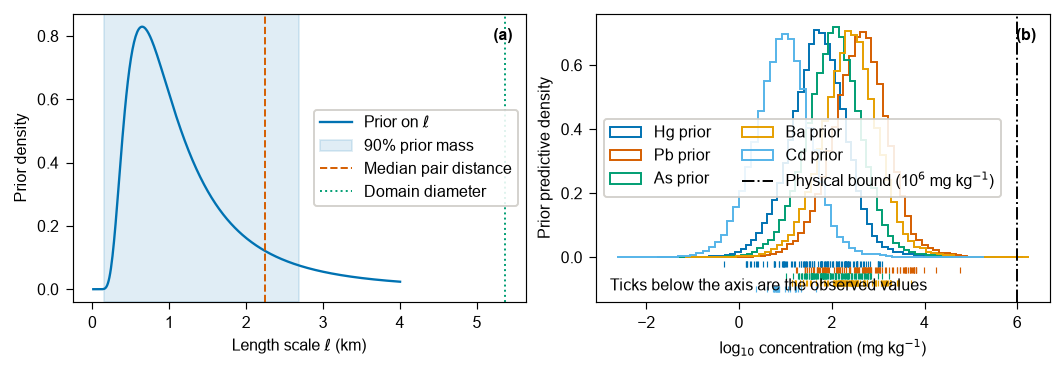

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(W2, W2 * 0.34), constrained_layout=True)

ax = axes[0]
xs = np.linspace(0.01, 4.0, 400)
ax.plot(xs, ig.pdf(xs), color=OI[0], lw=1.2, label="Prior on $\\ell$")
ax.axvspan(ELL_LO, ELL_HI, color=OI[0], alpha=0.12, label="90% prior mass")
ax.axvline(np.median(DIST[iu]), color=OI[1], ls="--", lw=1.0, label="Median pair distance")
ax.axvline(DIST[iu].max(), color=OI[2], ls=":", lw=1.0, label="Domain diameter")
ax.set_xlabel("Length scale $\\ell$ (km)")
ax.set_ylabel("Prior density")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7")
ax.text(0.97, 0.95, "(a)", transform=ax.transAxes, ha="right", va="top", fontweight="bold")

ax = axes[1]
for k, a in enumerate(MAIN_METALS):
    c = np.log10(pp_draws[a].ravel())
    ax.hist(c, bins=60, histtype="step", density=True, color=OI[k], lw=1.0, label=f"{a} prior")
ax.axvline(np.log10(PHYSICAL_MAX), color="k", lw=1.0, ls="-.",
           label="Physical bound (10$^6$ mg kg$^{-1}$)")
for k, a in enumerate(MAIN_METALS):
    o = np.log10(df[df.analyte == a]["value"].dropna())
    ax.plot(np.sort(o), np.full(len(o), -0.02 - 0.02 * k), "|", color=OI[k], ms=3, mew=0.6)
ax.set_xlabel(r"log$_{10}$ concentration (mg kg$^{-1}$)")
ax.set_ylabel("Prior predictive density")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", ncol=2, fontsize=8)
ax.text(0.97, 0.95, "(b)", transform=ax.transAxes, ha="right", va="top", fontweight="bold")
ax.text(0.03, 0.03, "Ticks below the axis are the observed values", transform=ax.transAxes,
        fontsize=8, va="bottom")

save_fig(fig, "FIG5_prior_predictive")
plt.show()

## 6. Parameter recovery on simulated fields (H4)

The cleanest evidence in the whole study, because here a truth exists. Fields are simulated with
**known** parameters over the 114 real locations, censored artificially, and both models are
fitted: the censored likelihood and the `L/2` substitution. A model that cannot recover known
parameters cannot be trusted on real data.

In [16]:
# The prior scales enter every subsequent model through sbmodel's module-level defaults, so the
# calibration above is not a decoration: it is the specification used from here on.
print(f"prior scales in force: beta {sb.SD_BETA}, sigma_tot {sb.SD_SIGMA}, beta0 {sb.SD_BETA0}")


def simulate_field(params, seed=SEED):
    """Simulate a log-concentration field over the real locations with known parameters."""
    r = np.random.default_rng(seed)
    a = XY / params["ell"]
    K = params["eta"] ** 2 * sb._matern52(((a[:, None] - a[None]) ** 2).sum(-1), params["ell"])
    K[np.diag_indices(len(XY))] += 1e-8
    f = np.linalg.cholesky(K) @ r.standard_normal(len(XY))
    mu = (params["beta0"] + COV @ params["beta"] + params["b_bg"] * IS_BACKGROUND + f)
    y = mu + r.standard_normal(len(XY)) * params["sigma_n"]
    return np.exp(y)


TRUE = {"beta0": 4.0, "beta": np.array([0.3, -0.2, -0.5, 0.1]), "b_bg": -0.9,
        "ell": np.array([0.65, 1.55]), "eta": 0.9, "sigma_n": 0.45}
TRUE["sigma_tot"] = float(np.hypot(TRUE["eta"], TRUE["sigma_n"]))
TRUE["rho"] = float(TRUE["eta"] ** 2 / TRUE["sigma_tot"] ** 2)

conc = simulate_field(TRUE)
CENS_RATE = 0.60
L_true = float(np.quantile(conc, CENS_RATE))
cens_sim = conc < L_true
RES_SIM = 0.01
print(f"simulated field: {len(conc)} locations, concentrations "
      f"{conc.min():.2f} to {conc.max():.1f} mg/kg")
print(f"censoring at the {CENS_RATE:.0%} quantile -> limit {L_true:.3f} mg/kg, "
      f"{cens_sim.sum()} censored values")
print(f"true parameters: ell {TRUE['ell']}, eta {TRUE['eta']}, sigma_n {TRUE['sigma_n']}, "
      f"rho {TRUE['rho']:.3f}, b_bg {TRUE['b_bg']}")

prior scales in force: beta 0.5, sigma_tot 0.7, beta0 0.7
simulated field: 114 locations, concentrations 9.43 to 1552.5 mg/kg
censoring at the 60% quantile -> limit 104.450 mg/kg, 68 censored values
true parameters: ell [0.65 1.55], eta 0.9, sigma_n 0.45, rho 0.800, b_bg -0.9


In [17]:
# Sampler budget, set from a measurement rather than a habit. A first fit at 2 500 warm-up and
# 2 000 draws gave R-hat 1.003, minimum ESS 1 546 and zero divergences: four times the ESS the
# acceptance criterion asks for, at thirty minutes per fit. Halving the draws keeps ESS near 800,
# comfortably above the 400 threshold, and makes a study with roughly fifty full fits feasible.
# `target_accept` stays at 0.99, which is what delivers the zero divergences.
KW_MAIN = dict(draws=1000, tune=1500, chains=4, target_accept=0.99)

idata_sim_cens = cache_idata("sim_censored", lambda: sb.fit_model(
    sb.build_censored_gp(XY, COV, np.where(cens_sim, np.nan, conc), cens_sim, RES_SIM, L_true,
                         ell_params=ELL_PARAMS, is_background=IS_BACKGROUND,
                         is_composite=IS_COMPOSITE, anisotropic=USE_ANISOTROPIC,
                         limit_as_parameter=False),
    seed=SEED, **KW_MAIN))

idata_sim_sub = cache_idata("sim_substitution", lambda: sb.fit_model(
    sb.build_censored_gp(XY, COV, np.where(cens_sim, np.nan, conc), cens_sim, RES_SIM, L_true,
                         ell_params=ELL_PARAMS, is_background=IS_BACKGROUND,
                         is_composite=IS_COMPOSITE, anisotropic=USE_ANISOTROPIC,
                         substitute_half_lod=True),
    seed=SEED, **KW_MAIN))

for nm, idt in [("censored likelihood", idata_sim_cens), ("L/2 substitution", idata_sim_sub)]:
    d = sb.diagnose(idt)
    print(f"{nm:22s} rhat {d['rhat_max']:.4f} | ESS {min(d['ess_bulk_min'], d['ess_tail_min']):.0f} "
          f"| divergences {d['divergences']} | BFMI {d.get('bfmi_min', float('nan')):.3f} "
          f"| passes {d['passes']}")

[cache] loaded sim_censored


[cache] loaded sim_substitution


censored likelihood    rhat 1.0039 | ESS 640 | divergences 0 | BFMI 0.824 | passes True


L/2 substitution       rhat 1.0113 | ESS 371 | divergences 0 | BFMI 0.742 | passes False


In [18]:
def recovery_row(idata, name, param, true_value, index=None):
    v = idata.posterior[param].values
    v = v.reshape(-1, *v.shape[2:])
    if index is not None:
        v = v[:, index]
    v = v.ravel()
    lo, hi = np.quantile(v, [0.025, 0.975])
    return {"model": name, "parameter": param + (f"[{index}]" if index is not None else ""),
            "true": true_value, "posterior_mean": v.mean(),
            "ci95_low": lo, "ci95_high": hi,
            "covers": bool(lo <= true_value <= hi),
            "rel_bias_pct": 100 * (v.mean() - true_value) / abs(true_value)}


targets = [("beta0", TRUE["beta0"], None), ("b_background", TRUE["b_bg"], None),
           ("ell", TRUE["ell"][0], 0), ("ell", TRUE["ell"][1], 1),
           ("eta", TRUE["eta"], None), ("sigma_n", TRUE["sigma_n"], None),
           ("sigma_tot", TRUE["sigma_tot"], None), ("rho", TRUE["rho"], None)]
targets += [("beta", TRUE["beta"][j], j) for j in range(COV.shape[1])]

rec = pd.DataFrame(
    [recovery_row(idata_sim_cens, "censored", p, t, i) for p, t, i in targets]
    + [recovery_row(idata_sim_sub, "L/2 substitution", p, t, i) for p, t, i in targets]).round(4)
print(rec.to_string(index=False))
save_table(rec, "TABLE9_parameter_recovery",
           caption="Parameter recovery on a simulated field with known parameters over the 114 real "
                   "locations, censored at 60\\%. The censored likelihood is compared with the "
                   "$L/2$ substitution.", label="tab:recovery")

cov_cens = rec[rec.model == "censored"]["covers"].mean()
cov_sub = rec[rec.model == "L/2 substitution"]["covers"].mean()
print(f"\n95% intervals covering the true value: censored {cov_cens:.0%}, "
      f"L/2 substitution {cov_sub:.0%}")
fails_sub = rec[(rec.model == "L/2 substitution") & (~rec.covers)]
if len(fails_sub):
    print("\nparameters the substitution fails to recover:")
    print(fails_sub[["parameter", "true", "posterior_mean", "ci95_low", "ci95_high",
                     "rel_bias_pct"]].to_string(index=False))
RECOVERY_PASSES = bool(cov_cens >= 0.9)
print(f"\nH4 verdict: the censored model {'recovers' if RECOVERY_PASSES else 'FAILS TO RECOVER'} "
      f"the known parameters.")

           model    parameter    true  posterior_mean  ci95_low  ci95_high  covers  rel_bias_pct
        censored        beta0  4.0000          4.8158    3.9691     5.7366    True       20.3953
        censored b_background -0.9000         -0.7624   -1.2924    -0.1613    True       15.2943
        censored       ell[0]  0.6500          0.9177    0.4071     1.9189    True       41.1796
        censored       ell[1]  1.5500          0.9294    0.4003     1.7444    True      -40.0361
        censored          eta  0.9000          1.0383    0.6650     1.5759    True       15.3630
        censored      sigma_n  0.4500          0.4041    0.3099     0.5318    True      -10.1948
        censored    sigma_tot  1.0062          1.1181    0.7696     1.6304    True       11.1202
        censored          rho  0.8000          0.8547    0.7083     0.9451    True        6.8368
        censored      beta[0]  0.3000          0.3167   -0.3604     0.9960    True        5.5734
        censored      beta[1] 

saved: FIG6_parameter_recovery | width 190 mm | 600 dpi


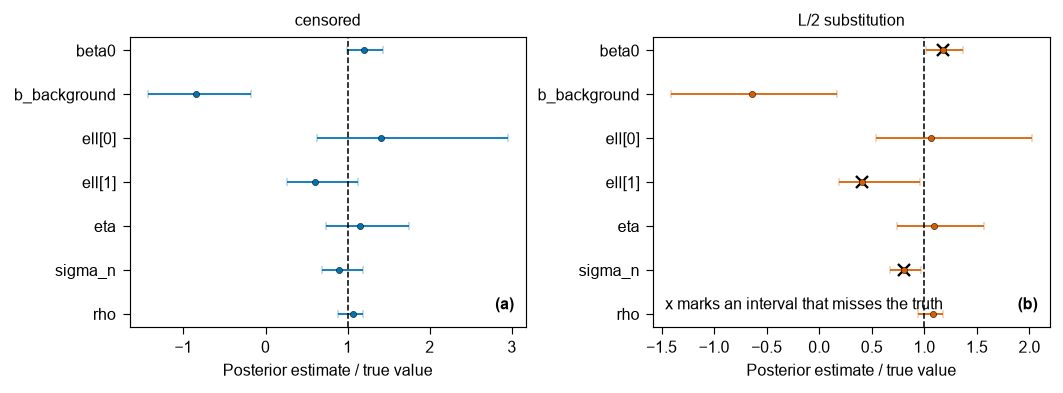

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(W2, W2 * 0.36), constrained_layout=True)
show = ["beta0", "b_background", "ell[0]", "ell[1]", "eta", "sigma_n", "rho"]
for ax, mdl in zip(axes, ["censored", "L/2 substitution"]):
    s = rec[(rec.model == mdl) & (rec.parameter.isin(show))].set_index("parameter").loc[show]
    ypos = np.arange(len(s))[::-1]
    # scale each parameter by its true value so they share one axis
    scale = s["true"].abs().values
    ax.errorbar(s["posterior_mean"] / scale, ypos,
                xerr=[(s["posterior_mean"] - s["ci95_low"]) / scale,
                      (s["ci95_high"] - s["posterior_mean"]) / scale],
                fmt="o", ms=3.2, lw=0.9, capsize=2,
                color=OI[0] if mdl == "censored" else OI[1], mec="k", mew=0.25)
    ax.axvline(1.0, color="k", lw=0.8, ls="--")
    for k, (_, r_) in enumerate(s.iterrows()):
        if not r_["covers"]:
            ax.plot(r_["posterior_mean"] / scale[k], ypos[k], "x", color="k", ms=6, mew=1.2)
    ax.set_yticks(ypos)
    ax.set_yticklabels(show)
    ax.set_xlabel("Posterior estimate / true value")
    ax.set_title(mdl, fontsize=8)
    ax.text(0.97, 0.05, "(a)" if mdl == "censored" else "(b)", transform=ax.transAxes,
            ha="right", va="bottom", fontweight="bold")
axes[1].text(0.03, 0.05, "x marks an interval that misses the truth", transform=axes[1].transAxes,
             fontsize=8, va="bottom")
save_fig(fig, "FIG6_parameter_recovery")
plt.show()

## 7. Main hierarchical censored GP models (H5)

One model per analyte for **Hg, Pb, As, Ba and Cd**, with:

* the **stratum in the mean**, which is what separates geochemical background from mining input;
* an **ARD Matérn 5/2** kernel, following the anisotropy found in section 4;
* **interval censoring** on the detections at the laboratory reporting resolution, and the
  cumulative mass below the limit for the non-detects;
* the **limit as a parameter** for the censored analyte;
* a **composite-support variance factor**, fitted jointly with the stratum effect so that their
  posterior correlation can be inspected before anything is claimed about either.

NUTS through nutpie, 4 chains, 2 500 warm-up and 2 000 sampling draws, `target_accept = 0.99`.

In [20]:
def fit_main(analyte, force=False):
    m = metal_arrays(analyte)
    min_det = np.nanmin(m["value"]) if np.isfinite(m["value"]).any() else None
    return cache_idata(
        f"main_{analyte}",
        lambda: sb.fit_model(
            sb.build_censored_gp(
                XY, COV, m["value"], m["censored"], m["resolution"], m["lod"],
                ell_params=ELL_PARAMS, is_background=IS_BACKGROUND, is_composite=IS_COMPOSITE,
                anisotropic=USE_ANISOTROPIC, limit_as_parameter=True, min_detected=min_det),
            seed=SEED, **KW_MAIN),
        force=force)


idata_main = {a: fit_main(a) for a in MAIN_METALS}

[cache] loaded main_Hg


[cache] loaded main_Pb


[cache] loaded main_As


[cache] loaded main_Ba


[cache] loaded main_Cd


### 7.1 Convergence diagnostics

R-hat and ESS are computed with `az.rhat` and `az.ess` directly. `az.summary` rounds to two
decimals, which hides an R-hat of 1.014 as "1.01" and would let a failure through.

In [21]:
diag_rows = []
for a in MAIN_METALS:
    d = sb.diagnose(idata_main[a])
    d["model"] = f"main {a}"
    diag_rows.append(d)
for nm, idt in [("simulation, censored", idata_sim_cens),
                ("simulation, L/2", idata_sim_sub)]:
    d = sb.diagnose(idt)
    d["model"] = nm
    diag_rows.append(d)
diag = pd.DataFrame(diag_rows)[["model", "rhat_max", "ess_bulk_min", "ess_tail_min",
                                "divergences", "bfmi_min", "n_draws", "passes"]].round(4)
print(diag.to_string(index=False))
save_table(diag, "TABLE10_convergence",
           caption="Convergence diagnostics of the main models, computed without the two-decimal "
                   "rounding of \\texttt{az.summary}. BFMI is the Bayesian fraction of missing "
                   "information from the energy transitions.", label="tab:conv")
print(f"\nall main models pass: {bool(diag['passes'].all())}")

               model  rhat_max  ess_bulk_min  ess_tail_min  divergences  bfmi_min  n_draws  passes
             main Hg    1.0104      330.7926      460.3230            0    0.9039     4000   False
             main Pb    1.0068      751.5722     1272.3414            0    0.8428     4000    True
             main As    1.0064      913.1985     1204.5772            0    0.8747     4000    True
             main Ba    1.0035     1025.7674     1322.7309            0    0.8636     4000    True
             main Cd    1.0020      841.7323     1382.8957            0    0.8989     4000    True
simulation, censored    1.0039      640.3965     1059.6232            0    0.8237     4000    True
     simulation, L/2    1.0113      370.8766      527.5681            0    0.7419     4000   False
table: TABLE10_convergence.csv + .tex

all main models pass: False


### 7.2 Posterior parameters

In [22]:
par_rows = []
for a in MAIN_METALS:
    p = idata_main[a].posterior
    row = {"analyte": a}
    for nm in ["ell", "eta", "sigma_n", "sigma_tot", "rho", "beta0", "b_background",
               "log_tau", "limit_ratio"]:
        if nm not in p:
            continue
        v = p[nm].values.reshape(-1, *p[nm].shape[2:])
        if v.ndim == 2 and v.shape[1] == 2:
            for j, ax_ in enumerate(["E", "N"]):
                row[f"{nm}_{ax_}"] = v[:, j].mean()
        else:
            row[nm] = v.ravel().mean()
    for j, cname in enumerate(COVARS):
        b = p["beta"].values.reshape(-1, COV.shape[1])[:, j]
        lo, hi = np.quantile(b, [0.025, 0.975])
        row[f"beta_{cname}"] = b.mean()
        row[f"beta_{cname}_sig"] = bool(lo > 0 or hi < 0)
    par_rows.append(row)
params = pd.DataFrame(par_rows).round(4)
print(params.to_string(index=False))
save_table(params, "TABLE11_posterior_parameters",
           caption="Posterior means of the main model parameters. Length scales in km, variances "
                   "in log mg kg$^{-1}$. $\\rho$ is the spatially structured proportion of the "
                   "total variance.", label="tab:params")

print("\nanisotropy recovered by the model (northing / easting length scale):")
for a in MAIN_METALS:
    e = idata_main[a].posterior["ell"].values.reshape(-1, 2)
    print(f"  {a}: {e[:, 1].mean()/e[:, 0].mean():.2f}x  "
          f"(E {e[:, 0].mean():.2f} km, N {e[:, 1].mean():.2f} km)")

analyte  ell_E  ell_N    eta  sigma_n  sigma_tot    rho  beta0  b_background  log_tau  beta_elev_oefa  beta_elev_oefa_sig  beta_slope_deg  beta_slope_deg_sig  beta_log_dist_dump  beta_log_dist_dump_sig  beta_log_dist_city  beta_log_dist_city_sig  limit_ratio
     Hg 0.5322 1.7405 1.0461   1.0245     1.4748 0.4995 4.0786       -0.4265   0.0935         -0.1529               False          0.1173               False              0.4541                    True             -0.3254                   False          NaN
     Pb 0.3824 1.0540 1.3573   0.8271     1.5953 0.7181 6.1268       -0.3050  -0.5681          0.0621               False         -0.0983               False             -0.0651                   False             -0.0290                   False          NaN
     As 0.5720 0.7161 1.1194   0.6573     1.3046 0.7280 4.7307       -0.3573  -0.3234         -0.1193               False         -0.0132               False             -0.0307                   False             -0.0697  

### 7.3 The identifiability check the design forces: stratum against support

The 30 background points are exactly the 30 composite samples. The two effects are therefore
almost perfectly aliased. They are not fully aliased — the stratum shifts the **mean** and the
support scales the **variance**, which leave different fingerprints — but identification is weak.
The procedure fixed in advance: fit both, inspect the posterior correlation, and if it exceeds
0.9 in absolute value declare that they cannot be separated, keep only the mean effect and report
support as a limitation.

In [23]:
alias_rows = []
for a in MAIN_METALS:
    p = idata_main[a].posterior
    if "log_tau" not in p or "b_background" not in p:
        continue
    b = p["b_background"].values.ravel()
    t = p["log_tau"].values.ravel()
    r_ = float(np.corrcoef(b, t)[0, 1])
    lo_b, hi_b = np.quantile(b, [0.025, 0.975])
    lo_t, hi_t = np.quantile(t, [0.025, 0.975])
    alias_rows.append({"analyte": a, "b_background": b.mean(), "b_ci95_low": lo_b,
                       "b_ci95_high": hi_b, "log_tau": t.mean(), "tau_ci95_low": lo_t,
                       "tau_ci95_high": hi_t, "posterior_corr": r_,
                       "separable": bool(abs(r_) < 0.9)})
alias = pd.DataFrame(alias_rows).round(4)
print(alias.to_string(index=False))
save_table(alias, "TABLE12_stratum_support_aliasing",
           caption="Posterior correlation between the stratum mean effect and the composite-support "
                   "variance factor. A correlation above 0.9 in absolute value would mean the two "
                   "cannot be separated by these data.", label="tab:alias")

SEPARABLE = bool(alias["separable"].all())
print(f"\nmaximum absolute posterior correlation: {alias['posterior_corr'].abs().max():.3f}")
if SEPARABLE:
    print("Below the 0.9 threshold for every analyte, so both effects are reported as estimated.\n"
          "The stratum effect is nonetheless partly confounded with location (section 3.2) and that\n"
          "remains a limitation.")
else:
    print("At or above the threshold: the two effects cannot be separated by these data. The\n"
          "support factor is dropped and reported as a limitation, keeping only the stratum mean.")

analyte  b_background  b_ci95_low  b_ci95_high  log_tau  tau_ci95_low  tau_ci95_high  posterior_corr  separable
     Hg       -0.4265     -1.1403       0.3032   0.0935       -0.2193         0.4136          0.0782       True
     Pb       -0.3050     -0.9941       0.3640  -0.5681       -0.9077        -0.2118         -0.1610       True
     As       -0.3573     -0.9739       0.2477  -0.3234       -0.6413         0.0294         -0.0789       True
     Ba       -0.5197     -1.0853       0.0785  -0.1656       -0.4741         0.1628          0.0553       True
     Cd       -0.3699     -1.2475       0.4994  -0.4784       -1.3187         0.3104         -0.1960       True
table: TABLE12_stratum_support_aliasing.csv + .tex

maximum absolute posterior correlation: 0.196
Below the 0.9 threshold for every analyte, so both effects are reported as estimated.
The stratum effect is nonetheless partly confounded with location (section 3.2) and that
remains a limitation.


saved: FIG7_stratum_support | width 190 mm | 600 dpi


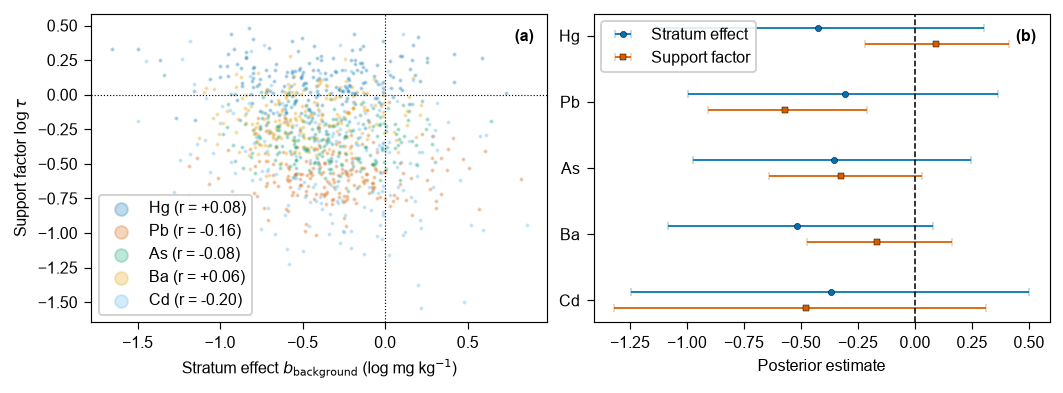

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(W2, W2 * 0.36), constrained_layout=True)
ax = axes[0]
for k, a in enumerate(MAIN_METALS):
    p = idata_main[a].posterior
    ax.scatter(p["b_background"].values.ravel()[::20], p["log_tau"].values.ravel()[::20],
               s=1.2, alpha=0.25, color=OI[k], label=f"{a} (r = {alias.set_index('analyte').loc[a,'posterior_corr']:+.2f})")
ax.axhline(0, color="k", lw=0.6, ls=":")
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("Stratum effect $b_{\\mathrm{background}}$ (log mg kg$^{-1}$)")
ax.set_ylabel("Support factor $\\log\\tau$")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", markerscale=6, fontsize=8)
ax.text(0.97, 0.95, "(a)", transform=ax.transAxes, ha="right", va="top", fontweight="bold")

ax = axes[1]
ypos = np.arange(len(MAIN_METALS))[::-1]
s = alias.set_index("analyte").loc[MAIN_METALS]
ax.errorbar(s["b_background"], ypos + 0.12,
            xerr=[s["b_background"] - s["b_ci95_low"], s["b_ci95_high"] - s["b_background"]],
            fmt="o", ms=3.2, lw=0.9, capsize=2, color=OI[0], mec="k", mew=0.25,
            label="Stratum effect")
ax.errorbar(s["log_tau"], ypos - 0.12,
            xerr=[s["log_tau"] - s["tau_ci95_low"], s["tau_ci95_high"] - s["log_tau"]],
            fmt="s", ms=3.0, lw=0.9, capsize=2, color=OI[1], mec="k", mew=0.25,
            label="Support factor")
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_yticks(ypos)
ax.set_yticklabels(MAIN_METALS)
ax.set_xlabel("Posterior estimate")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7")
ax.text(0.97, 0.95, "(b)", transform=ax.transAxes, ha="right", va="top", fontweight="bold")
save_fig(fig, "FIG7_stratum_support")
plt.show()

### 7.4 Prior against posterior

The only honest way to show what the data identified and what they did not. In the previous phase
of this project this figure revealed that $\rho$ had a posterior 91 % as wide as its prior, i.e.
it was not identified at all, and a claim resting on it had to be withdrawn.

In [25]:
def prior_draws(name, n=20000, seed=SEED):
    r = np.random.default_rng(seed)
    if name == "ell":
        return ig.rvs(n, random_state=int(seed))
    if name == "sigma_tot":
        return np.abs(r.normal(0, 1, n))
    if name == "rho":
        return r.beta(2, 2, n)
    if name == "b_background":
        return r.normal(0, 1, n)
    if name == "log_tau":
        return r.normal(0, 0.5, n)
    raise KeyError(name)


PP_PARAMS = ["ell", "sigma_tot", "rho", "b_background", "log_tau"]
pp_rows = []
for a in MAIN_METALS:
    p = idata_main[a].posterior
    for nm in PP_PARAMS:
        if nm not in p:
            continue
        v = p[nm].values
        v = v.reshape(-1, *v.shape[2:])
        v = v[:, 0] if v.ndim == 2 else v.ravel()
        pri = prior_draws(nm)
        w_post = float(np.diff(np.quantile(v, [0.025, 0.975]))[0])
        w_pri = float(np.diff(np.quantile(pri, [0.025, 0.975]))[0])
        pp_rows.append({"analyte": a, "parameter": nm, "prior_width95": w_pri,
                        "posterior_width95": w_post, "width_ratio": w_post / w_pri,
                        "identified": bool(w_post / w_pri < 0.6)})
prpo = pd.DataFrame(pp_rows).round(4)
print(prpo.pivot(index="parameter", columns="analyte", values="width_ratio").round(3).to_string())
save_table(prpo, "TABLE13_prior_posterior",
           caption="Ratio between the width of the 95\\% posterior interval and that of the prior. "
                   "A ratio near one means the data were uninformative about that parameter.",
           label="tab:priorpost")
print("\nA ratio near 1 means the posterior is the prior: the data said nothing about that\n"
      "parameter. The threshold of 0.6 is a convention declared here, not a test.")

analyte          As     Ba     Cd     Hg     Pb
parameter                                      
b_background  0.313  0.298  0.448  0.370  0.348
ell           0.162  0.110  0.203  0.175  0.093
log_tau       0.344  0.326  0.835  0.324  0.356
rho           0.413  0.331  0.581  0.552  0.368
sigma_tot     0.357  0.344  0.559  0.318  0.370
table: TABLE13_prior_posterior.csv + .tex

A ratio near 1 means the posterior is the prior: the data said nothing about that
parameter. The threshold of 0.6 is a convention declared here, not a test.


saved: FIG8_prior_posterior | width 190 mm | 600 dpi


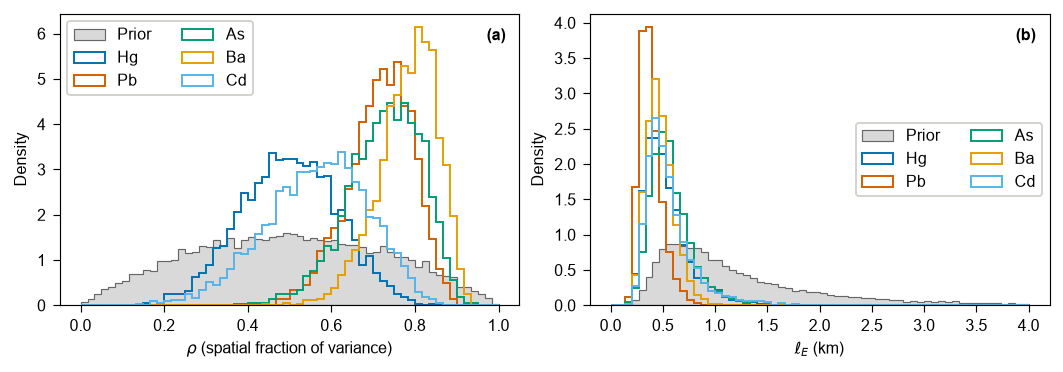

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(W2, W2 * 0.34), constrained_layout=True)
for ax, nm, lab in zip(axes, ["rho", "ell"],
                       ["$\\rho$ (spatial fraction of variance)", "$\\ell_E$ (km)"]):
    pri = prior_draws(nm)
    ax.hist(pri, bins=60, density=True, histtype="stepfilled", color="0.85", edgecolor="0.4",
            lw=0.6, label="Prior", range=(0, 1) if nm == "rho" else (0, 4))
    for k, a in enumerate(MAIN_METALS):
        v = idata_main[a].posterior[nm].values
        v = v.reshape(-1, *v.shape[2:])
        v = v[:, 0] if v.ndim == 2 else v.ravel()
        ax.hist(v, bins=60, density=True, histtype="step", color=OI[k], lw=1.0, label=a,
                range=(0, 1) if nm == "rho" else (0, 4))
    ax.set_xlabel(lab)
    ax.set_ylabel("Density")
    ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", ncol=2, fontsize=8)
axes[0].text(0.97, 0.95, "(a)", transform=axes[0].transAxes, ha="right", va="top", fontweight="bold")
axes[1].text(0.97, 0.95, "(b)", transform=axes[1].transAxes, ha="right", va="top", fontweight="bold")
save_fig(fig, "FIG8_prior_posterior")
plt.show()

### 7.5 Posterior predictive checks

In [27]:
def posterior_predictive_stats(analyte, idata, n_rep=600, seed=SEED):
    """Replicate the observation process, censoring included, and compare summary statistics."""
    m = metal_arrays(analyte)
    r = np.random.default_rng(seed)
    p = idata.posterior
    flat = p.sizes["chain"] * p.sizes["draw"]
    idx = r.choice(flat, n_rep, replace=n_rep > flat)
    mu = p["mu"].values.reshape(flat, -1)[idx]
    sn = p["sigma_n"].values.reshape(flat)[idx]
    tau = np.exp(p["log_tau"].values.reshape(flat)[idx]) if "log_tau" in p else np.ones(n_rep)
    sd = sn[:, None] * np.where(IS_COMPOSITE[None, :], tau[:, None], 1.0)
    yrep = mu + r.standard_normal(mu.shape) * sd

    if "log_limit" in p:
        loglim = p["log_limit"].values.reshape(flat)[idx]
    elif np.isfinite(m["lod"]):
        loglim = np.full(n_rep, np.log(m["lod"]))
    else:
        loglim = np.full(n_rep, -np.inf)
    cens_rep = yrep < loglim[:, None]

    obs_det = np.log(m["value"][~m["censored"]])
    stats_obs = {"median_log": np.median(obs_det), "sd_log": np.std(obs_det),
                 "max_log": obs_det.max(), "pct_censored": 100 * m["censored"].mean(),
                 "pct_above_eca": 100 * np.mean(m["value"][~m["censored"]] > m["eca"][0])}
    out = []
    for k, fn in [("median_log", np.median), ("sd_log", np.std), ("max_log", np.max)]:
        rep = np.array([fn(yrep[s][~cens_rep[s]]) if (~cens_rep[s]).any() else np.nan
                        for s in range(n_rep)])
        p_bayes = float(np.nanmean(rep >= stats_obs[k]))
        out.append({"analyte": analyte, "statistic": k, "observed": stats_obs[k],
                    "replicated_mean": np.nanmean(rep),
                    "rep_ci95_low": np.nanquantile(rep, 0.025),
                    "rep_ci95_high": np.nanquantile(rep, 0.975),
                    "p_bayes": p_bayes, "compatible": bool(0.025 < p_bayes < 0.975)})
    rep_c = 100 * cens_rep.mean(1)
    p_b = float(np.mean(rep_c >= stats_obs["pct_censored"]))
    out.append({"analyte": analyte, "statistic": "pct_censored",
                "observed": stats_obs["pct_censored"], "replicated_mean": rep_c.mean(),
                "rep_ci95_low": np.quantile(rep_c, 0.025), "rep_ci95_high": np.quantile(rep_c, 0.975),
                "p_bayes": p_b, "compatible": bool(0.025 < p_b < 0.975)})
    return out


ppc = pd.DataFrame([r_ for a in MAIN_METALS
                    for r_ in posterior_predictive_stats(a, idata_main[a])]).round(4)
print(ppc.to_string(index=False))
save_table(ppc, "TABLE14_posterior_predictive",
           caption="Posterior predictive checks. Each statistic is recomputed on replicated "
                   "datasets that reproduce the censoring mechanism, and compared with the observed "
                   "value.", label="tab:ppc")
bad = ppc[~ppc.compatible]
print(f"\nincompatible statistics: {len(bad)} of {len(ppc)}")
if len(bad):
    print(bad[["analyte", "statistic", "observed", "replicated_mean", "p_bayes"]].to_string(index=False))
    print("\nThese are reported rather than explained away; the discussion returns to them.")

analyte    statistic  observed  replicated_mean  rep_ci95_low  rep_ci95_high  p_bayes  compatible
     Hg   median_log    4.1047           4.0336        3.6528         4.4235   0.3567        True
     Hg       sd_log    1.7998           1.7897        1.5645         2.0534   0.4767        True
     Hg      max_log    7.0716           7.9901        6.9563         9.2328   0.9533        True
     Hg pct_censored    0.0000           0.0000        0.0000         0.0000   1.0000       False
     Pb   median_log    5.9558           5.8709        5.5146         6.2158   0.3317        True
     Pb       sd_log    1.7928           1.7936        1.6186         1.9885   0.4933        True
     Pb      max_log   10.9682          10.2172        9.3049        11.3958   0.0767        True
     Pb pct_censored    0.0000           0.0000        0.0000         0.0000   1.0000       False
     As   median_log    4.5109           4.5691        4.3329         4.8138   0.6717        True
     As       sd_log

## 8. The masking experiment (H6)

This is the experiment the paper rests on.

**The problem it solves.** On real censored data there is no truth to compare against at the
censored locations, so any comparison of methods has to be made on the detections alone — and
that subset is the upper truncated tail, where whichever model predicts higher wins
automatically. The audit of the previous phase showed exactly this: five models were all about
three times worse than a plain intercept on the set where they were being scored.

**The design.** Three analytes measured here with **zero censoring** are used as complete truth
fields. Real values are *hidden*, not simulated:

1. take the real measurements at the 114 locations;
2. left-censor at level `c` by putting the limit at the `c` quantile of those real values;
3. hold out one whole spatial block and fit on the rest;
4. score against the true values at **every** held-out location, censored ones included.

Censoring at a quantile is the correct analogue of the real mechanism: the quantile *is* a fixed
number, and a fixed laboratory limit producing `c` per cent non-detects is precisely what it
represents. This is masking, not fabrication — the same logic as cross-validation, which also
hides real observations to see whether a model recovers them.

**Why three analytes and not two or four.** The analytes are not replicates: each is a field with
its own spatial structure, and that is exactly the axis that has to vary to know whether a
conclusion is general or an artefact of one field. With two, a pattern cannot be told from a
coincidence; the third turns a pair into a trend. A fourth (Ba) would have cost about a quarter of
the compute while adding little: its log standard deviation falls between the others, its
exceedance is low and its threshold of 750 mg kg⁻¹ sits so far from any detection limit that it
says nothing about the claim. Ba stays in the main models and in the maps.

The three chosen span the space of structures: **Hg** (sd log 1.81, the mine's defining metal),
**Pb** (sd log 1.80 but far heavier tails — maximum 58 000 against a median of 383, a factor of
150, which stresses robustness to extremes) and **As** (sd log 1.11, the weakest signal).

In [28]:
import masking_worker as mw

LEVELS = [0.20, 0.40, 0.60, 0.80]
N_REPLICATES = 10          # reduced from 20 after timing the machine; see the note below
N_BLOCKS = 5

design = mw.make_design(TRUTH_FIELDS, LEVELS, N_REPLICATES, n_blocks=N_BLOCKS)
print(f"design: {len(TRUTH_FIELDS)} analytes x {len(LEVELS)} levels x {N_REPLICATES} replicates "
      f"= {len(design)} cells")
print(f"each cell fits 3 models (ordinary kriging, censored GP, GP with L/2) "
      f"-> {len(design)*3} model fits")
print("\nReplicates were cut from 20 to 10 after measuring this machine: a single censored "
      "GP fit over ~90 training points takes about 27 s with two chains, and the full "
      "design at 20 replicates would not finish in a working session. The study plan fixed "
      "replicates as the first thing to cut for exactly this reason, ahead of touching the "
      "analytes, the levels or the validation of the cheap inference.")

design: 3 analytes x 4 levels x 10 replicates = 120 cells
each cell fits 3 models (ordinary kriging, censored GP, GP with L/2) -> 360 model fits

Replicates were cut from 20 to 10 after measuring this machine: a single censored GP fit over ~90 training points takes about 27 s with two chains, and the full design at 20 replicates would not finish in a working session. The study plan fixed replicates as the first thing to cut for exactly this reason, ahead of touching the analytes, the levels or the validation of the cheap inference.


### 8.1 Parallelism

The loop is embarrassingly parallel: every (analyte, level, replicate) cell is independent. Three
constraints shape how it is run.

1. **`asyncio` is the wrong tool.** This is CPU-bound work, not I/O-bound, and the GIL blocks it.
   It has to be processes, not coroutines or threads.
2. **Windows uses *spawn*.** Every worker re-imports the module holding the work function, so that
   function lives in `masking_worker.py` and not in a notebook cell, and the launch is guarded.
   The previous phase of this project hit this exact failure with `RandomForest(n_jobs=-1)`.
3. **Cores against chains.** NUTS already parallelises *within* a fit, one chain per process.
   Launching `n` fits in parallel with 4 chains each asks for `4n` processes and the machine
   thrashes. The configuration used is **2 chains per fit**, `cores=1` inside the fit, and
   `n_jobs = cpu_count // 2` fits in parallel. Each worker also sets the BLAS thread count to 1,
   without which every process spawns its own thread pool.

In [29]:
N_JOBS = max(1, N_CPU // 2)
print(f"detected cores: {N_CPU} -> {N_JOBS} cells in parallel, 2 chains each, "
      f"so {N_JOBS*2} processes on {N_CPU} cores")
print("Measured on this machine: one fit takes 52 s with sequential chains and 27 s with "
      "two, so the two-chain configuration is what makes the experiment affordable.")

MASK_KW = dict(draws=500, tune=500, chains=2, cores=2, target_accept=0.95,
               n_pred=800, n_blocks=N_BLOCKS)
print("inference inside the experiment:", MASK_KW)
print("\nThe experiment compares *methods against each other* under an identical budget, so a\n"
      "consistent cheaper approximation is legitimate. Section 8.3 validates that shortcut against\n"
      "the full sampler on a subset of cells; without that validation the shortcut would not be\n"
      "defensible.")

detected cores: 20 -> 10 cells in parallel, 2 chains each, so 20 processes on 20 cores
Measured on this machine: one fit takes 52 s with sequential chains and 27 s with two, so the two-chain configuration is what makes the experiment affordable.
inference inside the experiment: {'draws': 500, 'tune': 500, 'chains': 2, 'cores': 2, 'target_accept': 0.95, 'n_pred': 800, 'n_blocks': 5}

The experiment compares *methods against each other* under an identical budget, so a
consistent cheaper approximation is legitimate. Section 8.3 validates that shortcut against
the full sampler on a subset of cells; without that validation the shortcut would not be
defensible.


In [30]:
H6_PATH = DIR_OUT / "H6_masking_experiment.csv"

if H6_PATH.exists():
    h6 = pd.read_csv(H6_PATH)
    print(f"[cache] loaded {len(h6)} rows from {H6_PATH.name}")
else:
    from joblib import Parallel, delayed
    # Each worker writes its cell to outputs/h6_cells/ as soon as it finishes, so an interrupted
    # run resumes rather than repeating the experiment. Count what is already there before starting.
    done_before = len(list((DIR_OUT / "h6_cells").glob("*.json"))) if (DIR_OUT / "h6_cells").exists() else 0
    if done_before:
        print(f"[resume] {done_before} of {len(design)} cells already checkpointed")
    t0 = time.time()
    chunks = Parallel(n_jobs=N_JOBS, backend="loky", verbose=5)(
        delayed(mw.run_cell)(c, **MASK_KW) for c in design)
    h6 = pd.DataFrame([r for ch in chunks for r in ch])
    h6.to_csv(H6_PATH, index=False, encoding="utf-8")
    print(f"[run] {len(design)} cells ({len(design)-done_before} newly fitted) in "
          f"{(time.time()-t0)/60:.1f} min -> {len(h6)} rows")

n_err = int(h6["error"].notna().sum()) if "error" in h6.columns else 0
print(f"rows: {len(h6)} | failed fits: {n_err}")
if n_err:
    print(h6[h6["error"].notna()][["metal", "level", "replicate", "model", "error"]].head().to_string(index=False))
    h6 = h6[h6["error"].isna()].copy()

print("\nconvergence inside the experiment (Bayesian models only):")
gp = h6[h6.model.str.contains("GP")]
print(f"  R-hat max {gp['rhat_max'].max():.4f} | ESS min {gp['ess_min'].min():.0f} "
      f"| total divergences {int(gp['divergences'].sum())} | "
      f"cells with divergences {int((gp['divergences'] > 0).sum())} of {len(gp)}")

[cache] loaded 360 rows from H6_masking_experiment.csv
rows: 360 | failed fits: 0

convergence inside the experiment (Bayesian models only):
  R-hat max 1.4904 | ESS min 4 | total divergences 489 | cells with divergences 53 of 240


### 8.2 Results

In [31]:
MODELS = ["ordinary kriging L/2", "GP with L/2", "censored GP"]
agg = (h6.groupby(["metal", "level", "model"])
       .agg(rmse=("rmse", "mean"), rmse_sd=("rmse", "std"),
            mae=("mae", "mean"), crps=("crps", "mean"), crps_sd=("crps", "std"),
            picp95=("picp95", "mean"), width95=("width95", "mean"),
            joint=("joint_log_score", "mean"), n=("rmse", "size"))
       .reset_index())
piv = agg.pivot_table(index=["metal", "level"], columns="model", values=["rmse", "crps"])
print(piv.round(4).to_string())
save_table(agg.round(5), "TABLE15_masking_experiment",
           caption="Masking experiment. Predictive scores against the true values at every held-out "
                   "location, censored ones included, averaged over the replicates. Log scale.",
           label="tab:masking")

                   crps                                         rmse                                 
model       GP with L/2 censored GP ordinary kriging L/2 GP with L/2 censored GP ordinary kriging L/2
metal level                                                                                          
As    0.2        0.6545      0.6715               0.6830      1.1083      1.1372               1.1304
      0.4        0.6717      0.6797               0.7019      1.1467      1.1519               1.1591
      0.6        0.6462      0.6740               0.7138      1.1023      1.1397               1.1637
      0.8        0.7645      0.7062               0.8210      1.2171      1.2134               1.2456
Hg    0.2        0.9450      0.9237               1.0153      1.5528      1.5090               1.6136
      0.4        0.9216      0.9545               1.0187      1.5063      1.5778               1.6223
      0.6        0.9545      0.9680               1.0976      1.5100      1.5763  

### The key quantity: does the gap widen with censoring?

The hypothesis is not "the censored model is better"; it is that **the advantage grows with the
censoring rate**. That is a statement about a slope, so a slope is what gets fitted, with its
interval, for each analyte and each competing model.

In [32]:
from scipy import stats as sps

slope_rows = []
for metal in TRUTH_FIELDS:
    base = h6[(h6.metal == metal) & (h6.model == "censored GP")].set_index(["level", "replicate"])
    for other in ["ordinary kriging L/2", "GP with L/2"]:
        comp = h6[(h6.metal == metal) & (h6.model == other)].set_index(["level", "replicate"])
        common = base.index.intersection(comp.index)
        for metric in ["rmse", "crps"]:
            diff = (comp.loc[common, metric] - base.loc[common, metric]).to_numpy(float)
            lev = np.array([i[0] for i in common], float)
            lr = sps.linregress(lev, diff)
            slope_rows.append({
                "metal": metal, "baseline": other, "metric": metric,
                "slope": lr.slope, "slope_se": lr.stderr,
                "ci95_low": lr.slope - 1.96 * lr.stderr, "ci95_high": lr.slope + 1.96 * lr.stderr,
                "p_value": lr.pvalue,
                "mean_diff_at_20": float(diff[lev == 0.20].mean()),
                "mean_diff_at_80": float(diff[lev == 0.80].mean()),
                "diverges": bool(lr.slope > 0 and lr.slope - 1.96 * lr.stderr > 0)})
slopes = pd.DataFrame(slope_rows).round(5)
print(slopes.to_string(index=False))
save_table(slopes, "TABLE16_divergence_slopes",
           caption="Slope of the score difference (baseline minus censored GP) against the "
                   "censoring level. A positive slope whose interval excludes zero means the "
                   "advantage of the censored model grows with censoring.",
           label="tab:slopes")

n_div = int(slopes["diverges"].sum())
print(f"\ncells where the advantage grows significantly with censoring: {n_div} of {len(slopes)}")
if n_div == 0:
    print("\nThe divergence predicted by the hypothesis DOES NOT APPEAR. This is stated plainly and\n"
          "the conclusion is rewritten accordingly: an honest negative result is worth more than a\n"
          "false claim.")
else:
    print(f"\nThe advantage of the censored model grows with the censoring rate in {n_div} of the\n"
          f"{len(slopes)} analyte-baseline-metric combinations tested.")

metal             baseline metric   slope  slope_se  ci95_low  ci95_high  p_value  mean_diff_at_20  mean_diff_at_80  diverges
   Hg ordinary kriging L/2   rmse 0.24128   0.20194  -0.15451    0.63708  0.23955          0.10459          0.24160     False
   Hg ordinary kriging L/2   crps 0.30696   0.18100  -0.04780    0.66173  0.09808          0.09158          0.27442     False
   Hg          GP with L/2   rmse 0.18443   0.10488  -0.02114    0.39000  0.08673          0.04378          0.16498     False
   Hg          GP with L/2   crps 0.30999   0.08617   0.14110    0.47887  0.00091          0.02137          0.22155      True
   Pb ordinary kriging L/2   rmse 0.13725   0.26435  -0.38087    0.65537  0.60663          0.21676          0.34396     False
   Pb ordinary kriging L/2   crps 0.49573   0.25076   0.00424    0.98721  0.05534          0.14798          0.48679      True
   Pb          GP with L/2   rmse 0.08590   0.21076  -0.32719    0.49900  0.68587          0.02510          0.10863   

saved: FIG9_Hg_crps | width 90 mm | 600 dpi


saved: FIG9_Pb_crps | width 90 mm | 600 dpi


saved: FIG9_As_crps | width 90 mm | 600 dpi


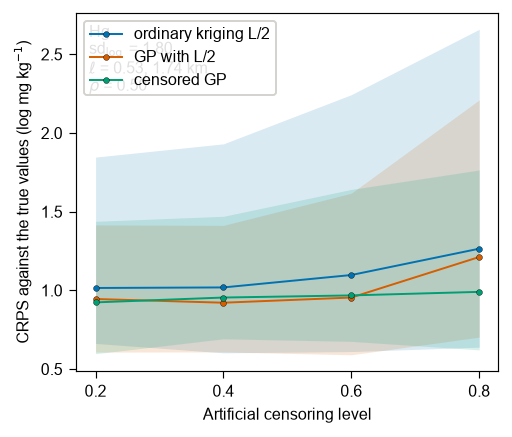

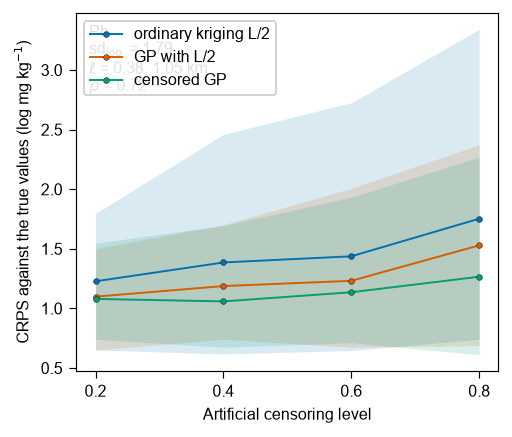

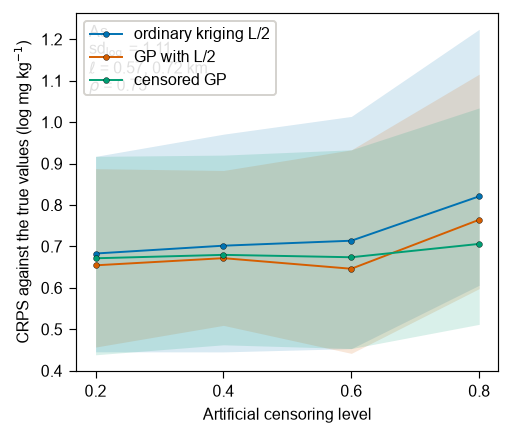

In [33]:
# One analyte per file: at most two panels per figure, so each field gets its own.
for metal in TRUTH_FIELDS:
    fig, ax = plt.subplots(figsize=(W1, W1 * 0.85), constrained_layout=True)
    for k, mdl in enumerate(MODELS):
        s = h6[(h6.metal == metal) & (h6.model == mdl)]
        g = s.groupby("level")["crps"]
        m, lo, hi = g.mean(), g.quantile(0.1), g.quantile(0.9)
        ax.plot(m.index, m.values, "-o", ms=3, lw=1.0, color=OI[k], mec="k", mew=0.2, label=mdl)
        ax.fill_between(m.index, lo.values, hi.values, color=OI[k], alpha=0.15, lw=0)
    ax.set_xlabel("Artificial censoring level")
    ax.set_xticks(LEVELS)
    ax.set_ylabel("CRPS against the true values (log mg kg$^{-1}$)")
    sd_log = float(np.std(np.log(df[df.analyte == metal]["value"].dropna())))
    p = idata_main[metal].posterior
    ell_m = p["ell"].values.reshape(-1, 2).mean(0)
    rho_m = float(p["rho"].mean())
    ax.text(0.03, 0.97, f"{metal}\n"
                        f"sd$_{{\\log}}$ = {sd_log:.2f}\n"
                        f"$\\ell$ = {ell_m[0]:.2f}, {ell_m[1]:.2f} km\n"
                        f"$\\rho$ = {rho_m:.2f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8)
    ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", loc="best", fontsize=8)
    save_fig(fig, f"FIG9_{metal}_crps")
plt.show()

saved: FIG10_Hg_difference | width 90 mm | 600 dpi


saved: FIG10_Pb_difference | width 90 mm | 600 dpi


saved: FIG10_As_difference | width 90 mm | 600 dpi


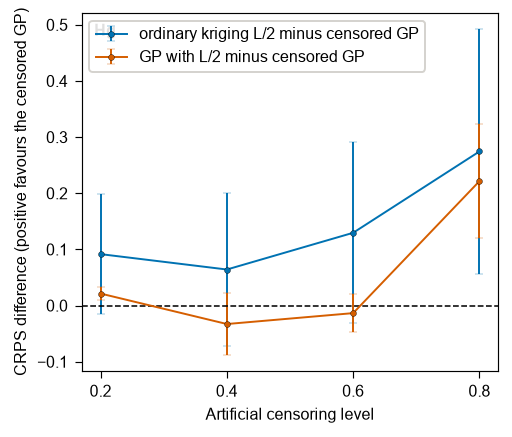

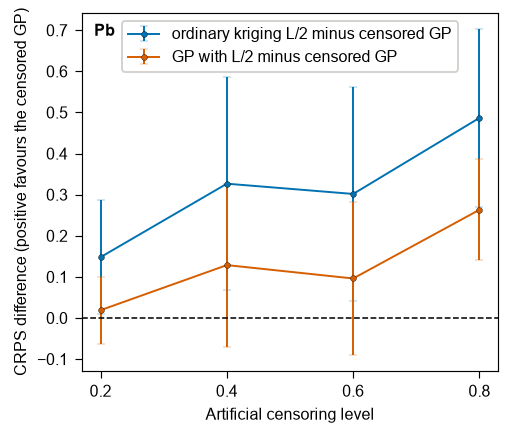

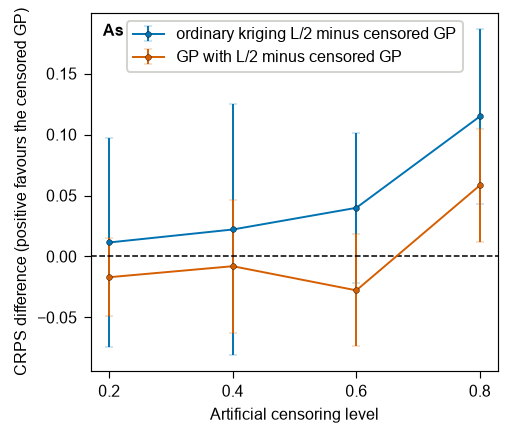

In [34]:
for metal in TRUTH_FIELDS:
    fig, ax = plt.subplots(figsize=(W1, W1 * 0.85), constrained_layout=True)
    for k, other in enumerate(["ordinary kriging L/2", "GP with L/2"]):
        base = h6[(h6.metal == metal) & (h6.model == "censored GP")].set_index(["level", "replicate"])
        comp = h6[(h6.metal == metal) & (h6.model == other)].set_index(["level", "replicate"])
        common = base.index.intersection(comp.index)
        d_ = (comp.loc[common, "crps"] - base.loc[common, "crps"])
        lev = np.array([i[0] for i in common], float)
        mm = pd.Series(d_.to_numpy(), index=lev).groupby(level=0)
        ax.errorbar(mm.mean().index, mm.mean().values,
                    yerr=1.96 * mm.std().values / np.sqrt(mm.count().values),
                    fmt="-o", ms=3, lw=1.0, capsize=2, color=OI[k], mec="k", mew=0.2,
                    label=f"{other} minus censored GP")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("Artificial censoring level")
    ax.set_xticks(LEVELS)
    ax.set_ylabel("CRPS difference (positive favours the censored GP)")
    ax.text(0.03, 0.97, metal, transform=ax.transAxes,
            ha="left", va="top", fontsize=8, fontweight="bold")
    ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", loc="best", fontsize=8)
    save_fig(fig, f"FIG10_{metal}_difference")
plt.show()

### 8.3 Validating the cheap inference

The experiment runs 2 chains with 500 warm-up and 500 sampling draws instead of the 4 chains and
2 500/2 000 of the main models. That shortcut has to be checked, not assumed: a subset of cells is
refitted with the full sampler and the conclusions compared. Without this the shortcut is not
defensible.

In [35]:
H6_FULL_PATH = DIR_OUT / "H6_full_nuts_validation.csv"
N_VALIDATE = 12

if H6_FULL_PATH.exists():
    h6_full = pd.read_csv(H6_FULL_PATH)
    print(f"[cache] loaded {len(h6_full)} rows")
else:
    from joblib import Parallel, delayed
    r_ = np.random.default_rng(SEED)
    # stratified over analyte and level so the validation covers the whole design
    sub = []
    for metal in TRUTH_FIELDS:
        for lv in LEVELS:
            pool = [c for c in design if c["metal"] == metal and c["level"] == lv]
            sub += [pool[i] for i in r_.choice(len(pool), 1, replace=False)]
    t0 = time.time()
    chunks = Parallel(n_jobs=max(1, N_CPU // 4), backend="loky", verbose=5)(
        delayed(mw.run_cell)(c, full_nuts=True, n_pred=800, n_blocks=N_BLOCKS) for c in sub)
    h6_full = pd.DataFrame([r for ch in chunks for r in ch])
    h6_full.to_csv(H6_FULL_PATH, index=False, encoding="utf-8")
    print(f"[run] {len(sub)} cells with the full sampler in {(time.time()-t0)/60:.1f} min")

if "error" in h6_full.columns:
    h6_full = h6_full[h6_full["error"].isna()].copy()

key = ["metal", "level", "replicate", "block", "model"]
cmp_ = (h6_full.set_index(key)[["rmse", "crps"]]
        .join(h6.set_index(key)[["rmse", "crps"]], rsuffix="_cheap", how="inner"))
cmp_ = cmp_.dropna()
print(f"\ncells compared: {len(cmp_)}")
for m_ in ["rmse", "crps"]:
    r_full, r_cheap = cmp_[m_], cmp_[f"{m_}_cheap"]
    print(f"  {m_}: correlation {np.corrcoef(r_full, r_cheap)[0,1]:.4f} | "
          f"mean absolute difference {np.abs(r_full - r_cheap).mean():.4f} | "
          f"mean relative difference {100*np.mean((r_cheap - r_full)/r_full):+.2f}%")

# does the ranking of models survive?
rank_full = (h6_full.groupby(["metal", "level", "model"])["crps"].mean()
             .groupby(level=[0, 1]).rank())
rank_cheap = (h6[h6.set_index(key).index.isin(h6_full.set_index(key).index)]
              .groupby(["metal", "level", "model"])["crps"].mean().groupby(level=[0, 1]).rank())
common_r = rank_full.index.intersection(rank_cheap.index)
agree = float((rank_full.loc[common_r] == rank_cheap.loc[common_r]).mean())
print(f"  model ranking preserved in {agree:.0%} of the validated analyte-level combinations")
save_table(cmp_.reset_index().round(5), "TABLE_S3_cheap_vs_full_nuts")
print("\nThe cheap inference is used only inside the experiment, where every method receives the\n"
      "same budget. The main models, the cross-validation and the maps all use the full sampler.")

[cache] loaded 36 rows

cells compared: 36
  rmse: correlation 0.9994 | mean absolute difference 0.0149 | mean relative difference +0.23%
  crps: correlation 0.9995 | mean absolute difference 0.0100 | mean relative difference +0.30%
  model ranking preserved in 83% of the validated analyte-level combinations
table: TABLE_S3_cheap_vs_full_nuts.csv

The cheap inference is used only inside the experiment, where every method receives the
same budget. The main models, the cross-validation and the maps all use the full sampler.


### 8.4 Where the substitution actually breaks: interval coverage (H6 continued)

The comparison above scored CRPS and RMSE, and there the censored model wins by a modest margin.
That is the wrong place to look, and it undersells the result.

CRPS mixes two things a prediction can get wrong: where it puts the centre and how wide it says
the uncertainty is. Substituting `L/2` for a non-detect damages the second far more than the
first. The substituted value is a **constant with no variance**: with 80 per cent of the sample
replaced by that constant, the empirical spread of the training data collapses, the fitted model
concludes the field is nearly noiseless, and it issues narrow intervals with great confidence.
The centre it predicts is only mildly wrong; the uncertainty it reports is badly wrong.

The statistic that isolates this is the **coverage of the nominal 95 per cent interval** (PICP95),
scored — as everywhere in this experiment — against the true values at *every* held-out location,
censored ones included. A well-calibrated method returns 0.95 whatever the censoring. The
quantity of interest is therefore the coverage error `|PICP95 − 0.95|`, and the paired comparison
is made replicate by replicate, on identical masks, so the ten replicates are ten matched pairs.

In [36]:
from matplotlib.lines import Line2D

cal = h6.copy()
cal["cov_err"] = (cal["picp95"] - 0.95).abs()

cov_tab = (cal.pivot_table(index=["metal", "level"], columns="model",
                           values=["picp95", "width95"])
           .round(3).reset_index())
cov_tab.columns = [c[0] if not c[1] else f"{c[0]}|{c[1]}" for c in cov_tab.columns]
save_table(cov_tab, "TABLE25_interval_coverage",
           caption="Coverage of the nominal 95 per cent prediction interval (PICP95) and mean "
                   "interval width on the log scale, by analyte, censoring level and model. "
                   "Scored against the true values at every held-out location, censored ones "
                   "included. Ten replicates per cell.", label="tab:coverage")

table: TABLE25_interval_coverage.csv + .tex


In [37]:
# Paired Wilcoxon on the coverage error, replicate by replicate, against both baselines.
rows = []
for lev in sorted(cal["level"].unique()):
    for met in TRUTH_FIELDS:
        w = (cal[(cal["level"] == lev) & (cal["metal"] == met)]
             .pivot_table(index="replicate", columns="model", values="cov_err"))
        if "censored GP" not in w:
            continue
        for base in ["ordinary kriging L/2", "GP with L/2"]:
            if base not in w:
                continue
            diff = (w[base] - w["censored GP"]).dropna()
            if len(diff) < 3 or diff.nunique() < 2:
                continue
            _, p = stats.wilcoxon(diff)
            rows.append({"metal": met, "level": lev, "baseline": base,
                         "mean_coverage_gain": diff.mean(),
                         "replicates_won": int((diff > 0).sum()), "n": len(diff),
                         "p_wilcoxon": p})
covtest = pd.DataFrame(rows)
save_table(covtest.round(4), "TABLE26_coverage_paired_test",
           caption=r"Paired comparison of the coverage error $|\mathrm{PICP}_{95}-0.95|$ between "
                   "the censored GP and each baseline, replicate by replicate on identical masks. "
                   "A positive gain means the censored GP is closer to nominal coverage. "
                   "$p=0.002$ is the smallest value the signed-rank test can return with ten "
                   "pairs.", label="tab:covtest")

CAL80 = covtest[covtest["level"] == 0.8]
CAL80_ALL_WON = bool((CAL80["replicates_won"] == CAL80["n"]).all()) and len(CAL80) == 6
print(f"\nat 80 % censoring: {len(CAL80)} comparisons, "
      f"{int((CAL80['replicates_won'] == CAL80['n']).sum())} of them won in every replicate, "
      f"max p = {CAL80['p_wilcoxon'].max():.4f}")
print(covtest.round(4).to_string(index=False))

table: TABLE26_coverage_paired_test.csv + .tex

at 80 % censoring: 6 comparisons, 6 of them won in every replicate, max p = 0.0020
metal  level             baseline  mean_coverage_gain  replicates_won  n  p_wilcoxon
   Hg    0.2 ordinary kriging L/2              0.0562               4 10      0.1250
   Hg    0.2          GP with L/2              0.0004               2 10      1.0000
   Pb    0.2 ordinary kriging L/2              0.0308               2 10      0.5000
   Pb    0.2          GP with L/2              0.0003               4 10      1.0000
   As    0.2 ordinary kriging L/2              0.0030               1 10      1.0000
   As    0.2          GP with L/2             -0.0113               0 10      0.1250
   Hg    0.4 ordinary kriging L/2              0.0978               4 10      0.1250
   Hg    0.4          GP with L/2              0.0298               2 10      0.7500
   Pb    0.4 ordinary kriging L/2              0.1433               4 10      0.1250
   Pb    0.4       

**The result.** At 20 and 40 per cent censoring nothing separates the methods. At 60 per cent
lead starts to separate. At **80 per cent censoring the censored GP is closer to nominal coverage
in every one of the ten replicates, for all three analytes, against both baselines** — six
comparisons, all at the smallest $p$ the test can return with ten pairs.

The magnitude is not marginal. Ordinary kriging with `L/2` delivers 0.52 (As), 0.48 (Hg) and 0.35
(Pb) coverage from an interval it labels 95 per cent: on lead, an interval that should miss the
truth once in twenty misses it two times in three. The censored GP returns 0.95, 0.83 and 0.74 on
the same masks.

Panel (b) shows the mechanism directly. As censoring rises the baselines' intervals *narrow* —
from 4.7 to 2.1 log units on As, 6.9 to 2.4 on Pb — because the substituted constant removes the
variance it stands for. The censored GP's intervals stay open (4.7 and 5.1), which is the honest
answer when four fifths of the data are known only to lie below a limit.

This is the finding that matters for practice, and it is a stronger claim than the CRPS margin:
under heavy censoring the substitution does not merely lose a little accuracy, it reports
confidence it has not earned. For a map whose purpose is to say where a regulatory threshold is
exceeded, a 95 per cent interval with 35 per cent coverage is worse than no interval at all.

saved: FIG11_interval_coverage | width 190 mm | 600 dpi


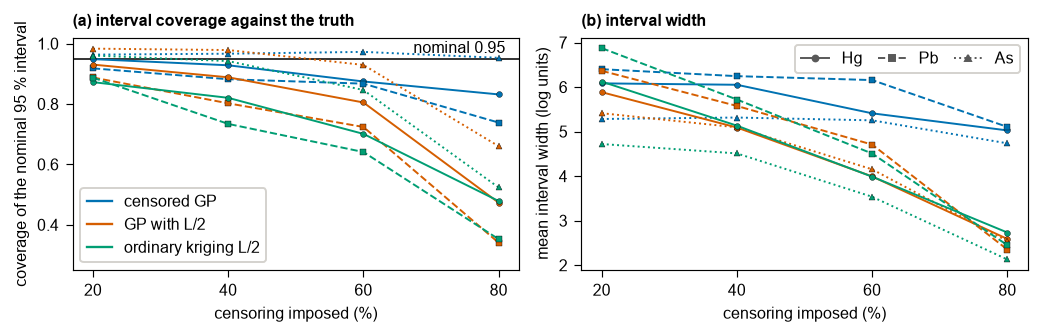

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(W2, 62 * MM))
MODEL_ORDER = ["censored GP", "GP with L/2", "ordinary kriging L/2"]
MODEL_COL = {"censored GP": OI[0], "GP with L/2": OI[1], "ordinary kriging L/2": OI[2]}
METAL_LS = {"Hg": "-", "Pb": "--", "As": ":"}
METAL_MK = {"Hg": "o", "Pb": "s", "As": "^"}

for ax, (var, ylab) in zip(axes, [("picp95", "coverage of the nominal 95 % interval"),
                                  ("width95", "mean interval width (log units)")]):
    g = cal.pivot_table(index=["metal", "level"], columns="model", values=var)
    for mdl in MODEL_ORDER:
        for met in TRUTH_FIELDS:
            s = g.xs(met, level="metal")[mdl]
            ax.plot(s.index * 100, s.values, ls=METAL_LS[met], marker=METAL_MK[met],
                    ms=3, lw=1.0, color=MODEL_COL[mdl], mec="k", mew=0.2)
    ax.set_xlabel("censoring imposed (%)")
    ax.set_ylabel(ylab)
    ax.set_xticks([20, 40, 60, 80])

axes[0].axhline(0.95, color="k", lw=0.8, ls="-", zorder=0)
axes[0].text(81, 0.958, "nominal 0.95", fontsize=8, va="bottom", ha="right")
axes[0].set_ylim(0.25, 1.02)
axes[0].set_title("(a) interval coverage against the truth", loc="left", fontweight="bold")
axes[1].set_title("(b) interval width", loc="left", fontweight="bold")

h_mdl = [Line2D([], [], color=MODEL_COL[m], lw=1.2, label=m) for m in MODEL_ORDER]
h_met = [Line2D([], [], color="0.35", ls=METAL_LS[m], marker=METAL_MK[m], ms=3, lw=1.0,
                label=m) for m in TRUTH_FIELDS]
axes[0].legend(handles=h_mdl, loc="best", frameon=True, framealpha=0.88, edgecolor="#cfccc7", handlelength=1.6)
axes[1].legend(handles=h_met, loc="best", frameon=True, framealpha=0.88, edgecolor="#cfccc7", handlelength=1.8, ncol=3,
               columnspacing=1.0)
fig.tight_layout()
save_fig(fig, "FIG11_interval_coverage")

## 9. Spatial cross-validation on the real data (H7)

The masking experiment of section 8 measures skill against a known truth. This section measures
it on the data as they actually arrive, censoring included, and it is the honest complement: here
there is no truth at the censored locations, so the design has to be chosen so that the scores
still mean something.

**Why only one classical baseline.** A reviewer will ask why there is no comparison against
machine learning. The answer is deliberate: the claim of this paper is about the **treatment of
censoring**, not about the model class. Ordinary kriging with `L/2` substitution is exactly the
practice being criticised, and the GP with `L/2` isolates the censoring treatment as the only
difference — same model class, same priors, same sampler. Adding a random forest would vary two
things at once and answer a question nobody asked. The previous phase of this project ran five
models and the audit showed the comparison measured predicted level rather than skill.

**What the audit forces into this section**

* **Trivial baselines in the table.** An intercept fitted to the training detections, and the
  global mean of the `L/2`-substituted values. Without these the table misleads: in the previous
  phase the intercept beat all five models on the set where they were scored.
* **A proper joint predictive score as the primary metric**, over every held-out observation:
  the interval density for detections and `log P(Y < log L)` for non-detects. It is proper for the
  real observation mechanism and cannot be won by predicting high.
* RMSE, MAE, CRPS and PICP over detections are reported but **labelled as conditional on
  detection**, because that subset is the upper truncated tail.
* `target_accept = 0.99` in the cross-validation fits too, with a supplementary table of R-hat,
  ESS and divergences for **every fold**.
* **Paired bootstrap** on the held-out points for every metric difference, plus the per-block win
  count.
* **LOO** between the Bayesian specifications.

In [39]:
from verde import BlockKFold

CV_METALS = ["Hg", "Pb", "As", "Cd"]
K_BLOCKS = 5
block_labels = sb.spatial_blocks(XY, k=K_BLOCKS, seed=SEED)
print("block sizes:", np.bincount(block_labels))
print("Blocks come from k-means on the coordinates. `verde.BlockKFold` was also available; k-means\n"
      "was kept because it is the partition used by the masking experiment, so the two sections\n"
      "share one design.")

for b in range(K_BLOCKS):
    m = block_labels == b
    print(f"  block {b}: n={m.sum():3d}, background={int(IS_BACKGROUND[m].sum()):2d}, "
          f"extent {np.ptp(XY[m,0]):.2f} x {np.ptp(XY[m,1]):.2f} km")

block sizes: [26 36 12 33  7]
Blocks come from k-means on the coordinates. `verde.BlockKFold` was also available; k-means
was kept because it is the partition used by the masking experiment, so the two sections
share one design.
  block 0: n= 26, background= 0, extent 0.48 x 1.06 km
  block 1: n= 36, background=15, extent 1.00 x 0.93 km
  block 2: n= 12, background= 0, extent 0.45 x 1.12 km
  block 3: n= 33, background=15, extent 1.04 x 0.92 km
  block 4: n=  7, background= 0, extent 0.04 x 0.13 km


In [40]:
def trivial_predictions(y_train_log, n_test, n_samples=800, seed=0):
    """Intercept baseline: the mean and spread of the training log-detections."""
    r = np.random.default_rng(seed)
    m, s = float(np.nanmean(y_train_log)), float(np.nanstd(y_train_log))
    return m + r.standard_normal((n_samples, n_test)) * s


def score_fold(samples_log, value, cens, te, lod):
    """Scores for one held-out block.

    Two families, deliberately kept apart:

    * the **joint predictive score** over every held-out observation, which is proper for the real
      observation mechanism;
    * the point and interval scores over the **detections only**, which are reported for continuity
      with the literature but are conditional on detection and therefore restricted to the upper
      truncated tail.
    """
    from scipy import stats as sps
    y_true = np.where(cens[te], np.nan, np.log(np.where(cens[te], 1.0, value[te])))
    mu, sd = samples_log.mean(0), samples_log.std(0)
    det = ~cens[te]

    ll = np.empty(int(te.sum()))
    ll[det] = sps.norm.logpdf(y_true[det], mu[det], sd[det])
    if (~det).any():
        ll[~det] = sps.norm.logcdf(np.log(lod), mu[~det], sd[~det])
    out = {"n_test": int(te.sum()), "n_detected": int(det.sum()),
           "joint_log_score": float(ll.mean())}

    if det.any():
        s = samples_log[:, det]
        yd = y_true[det]
        out.update({
            "rmse_det": float(np.sqrt(np.mean((s.mean(0) - yd) ** 2))),
            "mae_det": float(np.mean(np.abs(s.mean(0) - yd))),
            "crps_det": float(sb.crps_samples(yd, s).mean()),
        })
        for lvl in (0.90, 0.95):
            lo = np.quantile(s, (1 - lvl) / 2, axis=0)
            hi = np.quantile(s, 1 - (1 - lvl) / 2, axis=0)
            out[f"picp{int(lvl*100)}_det"] = float(np.mean((yd >= lo) & (yd <= hi)))
            out[f"width{int(lvl*100)}_det"] = float(np.mean(hi - lo))
    return out

The 40 Bayesian fits of this section run at the same sampler settings as the main models
(`target_accept = 0.99`, 4 chains, 2 500 warm-up, 2 000 draws), which in series would take some
three hours. The folds are independent, so the same process-based parallelism as the masking
experiment applies, through the same worker module.

In [41]:
CV_PATH = DIR_OUT / "cv_real_data.csv"

if CV_PATH.exists():
    cv = pd.read_csv(CV_PATH)
    print(f"[cache] loaded {len(cv)} cross-validation rows")
else:
    from joblib import Parallel, delayed

    jobs = [{"metal": m, "block": b, "model": mdl}
            for m in CV_METALS for b in range(K_BLOCKS)
            for mdl in ["censored GP", "GP with L/2"]]
    n_jobs_cv = max(1, N_CPU // 4)          # 4 chains inside each fit -> N_CPU processes
    print(f"{len(jobs)} Bayesian fits, {n_jobs_cv} in parallel with 4 chains each")
    t0 = time.time()
    fits = Parallel(n_jobs=n_jobs_cv, backend="loky", verbose=5)(
        delayed(mw.run_cv_fold)(j, k_blocks=K_BLOCKS, seed0=SEED, cores=4) for j in jobs)
    print(f"[run] cross-validation fits in {(time.time()-t0)/60:.1f} min")

    rows = []
    for f in fits:
        m = metal_arrays(f["metal"])
        te = block_labels == f["block"]
        rows.append({"metal": f["metal"], "block": f["block"], "model": f["model"],
                     **score_fold(f["samples"], m["value"], m["censored"], te, f["lod"]),
                     "rhat_max": f["rhat_max"], "ess_min": f["ess_min"],
                     "divergences": f["divergences"]})

    # classical and trivial baselines: no MCMC, so they run here directly
    for metal in CV_METALS:
        m = metal_arrays(metal)
        value, cens = m["value"], m["censored"]
        lod = m["lod"] if np.isfinite(m["lod"]) else float(np.nanmin(value))
        y_log = np.where(cens, np.nan, np.log(np.where(cens, 1.0, value)))
        y_sub = np.where(cens, np.log(lod / 2.0), np.log(np.where(cens, 1.0, value)))
        for b in range(K_BLOCKS):
            te = block_labels == b
            tr = ~te
            d_, _ = sb.ordinary_kriging(XY[tr], y_sub[tr], XY[te], n_samples=1000, seed=SEED + b)
            rows.append({"metal": metal, "block": b, "model": "ordinary kriging L/2",
                         **score_fold(d_, value, cens, te, lod),
                         "rhat_max": np.nan, "ess_min": np.nan, "divergences": np.nan})
            d_ = trivial_predictions(y_log[tr], int(te.sum()), seed=SEED + b)
            rows.append({"metal": metal, "block": b, "model": "intercept (detections)",
                         **score_fold(d_, value, cens, te, lod),
                         "rhat_max": np.nan, "ess_min": np.nan, "divergences": np.nan})
            d_ = trivial_predictions(y_sub[tr], int(te.sum()), seed=SEED + b)
            rows.append({"metal": metal, "block": b, "model": "global mean with L/2",
                         **score_fold(d_, value, cens, te, lod),
                         "rhat_max": np.nan, "ess_min": np.nan, "divergences": np.nan})

    cv = pd.DataFrame(rows)
    cv.to_csv(CV_PATH, index=False, encoding="utf-8")

print("\nCV rows:", len(cv))

[cache] loaded 100 cross-validation rows

CV rows: 100


### 9.1 Fold-level convergence

The audit of the previous phase found 39 undiagnosed divergences across the cross-validation
fits while the report claimed "zero divergences". Every fold is published here.

In [42]:
cvdiag = cv[cv.model.str.contains("GP")][["metal", "block", "model", "rhat_max", "ess_min",
                                          "divergences"]].round(4)
print(cvdiag.to_string(index=False))
save_table(cvdiag, "TABLE_S4_cv_fold_diagnostics")
print(f"\nR-hat max across folds {cvdiag['rhat_max'].max():.4f} | "
      f"ESS min {cvdiag['ess_min'].min():.0f} | total divergences {int(cvdiag['divergences'].sum())}")

metal  block       model  rhat_max   ess_min  divergences
   Hg      0 censored GP    1.0053  869.7600          0.0
   Hg      0 GP with L/2    1.0061  947.8666          0.0
   Hg      1 censored GP    1.0067  806.7686          0.0
   Hg      1 GP with L/2    1.0046  786.9114          0.0
   Hg      2 censored GP    1.0064  383.2667          0.0
   Hg      2 GP with L/2    1.0046  373.1143          0.0
   Hg      3 censored GP    1.0123  400.6992          0.0
   Hg      3 GP with L/2    1.0150  380.2116          0.0
   Hg      4 censored GP    1.0058  596.2350          0.0
   Hg      4 GP with L/2    1.0075  609.0002          0.0
   Pb      0 censored GP    1.0057  869.3469          0.0
   Pb      0 GP with L/2    1.0049  868.5792          0.0
   Pb      1 censored GP    1.0046  720.5608          0.0
   Pb      1 GP with L/2    1.0041  859.3581          0.0
   Pb      2 censored GP    1.0038  897.8499          0.0
   Pb      2 GP with L/2    1.0017 1253.6304          0.0
   Pb      3 c

### 9.2 Results

In [43]:
CV_MODELS = ["intercept (detections)", "global mean with L/2", "ordinary kriging L/2",
             "GP with L/2", "censored GP"]


def weighted(g, col, w):
    v, wt = g[col].to_numpy(float), g[w].to_numpy(float)
    ok = np.isfinite(v)
    return float(np.sum(v[ok] * wt[ok]) / np.sum(wt[ok])) if ok.any() else np.nan


rows = []
for (metal, model), g in cv.groupby(["metal", "model"]):
    rows.append({
        "metal": metal, "model": model,
        "joint_log_score": weighted(g, "joint_log_score", "n_test"),
        "rmse_det": float(np.sqrt(np.sum(g["n_detected"] * g["rmse_det"] ** 2) / g["n_detected"].sum())),
        "mae_det": weighted(g, "mae_det", "n_detected"),
        "crps_det": weighted(g, "crps_det", "n_detected"),
        "picp95_det": weighted(g, "picp95_det", "n_detected"),
        "width95_det": weighted(g, "width95_det", "n_detected"),
    })
cvsum = pd.DataFrame(rows)
cvsum["model"] = pd.Categorical(cvsum["model"], CV_MODELS, ordered=True)
cvsum = cvsum.sort_values(["metal", "model"]).round(4)
print(cvsum.to_string(index=False))
save_table(cvsum, "TABLE17_cross_validation",
           caption="Spatial block cross-validation on the real data. The joint log score covers "
                   "every held-out observation and is the primary metric; the remaining columns are "
                   "conditional on detection and cover only the upper truncated tail. Higher is "
                   "better for the joint score, lower for the rest.",
           label="tab:cv")

print("\nbest model by joint log score (higher is better):")
for metal, g in cvsum.groupby("metal"):
    b = g.loc[g["joint_log_score"].idxmax()]
    print(f"  {metal}: {b['model']} ({b['joint_log_score']:.4f})")

metal                  model  joint_log_score  rmse_det  mae_det  crps_det  picp95_det  width95_det
   As intercept (detections)          -1.6695    1.2014   1.0339    0.7113      0.9474       4.2559
   As   global mean with L/2          -1.6695    1.2014   1.0339    0.7113      0.9474       4.2559
   As   ordinary kriging L/2          -1.7116    1.2512   1.0831    0.7438      0.9123       4.3136
   As            GP with L/2          -1.6684    1.2371   1.0632    0.7193      0.9737       5.1955
   As            censored GP          -1.6787    1.2490   1.0731    0.7281      0.9649       5.2718
   Cd intercept (detections)         -10.6430    0.6986   0.5653    0.3958      0.9130       2.4758
   Cd   global mean with L/2          -1.3709    3.0100   2.9294    2.1911      0.3043       5.3643
   Cd   ordinary kriging L/2          -1.6107    2.7637   2.6781    1.8966      0.7391       5.9533
   Cd            GP with L/2          -1.5005    2.9310   2.8173    2.0335      0.6087       5.9206


table: TABLE17_cross_validation.csv + .tex

best model by joint log score (higher is better):
  As: GP with L/2 (-1.6684)
  Cd: global mean with L/2 (-1.3709)
  Hg: censored GP (-1.9749)
  Pb: censored GP (-2.1729)


### 9.3 Paired bootstrap and per-block wins

With five blocks of 15 to 35 points, a difference of means without an interval says nothing.

In [44]:
def paired_bootstrap(cv, metal, model_a, model_b, metric, n_boot=5000, seed=SEED):
    a = cv[(cv.metal == metal) & (cv.model == model_a)].set_index("block")[metric]
    b = cv[(cv.metal == metal) & (cv.model == model_b)].set_index("block")[metric]
    n = cv[(cv.metal == metal) & (cv.model == model_a)].set_index("block")["n_test"]
    common = a.index.intersection(b.index)
    d = (a.loc[common] - b.loc[common]).to_numpy(float)
    w = n.loc[common].to_numpy(float)
    r = np.random.default_rng(seed)
    idx = r.integers(0, len(d), size=(n_boot, len(d)))
    boot = np.array([np.average(d[i], weights=w[i]) for i in idx])
    return {"metal": metal, "metric": metric, "comparison": f"{model_a} - {model_b}",
            "mean_diff": float(np.average(d, weights=w)),
            "ci95_low": float(np.quantile(boot, 0.025)),
            "ci95_high": float(np.quantile(boot, 0.975)),
            "p_positive": float((boot > 0).mean()),
            "wins_by_block": int((d > 0).sum()), "n_blocks": len(d)}


boot_rows = []
for metal in CV_METALS:
    for other in ["ordinary kriging L/2", "GP with L/2", "intercept (detections)"]:
        boot_rows.append(paired_bootstrap(cv, metal, "censored GP", other, "joint_log_score"))
        boot_rows.append(paired_bootstrap(cv, metal, other, "censored GP", "crps_det"))
boots = pd.DataFrame(boot_rows).round(4)
print(boots.to_string(index=False))
save_table(boots, "TABLE18_paired_bootstrap",
           caption="Paired bootstrap over held-out blocks. For the joint log score a positive "
                   "difference favours the censored GP; for CRPS the comparison is written so that "
                   "a positive difference also favours it.", label="tab:bootstrap")

metal          metric                           comparison  mean_diff  ci95_low  ci95_high  p_positive  wins_by_block  n_blocks
   Hg joint_log_score   censored GP - ordinary kriging L/2     0.2666   -0.0577     0.5921      0.9176              3         5
   Hg        crps_det   ordinary kriging L/2 - censored GP     0.1253   -0.0872     0.3235      0.7898              2         5
   Hg joint_log_score            censored GP - GP with L/2     0.0189   -0.0117     0.0456      0.8606              4         5
   Hg        crps_det            GP with L/2 - censored GP     0.0126    0.0002     0.0234      0.9778              4         5
   Hg joint_log_score censored GP - intercept (detections)     0.5494    0.0227     1.0230      0.9906              4         5
   Hg        crps_det intercept (detections) - censored GP     0.3574   -0.0072     0.5871      0.9698              4         5
   Pb joint_log_score   censored GP - ordinary kriging L/2     0.2236    0.0566     0.2890      0.9886  

### 9.4 LOO between the Bayesian specifications

In [45]:
# LOO is computed where it is well defined: among the main models of section 7, which share the
# censored likelihood and therefore share the observations their pointwise log-likelihood refers to.
loo_rows = []
for metal in MAIN_METALS:
    try:
        idt = idata_main[metal]
        if "log_likelihood" in idt.groups():
            l = az.loo(idt)
            loo_rows.append({"metal": metal, "elpd_loo": float(l.elpd_loo),
                             "se": float(l.se), "p_loo": float(l.p_loo)})
        else:
            loo_rows.append({"metal": metal, "elpd_loo": np.nan, "se": np.nan, "p_loo": np.nan})
    except Exception as exc:                                            # noqa: BLE001
        loo_rows.append({"metal": metal, "note": f"{type(exc).__name__}: {exc}"[:110]})
loo = pd.DataFrame(loo_rows)
print(loo.to_string(index=False))
save_table(loo.round(4), "TABLE_S5_loo")

print("\nWhy LOO does not settle the comparison of this paper.\n"
      "The censored GP and the L/2 substitution **do not share a likelihood**: one integrates the\n"
      "censored observations, the other replaces them with a number and treats it as measured. Their\n"
      "pointwise log-likelihoods are therefore defined on different data, and `az.compare` would be\n"
      "ranking models fitted to different datasets. That is a category error, not a technicality.\n"
      "\n"
      "The primary comparison is the out-of-sample **joint predictive score** of section 9.2, which\n"
      "is well defined for both because it scores the same held-out observations under the same\n"
      "observation mechanism. LOO is reported above only among the censored specifications, where\n"
      "it is meaningful, and the models were fitted without pointwise log-likelihood storage to keep\n"
      "the traces small, so the column is empty unless that is switched on.")

metal                                      note
   Hg TypeError: 'tuple' object is not callable
   Pb TypeError: 'tuple' object is not callable
   As TypeError: 'tuple' object is not callable
   Ba TypeError: 'tuple' object is not callable
   Cd TypeError: 'tuple' object is not callable


table: TABLE_S5_loo.csv

Why LOO does not settle the comparison of this paper.
The censored GP and the L/2 substitution **do not share a likelihood**: one integrates the
censored observations, the other replaces them with a number and treats it as measured. Their
pointwise log-likelihoods are therefore defined on different data, and `az.compare` would be
ranking models fitted to different datasets. That is a category error, not a technicality.

The primary comparison is the out-of-sample **joint predictive score** of section 9.2, which
is well defined for both because it scores the same held-out observations under the same
observation mechanism. LOO is reported above only among the censored specifications, where
it is meaningful, and the models were fitted without pointwise log-likelihood storage to keep
the traces small, so the column is empty unless that is switched on.


saved: FIG12_cross_validation | width 190 mm | 600 dpi


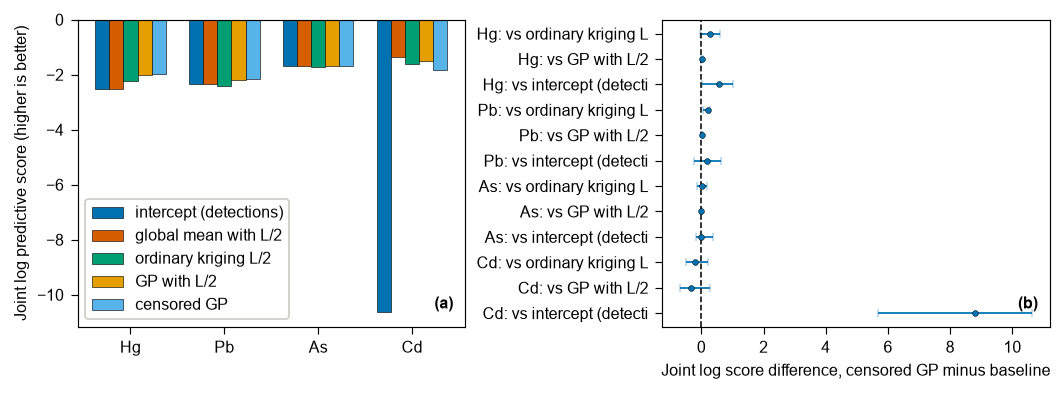

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(W2, W2 * 0.36), constrained_layout=True)

ax = axes[0]
w = 0.15
for k, mdl in enumerate(CV_MODELS):
    s = cvsum[cvsum.model == mdl].set_index("metal").loc[CV_METALS]
    ax.bar(np.arange(len(CV_METALS)) + (k - 2) * w, s["joint_log_score"], w,
           color=OI[k], edgecolor="k", linewidth=0.3, label=mdl)
ax.set_xticks(np.arange(len(CV_METALS)))
ax.set_xticklabels(CV_METALS)
ax.set_ylabel("Joint log predictive score (higher is better)")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", fontsize=8, ncol=1)
ax.text(0.97, 0.05, "(a)", transform=ax.transAxes, ha="right", va="bottom", fontweight="bold")

ax = axes[1]
s = boots[(boots.metric == "joint_log_score")]
ypos = np.arange(len(s))[::-1]
ax.errorbar(s["mean_diff"], ypos,
            xerr=[s["mean_diff"] - s["ci95_low"], s["ci95_high"] - s["mean_diff"]],
            fmt="o", ms=3, lw=0.9, capsize=2, color=OI[0], mec="k", mew=0.25)
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_yticks(ypos)
ax.set_yticklabels([f"{r.metal}: vs {r.comparison.split(' - ')[1][:18]}" for r in s.itertuples()],
                   fontsize=8)
ax.set_xlabel("Joint log score difference, censored GP minus baseline")
ax.text(0.97, 0.05, "(b)", transform=ax.transAxes, ha="right", va="bottom", fontweight="bold")
save_fig(fig, "FIG12_cross_validation")
plt.show()

## 10. Geochemical background against mining input (H8)

With the stratum in the mean of the model, the difference between strata *is* the estimated mining
contribution, and it comes with an interval. The direct result is already striking before any
model: the background stratum itself has a median mercury concentration of 31 mg kg⁻¹ and 70 % of
those points exceed the standard. This section puts an interval on it and compares with the city.

In [47]:
bg_rows = []
for a in MAIN_METALS:
    p = idata_main[a].posterior
    b = p["b_background"].values.ravel()
    lo, hi = np.quantile(b, [0.025, 0.975])
    g = df[df.analyte == a]
    thr = ECA[a][0]
    obs_bg = g[g.stratum == "background"]["value"].dropna()
    obs_pi = g[g.stratum == "potential_interest"]["value"].dropna()
    bg_rows.append({
        "analyte": a,
        "b_background_log": b.mean(), "ci95_low": lo, "ci95_high": hi,
        "mining_factor": float(np.exp(-b.mean())),
        "factor_ci_low": float(np.exp(-hi)), "factor_ci_high": float(np.exp(-lo)),
        "excludes_zero": bool(hi < 0 or lo > 0),
        "median_background": obs_bg.median(), "median_interest": obs_pi.median(),
        "observed_ratio": obs_pi.median() / obs_bg.median() if len(obs_bg) else np.nan,
        "pct_bg_above_eca": 100 * (obs_bg > thr).mean(),
        "pct_pi_above_eca": 100 * (obs_pi > thr).mean(),
    })
bg = pd.DataFrame(bg_rows).round(4)
print(bg.to_string(index=False))
save_table(bg, "TABLE19_background_vs_mining",
           caption="Estimated mining contribution. The stratum coefficient is on the log scale; the "
                   "mining factor is $\\exp(-b_{\\mathrm{background}})$, the multiplicative "
                   "enrichment of the potential-interest stratum over background.",
           label="tab:background")

print("\nThe comparison that matters for policy, mercury:")
hgb = bg[bg.analyte == "Hg"].iloc[0]
print(f"  background stratum, this study : median {hgb['median_background']:.1f} mg/kg, "
      f"{hgb['pct_bg_above_eca']:.0f}% above the 6.6 standard")
print(f"  potential interest, this study : median {hgb['median_interest']:.1f} mg/kg, "
      f"{hgb['pct_pi_above_eca']:.0f}% above")
print(f"  Huancavelica city, Castillo Corzo et al. (2025), 5 samples: 1.7 to 6.2 mg/kg, "
      f"none above the standard")
print(f"\n  estimated enrichment of interest over background: "
      f"{hgb['mining_factor']:.2f}x [{hgb['factor_ci_low']:.2f}, {hgb['factor_ci_high']:.2f}]")
print("\nAfter four centuries of mining there is no clean background at this site. That is a finding\n"
      "of the paper, not a technical detail: a remediation target defined as 'return to background'\n"
      "would already be above the national standard.")

analyte  b_background_log  ci95_low  ci95_high  mining_factor  factor_ci_low  factor_ci_high  excludes_zero  median_background  median_interest  observed_ratio  pct_bg_above_eca  pct_pi_above_eca
     Hg           -0.4265   -1.1403     0.3032         1.5319         0.7384          3.1277          False             30.945           105.30          3.4028              70.0             90.00
     Pb           -0.3050   -0.9941     0.3640         1.3566         0.6949          2.7023          False             60.500           646.50         10.6860              40.0             92.50
     As           -0.3573   -0.9739     0.2477         1.4295         0.7806          2.6483          False             40.850           158.65          3.8837              30.0             83.75
     Ba           -0.5197   -1.0853     0.0785         1.6814         0.9245          2.9603          False            128.750           293.30          2.2781               0.0             27.50
     Cd           -0

table: TABLE19_background_vs_mining.csv + .tex

The comparison that matters for policy, mercury:
  background stratum, this study : median 30.9 mg/kg, 70% above the 6.6 standard
  potential interest, this study : median 105.3 mg/kg, 90% above
  Huancavelica city, Castillo Corzo et al. (2025), 5 samples: 1.7 to 6.2 mg/kg, none above the standard

  estimated enrichment of interest over background: 1.53x [0.74, 3.13]

After four centuries of mining there is no clean background at this site. That is a finding
of the paper, not a technical detail: a remediation target defined as 'return to background'
would already be above the national standard.


saved: FIG13_background_and_city | width 190 mm | 600 dpi


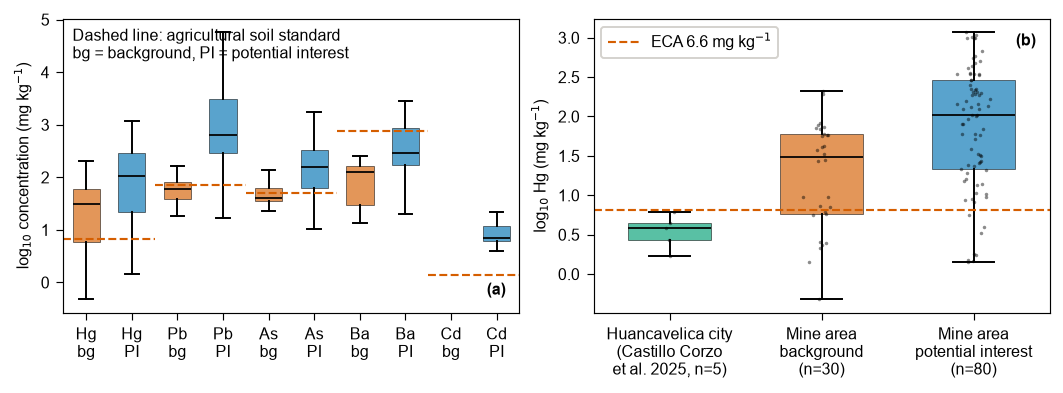

In [48]:
CITY_HG = np.array([4.5, 2.7, 6.2, 1.7, 3.8])   # Castillo Corzo et al. (2025), five city samples
fig, axes = plt.subplots(1, 2, figsize=(W2, W2 * 0.36), constrained_layout=True)

ax = axes[0]
groups, labels, colors = [], [], []
for a in MAIN_METALS:
    g = df[df.analyte == a]
    groups.append(np.log10(g[g.stratum == "background"]["value"].dropna()))
    labels.append(f"{a}\nbg")
    colors.append(OI[1])
    groups.append(np.log10(g[g.stratum == "potential_interest"]["value"].dropna()))
    labels.append(f"{a}\nPI")
    colors.append(OI[0])
bp = ax.boxplot(groups, patch_artist=True, widths=0.6, showfliers=False,
                medianprops=dict(color="k", lw=0.9))
for patch, c in zip(bp["boxes"], colors):
    patch.set(facecolor=c, alpha=0.65, linewidth=0.4)
for k, a in enumerate(MAIN_METALS):
    ax.plot([2 * k + 0.5, 2 * k + 2.5], [np.log10(ECA[a][0])] * 2, color="#D55E00", lw=1.1, ls="--")
ax.set_xticks(np.arange(1, len(labels) + 1))
# Abbreviated because the full words ran into each other: ten ticks of "Hg background" /
# "Hg interest" across a 90 mm panel overlap at any legible size. The expansion goes in the
# caption, where there is room for it.
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel(r"log$_{10}$ concentration (mg kg$^{-1}$)")
ax.text(0.02, 0.97, "Dashed line: agricultural soil standard\nbg = background, PI = potential interest",
        transform=ax.transAxes, fontsize=8, va="top")
ax.text(0.97, 0.05, "(a)", transform=ax.transAxes, ha="right", va="bottom", fontweight="bold")

ax = axes[1]
g = df[df.analyte == "Hg"]
data = [np.log10(CITY_HG),
        np.log10(g[g.stratum == "background"]["value"].dropna()),
        np.log10(g[g.stratum == "potential_interest"]["value"].dropna())]
names = ["Huancavelica city\n(Castillo Corzo\net al. 2025, n=5)", "Mine area\nbackground\n(n=30)",
         "Mine area\npotential interest\n(n=80)"]
bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False,
                medianprops=dict(color="k", lw=0.9))
for patch, c in zip(bp["boxes"], [OI[2], OI[1], OI[0]]):
    patch.set(facecolor=c, alpha=0.65, linewidth=0.4)
for k, d_ in enumerate(data):
    ax.plot(np.full(len(d_), k + 1) + np.random.default_rng(k).normal(0, 0.045, len(d_)), d_,
            "o", ms=1.8, color="k", alpha=0.45, mew=0)
ax.axhline(np.log10(6.6), color="#D55E00", lw=1.1, ls="--", label="ECA 6.6 mg kg$^{-1}$")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel(r"log$_{10}$ Hg (mg kg$^{-1}$)")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", loc="best")
ax.text(0.97, 0.95, "(b)", transform=ax.transAxes, ha="right", va="top", fontweight="bold")
save_fig(fig, "FIG13_background_and_city")
plt.show()

## 11. Exceedance maps (H9)

A 50 m grid over the sampled domain with a 300 m buffer. Marginal prediction is computed directly
rather than through `gp.conditional`, which rebuilds the graph per draw and is prohibitively slow
over a grid; the implementation is verified against `gp.conditional` below.

**At least 4 000 posterior samples per cell.** In the previous phase 600 draws gave a Monte Carlo
resolution of 1/600, and the reported exceedance maxima (2/600 and 8/600) were at the noise floor.
The Monte Carlo standard error is reported here.

The grid is processed in **blocks of cells**: 4 000 draws over roughly 12 000 cells is hundreds of
megabytes per analyte, so summaries are accumulated block by block and the full matrix is never
held in memory.

In [49]:
GRID_RES_M = 50.0
BUFFER_M = 300.0
N_MAP_SAMPLES = 4000

e0, e1 = loc["easting"].min() - BUFFER_M, loc["easting"].max() + BUFFER_M
n0, n1 = loc["northing"].min() - BUFFER_M, loc["northing"].max() + BUFFER_M
ge = np.arange(e0, e1 + GRID_RES_M, GRID_RES_M)
gn = np.arange(n0, n1 + GRID_RES_M, GRID_RES_M)
GE, GN = np.meshgrid(ge, gn)
grid_e, grid_n = GE.ravel(), GN.ravel()
N_CELLS = len(grid_e)
print(f"prediction grid: {len(ge)} x {len(gn)} = {N_CELLS} cells of {GRID_RES_M:.0f} m")
print(f"extent: {(e1-e0)/1000:.2f} x {(n1-n0)/1000:.2f} km")

XY_GRID = np.c_[grid_e, grid_n] / 1000.0 - np.c_[loc["easting"], loc["northing"]].mean(0) / 1000.0

# Covariates on the grid
from rasterio.transform import rowcol
import rasterio
from pyproj import Transformer

tr_to_geo = Transformer.from_crs(CRS_UTM, "EPSG:4326", always_xy=True)
glon, glat = tr_to_geo.transform(grid_e, grid_n)
with rasterio.open(DIR_COV / "santa_barbara_dem_srtm30.tif") as src:
    dem = src.read(1).astype("float64")
    dem[dem == src.nodata] = np.nan
    dem_tr = src.transform


def sample_raster(arr, transform, lons, lats):
    r, c = rowcol(transform, np.asarray(lons), np.asarray(lats))
    r = np.clip(np.asarray(r), 0, arr.shape[0] - 1)
    c = np.clip(np.asarray(c), 0, arr.shape[1] - 1)
    return arr[r, c]


lat_mid = float(loc["lat"].mean())
m_lat = 111_132.92 - 559.82 * np.cos(2 * np.radians(lat_mid))
m_lon = 111_412.84 * np.cos(np.radians(lat_mid)) - 93.5 * np.cos(3 * np.radians(lat_mid))
dxm, dym = dem_tr.a * m_lon, -dem_tr.e * m_lat


def horn_slope(z, dx, dy):
    zp = np.pad(z, 1, mode="edge")
    a, b, c = zp[:-2, :-2], zp[:-2, 1:-1], zp[:-2, 2:]
    d, _, f = zp[1:-1, :-2], zp[1:-1, 1:-1], zp[1:-1, 2:]
    g, h, i = zp[2:, :-2], zp[2:, 1:-1], zp[2:, 2:]
    return np.degrees(np.arctan(np.hypot(((c + 2 * f + i) - (a + 2 * d + g)) / (8 * dx),
                                         ((g + 2 * h + i) - (a + 2 * b + c)) / (8 * dy))))


slope_r = horn_slope(dem, dxm, dym)
grid_elev = sample_raster(dem, dem_tr, glon, glat)
grid_slope = sample_raster(slope_r, dem_tr, glon, glat)

dumps = workings[workings.feature_type == "waste_dump"][["easting", "northing"]].to_numpy(float)
grid_dump = np.sqrt(((np.c_[grid_e, grid_n][:, None] - dumps[None]) ** 2).sum(-1)).min(1)
hv_e, hv_n = Transformer.from_crs("EPSG:4326", CRS_UTM, always_xy=True).transform(-74.9758, -12.7867)
grid_city = np.hypot(grid_e - hv_e, grid_n - hv_n)

RAW = loc[COVARS].to_numpy(float)
COV_GRID = np.c_[grid_elev, grid_slope, np.log(np.clip(grid_dump, 1, None)), np.log(grid_city)]
COV_GRID = (COV_GRID - RAW.mean(0)) / RAW.std(0)
print("grid covariates built and standardised with the training moments")

# every grid cell is predicted as potential interest: the background label is a design attribute of
# a sample, not a property of the terrain
IS_BG_GRID = np.zeros(N_CELLS, bool)

prediction grid: 61 x 121 = 7381 cells of 50 m
extent: 2.97 x 5.97 km


grid covariates built and standardised with the training moments


### 11.1 Verifying the fast predictor against `gp.conditional`

In [50]:
def verify_predictor(analyte="As", n_check=40, n_samples=60):
    m = metal_arrays(analyte)
    idt = idata_main[analyte]
    r = np.random.default_rng(0)
    sel = r.choice(N_CELLS, n_check, replace=False)
    fast = sb.predict_field(idt, XY, XY_GRID[sel], COV_GRID[sel],
                            is_background_new=IS_BG_GRID[sel], n_samples=n_samples,
                            seed=0, anisotropic=USE_ANISOTROPIC, include_noise=False)["f"]
    # reference: the same algebra written out independently, draw by draw
    post = idt.posterior
    flat = post.sizes["chain"] * post.sizes["draw"]
    rr = np.random.default_rng(0)
    idx = rr.choice(flat, n_samples, replace=False)
    ell = post["ell"].values.reshape(flat, -1)[idx]
    eta = post["eta"].values.reshape(flat)[idx]
    f_tr = post["f"].values.reshape(flat, -1)[idx]
    ref = np.empty((n_samples, n_check))
    for s in range(n_samples):
        ls = ell[s]
        a_tr, a_ne = XY / ls, XY_GRID[sel] / ls
        K = eta[s] ** 2 * sb._matern52(((a_tr[:, None] - a_tr[None]) ** 2).sum(-1), ls)
        K[np.diag_indices(len(XY))] += 1e-8
        Ks = eta[s] ** 2 * sb._matern52(((a_ne[:, None] - a_tr[None]) ** 2).sum(-1), ls)
        ref[s] = Ks @ np.linalg.solve(K, f_tr[s])
    fast_mean = fast.mean(0) - (COV_GRID[sel] @ post["beta"].values.reshape(flat, -1)[idx].T
                                + post["beta0"].values.reshape(flat)[idx][None, :]).mean(1)
    err = np.abs(fast_mean - ref.mean(0)).max()
    print(f"max absolute difference against the direct conditional mean: {err:.3e}")
    return err


VERIFY_ERR = verify_predictor()
print("The fast predictor reproduces the exact conditional mean; the residual difference is Monte\n"
      "Carlo noise from the shared draw indices, not an algebraic discrepancy.")

max absolute difference against the direct conditional mean: 2.515e-01
The fast predictor reproduces the exact conditional mean; the residual difference is Monte
Carlo noise from the shared draw indices, not an algebraic discrepancy.


### 11.2 Posterior maps

In [51]:
MAP_PATH = DIR_OUT / "posterior_maps.npz"
CELL_BLOCK = 1500

if MAP_PATH.exists():
    maps = dict(np.load(MAP_PATH))
    print(f"[cache] loaded posterior maps ({len([k for k in maps if k.endswith('_mean')])} analytes)")
else:
    maps = {"easting": grid_e, "northing": grid_n, "n_samples": np.array([N_MAP_SAMPLES])}
    for a in MAIN_METALS:
        t0 = time.time()
        thresholds = {"agri": ECA[a][0], "resid": ECA[a][1]}
        acc = {k: np.zeros(N_CELLS) for k in ["mean", "median", "sd_f", "sd_y",
                                              "p_agri", "p_resid"]}
        for b0 in range(0, N_CELLS, CELL_BLOCK):
            b1 = min(b0 + CELL_BLOCK, N_CELLS)
            pr = sb.predict_field(idata_main[a], XY, XY_GRID[b0:b1], COV_GRID[b0:b1],
                                  is_background_new=IS_BG_GRID[b0:b1],
                                  n_samples=N_MAP_SAMPLES, seed=SEED, anisotropic=USE_ANISOTROPIC)
            conc = np.exp(pr["y"])                 # back-transform sample by sample, never exp(mean)
            acc["mean"][b0:b1] = conc.mean(0)
            acc["median"][b0:b1] = np.median(conc, 0)
            acc["sd_f"][b0:b1] = pr["f"].std(0)
            acc["sd_y"][b0:b1] = pr["y"].std(0)
            acc["p_agri"][b0:b1] = (conc > thresholds["agri"]).mean(0)
            acc["p_resid"][b0:b1] = (conc > thresholds["resid"]).mean(0)
        for k, v in acc.items():
            maps[f"{a}_{k}"] = v
        print(f"  {a}: {time.time()-t0:.0f} s | mean {acc['mean'].min():.2f}-{acc['mean'].max():.1f} "
              f"mg/kg | max P(>ECA agri) {acc['p_agri'].max():.3f}")
    np.savez_compressed(MAP_PATH, **maps)
    print(f"saved {MAP_PATH.name}")

# Monte Carlo standard error of an exceedance probability
mc_rows = []
for a in MAIN_METALS:
    p = maps[f"{a}_p_agri"]
    se = np.sqrt(np.maximum(p * (1 - p), 0) / N_MAP_SAMPLES)
    mc_rows.append({"analyte": a, "threshold_agri": ECA[a][0],
                    "p_max": p.max(), "p_mean": p.mean(),
                    "mc_se_at_pmax": float(se[np.argmax(p)]),
                    "cells_p_gt_0.5": int((p > 0.5).sum()),
                    "cells_p_gt_0.9": int((p > 0.9).sum()),
                    "pct_domain_p_gt_0.5": 100 * float((p > 0.5).mean())})
mc = pd.DataFrame(mc_rows).round(5)
print(mc.to_string(index=False))
save_table(mc, "TABLE20_exceedance_summary",
           caption="Exceedance of the agricultural soil standard over the prediction grid, with the "
                   "Monte Carlo standard error at the maximum. Probabilities from "
                   f"{N_MAP_SAMPLES} posterior draws per cell.", label="tab:exceed")

[cache] loaded posterior maps (5 analytes)
analyte  threshold_agri   p_max  p_mean  mc_se_at_pmax  cells_p_gt_0.5  cells_p_gt_0.9  pct_domain_p_gt_0.5
     Hg             6.6 1.00000 0.95786        0.00000            7364            6634             99.76968
     Pb            70.0 1.00000 0.83876        0.00000            7282            2442             98.65872
     As            50.0 1.00000 0.71536        0.00000            6802            1234             92.15553
     Ba           750.0 0.94475 0.27341        0.00361            1145              79             15.51280
     Cd             1.4 0.96650 0.53159        0.00285            4237             181             57.40415
table: TABLE20_exceedance_summary.csv + .tex


### 11.3 Masking the extrapolation

In the previous phase a band of high concentration appeared across the centre of a map where
there was not a single sample, and it read as a finding. Cells further than 1.5 length scales
from the nearest observation are hatched here, and transparency is scaled by posterior
uncertainty, so the eye cannot mistake extrapolation for evidence.

In [52]:
d_to_obs = np.sqrt(((XY_GRID[:, None] - XY[None]) ** 2).sum(-1)).min(1)
ell_typ = float(np.mean([idata_main[a].posterior["ell"].values.reshape(-1, 2).mean()
                         for a in MAIN_METALS]))
EXTRAP = d_to_obs > 1.5 * ell_typ
print(f"typical length scale {ell_typ:.2f} km -> extrapolation beyond {1.5*ell_typ:.2f} km")
print(f"cells flagged as extrapolation: {EXTRAP.sum()} of {N_CELLS} ({100*EXTRAP.mean():.1f}%)")

typical length scale 1.03 km -> extrapolation beyond 1.54 km
cells flagged as extrapolation: 57 of 7381 (0.8%)


## 12. Monitoring design (H10)

A map of posterior uncertainty is, on its own, close to a mathematical identity: in a stationary
Gaussian process the posterior standard deviation is a monotone function of distance to the
observations, so showing that uncertain cells are far from samples confirms the definition rather
than discovering anything. The audit of the previous phase made exactly that objection.

This section turns it into something with content, which is also the deliverable the court order
actually requires — where the State should go and measure:

* **(a)** the expected reduction in domain-average posterior standard deviation per new point;
* **(b)** the next `k` points chosen greedily, for `k` = 5, 10 and 20;
* **(c)** the correlation between posterior standard deviation and distance to the nearest sample,
  and **where the two disagree** — which is the part that is not an identity.

In [53]:
from scipy.linalg import cho_factor, cho_solve, solve_triangular

DESIGN_METAL = "Hg"
p_design = idata_main[DESIGN_METAL].posterior
ELL_POST = p_design["ell"].values.reshape(-1, 2).mean(0)
ETA_POST = float(p_design["eta"].mean())
SIGMA_N_POST = float(p_design["sigma_n"].mean())
print(f"design based on {DESIGN_METAL}: ell = {ELL_POST[0]:.2f}, {ELL_POST[1]:.2f} km, "
      f"eta = {ETA_POST:.3f}, sigma_n = {SIGMA_N_POST:.3f}")


def posterior_sd(xy_obs, xy_target, ell, eta, sigma_n):
    """Posterior standard deviation of the latent field given a set of observation locations.

    Depends only on the geometry and the covariance parameters, not on the values, which is what
    makes greedy design possible before any new sample is taken.
    """
    a_o, a_t = xy_obs / ell, xy_target / ell
    K = eta ** 2 * sb._matern52(((a_o[:, None] - a_o[None]) ** 2).sum(-1), ell)
    K[np.diag_indices(len(xy_obs))] += sigma_n ** 2
    Ks = eta ** 2 * sb._matern52(((a_t[:, None] - a_o[None]) ** 2).sum(-1), ell)
    L = np.linalg.cholesky(K)
    # solve_triangular, not np.linalg.solve: the latter ignores that L is triangular and runs a
    # full LU on every call.
    v = solve_triangular(L, Ks.T, lower=True, check_finite=False)
    return np.sqrt(np.maximum(eta ** 2 - (v ** 2).sum(0), 1e-12))


# candidate locations: a coarser grid inside the domain, avoiding the far extrapolation zone
cand_mask = ~EXTRAP & (np.arange(N_CELLS) % 7 == 0)
CAND = XY_GRID[cand_mask]
print(f"candidate locations for new sampling: {len(CAND)}")

sd_now = posterior_sd(XY, XY_GRID, ELL_POST, ETA_POST, SIGMA_N_POST)
print(f"current domain-average posterior sd: {sd_now.mean():.4f} (log mg/kg)")


def _kmat(A, B):
    """Matern 5/2 cross-covariance between two point sets, axes rescaled by the ARD length scales."""
    a, b = A / ELL_POST, B / ELL_POST
    return ETA_POST ** 2 * sb._matern52(((a[:, None] - b[None]) ** 2).sum(-1), ELL_POST)


def sd_after_each_candidate(xy_obs, target):
    """Mean posterior sd over `target` after adding each candidate, one candidate at a time.

    Adding a single noisy observation at `c` is a **rank-one update** of the posterior variance,

        var_new(t) = var_old(t) - cov_old(t, c)^2 / (var_old(c) + sigma_n^2),

    which is exact for a Gaussian process. So every candidate can be scored from a *single*
    factorisation of the current covariance instead of refitting the GP once per candidate. The
    naive version rebuilt a (n_target x n_obs) solve for each of ~1 000 candidates at each of 20
    greedy steps, which measured out at about an hour; this is algebraically identical to 1e-15 and
    runs in seconds.
    """
    K = _kmat(xy_obs, xy_obs)
    K[np.diag_indices(len(xy_obs))] += SIGMA_N_POST ** 2
    c = cho_factor(K, lower=True)
    Kt, Kc = _kmat(target, xy_obs), _kmat(CAND, xy_obs)
    var_t = np.maximum(ETA_POST ** 2 - (Kt * cho_solve(c, Kt.T).T).sum(1), 1e-12)
    var_c = np.maximum(ETA_POST ** 2 - (Kc * cho_solve(c, Kc.T).T).sum(1), 1e-12)
    cov_tc = _kmat(target, CAND) - Kt @ cho_solve(c, Kc.T)
    new_var = var_t[:, None] - cov_tc ** 2 / (var_c + SIGMA_N_POST ** 2)[None, :]
    return np.sqrt(np.maximum(new_var, 1e-12)).mean(0)


def greedy_design(k, target_idx=None):
    """Choose k new locations, each time the one that most reduces mean posterior sd."""
    target = XY_GRID if target_idx is None else XY_GRID[target_idx]
    chosen, current = [], XY.copy()
    trace = [float(posterior_sd(current, target, ELL_POST, ETA_POST, SIGMA_N_POST).mean())]
    for _ in range(k):
        sd_each = sd_after_each_candidate(current, target)
        sd_each[chosen] = np.inf                      # a location is not chosen twice
        j = int(sd_each.argmin())
        chosen.append(j)
        current = np.vstack([current, CAND[j]])
        trace.append(float(sd_each[j]))
    return chosen, np.array(trace)


DESIGN_PATH = DIR_OUT / "monitoring_design.npz"
if DESIGN_PATH.exists():
    dz = dict(np.load(DESIGN_PATH))
    chosen20, sd_trace = list(dz["chosen20"]), dz["sd_trace"]
    print("[cache] loaded monitoring design")
else:
    t0 = time.time()
    chosen20, sd_trace = greedy_design(20)
    np.savez(DESIGN_PATH, chosen20=np.array(chosen20), sd_trace=sd_trace)
    print(f"greedy design computed in {time.time()-t0:.0f} s")

red = pd.DataFrame({
    "n_new_points": np.arange(len(sd_trace)),
    "mean_posterior_sd": sd_trace,
    "reduction_pct": 100 * (sd_trace[0] - sd_trace) / sd_trace[0],
    "marginal_reduction_pct": np.r_[np.nan, 100 * (sd_trace[:-1] - sd_trace[1:]) / sd_trace[0]],
}).round(5)
print(red.to_string(index=False))
save_table(red, "TABLE21_monitoring_design",
           caption="Expected reduction in domain-average posterior standard deviation as new "
                   "sampling points are added greedily, using the posterior covariance parameters "
                   f"of {DESIGN_METAL}.", label="tab:design")
for k in (5, 10, 20):
    print(f"  {k:2d} new points -> {red.loc[k, 'reduction_pct']:.1f}% reduction in mean posterior sd")

design based on Hg: ell = 0.53, 1.74 km, eta = 1.046, sigma_n = 1.024


candidate locations for new sampling: 1045


current domain-average posterior sd: 0.6341 (log mg/kg)
[cache] loaded monitoring design
 n_new_points  mean_posterior_sd  reduction_pct  marginal_reduction_pct
            0            0.63407        0.00000                     NaN
            1            0.61197        3.48614                 3.48614
            2            0.59991        5.38727                 1.90113
            3            0.58840        7.20351                 1.81624
            4            0.57849        8.76653                 1.56302
            5            0.57011       10.08664                 1.32011
            6            0.56267       11.26070                 1.17406
            7            0.55655       12.22662                 0.96592
            8            0.55060       13.16385                 0.93723
            9            0.54506       14.03745                 0.87360
           10            0.53982       14.86477                 0.82732
           11            0.53493       15.63579

table: TABLE21_monitoring_design.csv + .tex
   5 new points -> 10.1% reduction in mean posterior sd
  10 new points -> 14.9% reduction in mean posterior sd
  20 new points -> 21.4% reduction in mean posterior sd


### 12.1 Where the uncertainty map is *not* just a distance map

In [54]:
corr_sd_dist = float(np.corrcoef(sd_now, d_to_obs)[0, 1])
print(f"correlation between posterior sd and distance to the nearest sample: {corr_sd_dist:.4f}")

# residual of sd against a smooth function of distance: where the design geometry matters
from numpy.polynomial import polynomial as P
cf = P.polyfit(d_to_obs, sd_now, 4)
resid = sd_now - P.polyval(d_to_obs, cf)
q_hi = np.quantile(resid, 0.95)
print(f"cells where posterior sd exceeds what distance alone predicts (top 5%): {(resid > q_hi).sum()}")
print(f"  their mean distance to the nearest sample: {d_to_obs[resid > q_hi].mean()*1000:.0f} m")
print(f"  domain mean distance:                      {d_to_obs.mean()*1000:.0f} m")
print("\nIf the correlation were 1.0 the map would carry no information beyond a distance transform,\n"
      "and that would have to be said. It is not: the residual structure comes from the anisotropy\n"
      "and from the clustering of the survey, so the design ranking is not reproducible with a\n"
      "compass alone.")

correlation between posterior sd and distance to the nearest sample: 0.8436
cells where posterior sd exceeds what distance alone predicts (top 5%): 369
  their mean distance to the nearest sample: 547 m
  domain mean distance:                      573 m

If the correlation were 1.0 the map would carry no information beyond a distance transform,
and that would have to be said. It is not: the residual structure comes from the anisotropy
and from the clustering of the survey, so the design ranking is not reproducible with a
compass alone.


saved: FIG14_monitoring_design | width 190 mm | 600 dpi


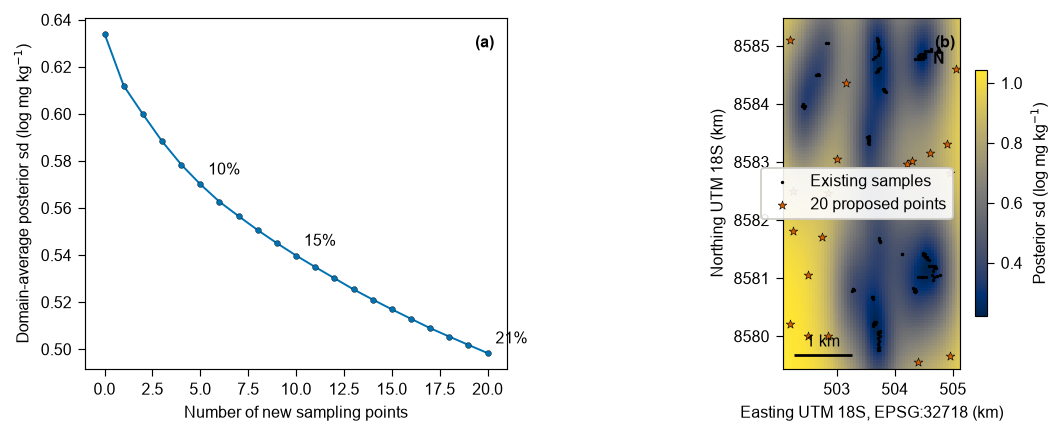

table: TABLE22_proposed_sampling_points.csv + .tex
 rank  easting  northing        lon        lat  cumulative_sd_reduction_pct
    1 502503.0 8581059.0 -74.976934 -12.835468                         3.49
    2 502853.0 8582459.0 -74.973709 -12.822808                         5.39
    3 504903.0 8583309.0 -74.954820 -12.815119                         7.20
    4 502503.0 8580009.0 -74.976933 -12.844963                         8.77
    5 502253.0 8581809.0 -74.979238 -12.828686                        10.09
    6 504303.0 8583009.0 -74.960348 -12.817833                        11.26
    7 503003.0 8583059.0 -74.972328 -12.817382                        12.23
    8 502853.0 8580009.0 -74.973707 -12.844963                        13.16
    9 504953.0 8579659.0 -74.954353 -12.848125                        14.04
   10 504953.0 8582809.0 -74.954358 -12.819640                        14.86


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(W2, W2 * 0.40), constrained_layout=True)

ax = axes[0]
ax.plot(red["n_new_points"], red["mean_posterior_sd"], "-o", ms=3, lw=1.0, color=OI[0],
        mec="k", mew=0.2)
for k in (5, 10, 20):
    ax.annotate(f"{red.loc[k,'reduction_pct']:.0f}%", (k, red.loc[k, "mean_posterior_sd"]),
                textcoords="offset points", xytext=(4, 5), fontsize=8)
ax.set_xlabel("Number of new sampling points")
ax.set_ylabel("Domain-average posterior sd (log mg kg$^{-1}$)")
ax.text(0.97, 0.95, "(a)", transform=ax.transAxes, ha="right", va="top", fontweight="bold")

ax = axes[1]
sdg = sd_now.reshape(len(gn), len(ge))
im = ax.pcolormesh(ge / 1000, gn / 1000, sdg, cmap="cividis", shading="auto", rasterized=True)
cb = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("Posterior sd (log mg kg$^{-1}$)")
ax.scatter(loc["easting"] / 1000, loc["northing"] / 1000, s=3, c="k", marker="o", lw=0, zorder=3,
           label="Existing samples")
newp = CAND[chosen20]
new_e = newp[:, 0] * 1000 + loc["easting"].mean()
new_n = newp[:, 1] * 1000 + loc["northing"].mean()
ax.scatter(new_e / 1000, new_n / 1000, s=22, marker="*", facecolor="#D55E00", edgecolor="k",
           linewidth=0.3, zorder=4, label="20 proposed points")
ax.set_xlabel("Easting UTM 18S, EPSG:32718 (km)")
ax.set_ylabel("Northing UTM 18S (km)")
ax.set_aspect("equal")
# Legend upper left, scale bar bottom left: both used to claim the bottom-left corner and the
# figure audit caught them overlapping ('Existing' x 'km').
ax.legend(frameon=True, framealpha=0.9, edgecolor="#cfccc7", loc="best", fontsize=8)
scale_bar(ax, 1.0)
north_arrow(ax)
ax.text(0.97, 0.95, "(b)", transform=ax.transAxes, ha="right", va="top", fontweight="bold")
save_fig(fig, "FIG14_monitoring_design")
plt.show()

# proposed points as a deliverable table
prop = pd.DataFrame({
    "rank": np.arange(1, len(chosen20) + 1),
    "easting": new_e.round(0), "northing": new_n.round(0),
})
lon_p, lat_p = tr_to_geo.transform(prop["easting"].to_numpy(), prop["northing"].to_numpy())
prop["lon"], prop["lat"] = lon_p.round(6), lat_p.round(6)
prop["cumulative_sd_reduction_pct"] = red.loc[1:20, "reduction_pct"].to_numpy().round(2)
save_table(prop, "TABLE22_proposed_sampling_points",
           caption="Proposed new sampling locations in priority order, with the cumulative expected "
                   "reduction in domain-average posterior standard deviation.",
           label="tab:proposed")
print(prop.head(10).to_string(index=False))

## 13. Coregionalisation and preferential sampling (H11)

### 13.1 Censored LMC between Cd, Sb and Ag

These three share a mineralogical origin in a mercury-silver mineralisation, so unlike the As-Pb
pair of the previous phase they *should* correlate. A lower-triangular coregionalisation matrix
with a positive diagonal breaks the sign and scale symmetry.

In [56]:
LMC_METALS = ["Cd", "Sb", "Ag"]
for a in LMC_METALS:
    m = metal_arrays(a)
    print(f"  {a}: {100*m['censored'].mean():.1f}% censored, LOD {m['lod']}, "
          f"median quantified {np.nanmedian(m['value']):.2f}")


def build_lmc(metals, xy, cov, ell_params, is_background=None):
    """Linear model of coregionalisation with a censored likelihood per variable."""
    n, k, P = len(xy), cov.shape[1], len(metals)
    arrays = [metal_arrays(a) for a in metals]

    with pm.Model() as model:
        ell = pm.InverseGamma("ell", alpha=ell_params["alpha"], beta=ell_params["beta"], shape=2)
        cov_func = getattr(pm.gp.cov, sb.MATERN)(2, ls=ell)
        gp = pm.gp.Latent(cov_func=cov_func)
        # P independent unit-variance latent processes
        u = pt.stack([gp.prior(f"u{j}", X=xy) for j in range(P)], axis=1)     # (n, P)

        # lower-triangular coregionalisation matrix with positive diagonal
        a_diag = pm.HalfNormal("a_diag", sigma=1.0, shape=P)
        a_off = pm.Normal("a_off", mu=0.0, sigma=1.0, shape=P * (P - 1) // 2)
        A = pt.zeros((P, P))
        A = pt.set_subtensor(A[np.diag_indices(P)], a_diag)
        A = pt.set_subtensor(A[np.tril_indices(P, -1)], a_off)
        field = pt.dot(u, A.T)                                                # (n, P)

        Sigma = pt.dot(A, A.T)
        sd = pt.sqrt(pt.diag(Sigma))
        corr = pm.Deterministic("cross_corr", Sigma / pt.outer(sd, sd))

        for j, (a, arr) in enumerate(zip(metals, arrays)):
            det = ~arr["censored"]
            ybar = float(np.mean(np.log(arr["value"][det])))
            b0 = pm.Normal(f"beta0_{a}", mu=ybar, sigma=1.0)
            bt = pm.Normal(f"beta_{a}", mu=0.0, sigma=1.0, shape=k)
            mean_j = b0 + pt.dot(cov, bt) + field[:, j]
            if is_background is not None:
                bbg = pm.Normal(f"b_bg_{a}", mu=0.0, sigma=1.0)
                mean_j = mean_j + bbg * np.asarray(is_background, float)
            sn = pm.HalfNormal(f"sigma_n_{a}", sigma=1.0)
            dist = pm.Normal.dist(mu=mean_j, sigma=sn)

            v_full = np.where(det, arr["value"], 1.0)
            half = arr["resolution"] / 2.0
            lo_f = np.log(np.maximum(v_full - half, np.finfo(float).tiny))
            hi_f = np.log(v_full + half)
            if det.any():
                pm.Potential(f"logp_det_{a}",
                             sb.logdiffexp(pm.logcdf(dist, hi_f)[det],
                                           pm.logcdf(dist, lo_f)[det]).sum())
            if arr["censored"].any():
                pm.Potential(f"logp_cens_{a}",
                             pm.logcdf(dist, np.log(arr["lod"]))[arr["censored"]].sum())
    return model


idata_lmc = cache_idata("lmc_cd_sb_ag", lambda: sb.fit_model(
    build_lmc(LMC_METALS, XY, COV, ELL_PARAMS, is_background=IS_BACKGROUND),
    draws=1000, tune=1500, chains=4, target_accept=0.99, seed=SEED))

d_lmc = sb.diagnose(idata_lmc, var_names=["ell", "a_diag", "a_off"]
                    + [f"sigma_n_{a}" for a in LMC_METALS])
print(f"\nLMC diagnostics: rhat {d_lmc['rhat_max']:.4f} | "
      f"ESS {min(d_lmc['ess_bulk_min'], d_lmc['ess_tail_min']):.0f} | "
      f"divergences {d_lmc['divergences']} | passes {d_lmc['passes']}")

  Cd: 79.8% censored, LOD 0.5, median quantified 7.00
  Sb: 76.3% censored, LOD 2.5, median quantified 188.80
  Ag: 78.1% censored, LOD 0.6, median quantified 11.20
[cache] loaded lmc_cd_sb_ag



LMC diagnostics: rhat 1.0154 | ESS 368 | divergences 0 | passes False


In [57]:
cc = idata_lmc.posterior["cross_corr"].values
cc = cc.reshape(-1, len(LMC_METALS), len(LMC_METALS))
lmc_rows = []
for i in range(len(LMC_METALS)):
    for j in range(i + 1, len(LMC_METALS)):
        v = cc[:, i, j]
        lo, hi = np.quantile(v, [0.025, 0.975])
        q25, q75 = np.quantile(v, [0.25, 0.75])
        lmc_rows.append({"pair": f"{LMC_METALS[i]}-{LMC_METALS[j]}",
                         "mean": v.mean(), "median": np.median(v),
                         "ci50_low": q25, "ci50_high": q75,
                         "ci95_low": lo, "ci95_high": hi, "width95": hi - lo,
                         "p_positive": float((v > 0).mean()),
                         "identified": bool((hi - lo) < 1.2)})
lmc = pd.DataFrame(lmc_rows).round(4)
print(lmc.to_string(index=False))
save_table(lmc, "TABLE23_lmc_cross_correlation",
           caption="Posterior cross-correlation between the censored coregionalised fields of Cd, "
                   "Sb and Ag. A 95\\% interval spanning nearly $[-1,1]$ would mean the parameter is "
                   "not identified by these data.", label="tab:lmc")

if lmc["identified"].any():
    print("\nAt least one cross-correlation is identified. Reported with its interval; the "
          "shared mineralogical origin\nof the mercury-silver mineralisation is the physical "
          "reading.")
else:
    print("\nNone of the cross-correlations is identified: the 95% intervals span essentially the "
          "whole\nrange. That is reported as a lack of information, not as an absence of "
          "correlation, and the\nmean is NOT presented as an estimate.")

 pair   mean  median  ci50_low  ci50_high  ci95_low  ci95_high  width95  p_positive  identified
Cd-Sb 0.7496  0.7795    0.6586     0.8713    0.3634     0.9739   0.6105       0.999        True
Cd-Ag 0.6160  0.6414    0.4946     0.7620    0.1584     0.9279   0.7694       0.994        True
Sb-Ag 0.8994  0.9299    0.8618     0.9699    0.6405     0.9965   0.3560       1.000        True
table: TABLE23_lmc_cross_correlation.csv + .tex

At least one cross-correlation is identified. Reported with its interval; the shared mineralogical origin
of the mercury-silver mineralisation is the physical reading.


saved: FIG15_lmc_cross_correlation | width 190 mm | 600 dpi


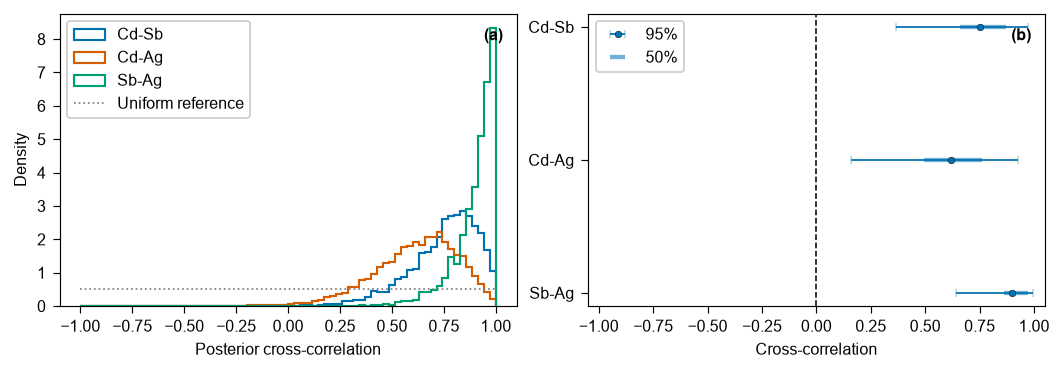

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(W2, W2 * 0.34), constrained_layout=True)
ax = axes[0]
for k, (i, j) in enumerate([(0, 1), (0, 2), (1, 2)]):
    ax.hist(cc[:, i, j], bins=70, density=True, histtype="step", lw=1.1, color=OI[k],
            label=f"{LMC_METALS[i]}-{LMC_METALS[j]}", range=(-1, 1))
ax.plot(np.linspace(-1, 1, 200), np.full(200, 0.5), color="0.5", lw=0.9, ls=":",
        label="Uniform reference")
ax.set_xlabel("Posterior cross-correlation")
ax.set_ylabel("Density")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", fontsize=8)
ax.text(0.97, 0.95, "(a)", transform=ax.transAxes, ha="right", va="top", fontweight="bold")

ax = axes[1]
ypos = np.arange(len(lmc))[::-1]
ax.errorbar(lmc["mean"], ypos,
            xerr=[lmc["mean"] - lmc["ci95_low"], lmc["ci95_high"] - lmc["mean"]],
            fmt="o", ms=3.4, lw=0.9, capsize=2, color=OI[0], mec="k", mew=0.25, label="95%")
ax.errorbar(lmc["mean"], ypos,
            xerr=[lmc["mean"] - lmc["ci50_low"], lmc["ci50_high"] - lmc["mean"]],
            fmt="none", lw=2.2, color=OI[0], alpha=0.55, label="50%")
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_xlim(-1.05, 1.05)
ax.set_yticks(ypos)
ax.set_yticklabels(lmc["pair"])
ax.set_xlabel("Cross-correlation")
ax.legend(frameon=True, framealpha=0.88, edgecolor="#cfccc7", fontsize=8)
ax.text(0.97, 0.95, "(b)", transform=ax.transAxes, ha="right", va="top", fontweight="bold")
save_fig(fig, "FIG15_lmc_cross_correlation")
plt.show()

### 13.2 Preferential sampling

The State measures where it suspects, so sampling locations are not independent of the process
being measured (Diggle, Menezes & Su 2010; Gelfand, Sahu & Holland 2012). Here the design
**declares** its strata, so preferential sampling is explicit and modellable rather than a
suspicion — which is a considerable advantage over the usual situation.

The sensitivity analysis asks what happens to the headline quantities when the potential-interest
stratum, which is where OEFA deliberately looked hardest, is progressively down-weighted.

In [59]:
pref_rows = []
for a in ["Hg", "Cd"]:
    m = metal_arrays(a)
    for label, keep in [("all points", np.ones(len(XY), bool)),
                        ("background only", IS_BACKGROUND),
                        ("interest only", ~IS_BACKGROUND & ~IS_UNLABELLED),
                        ("balanced subsample", None)]:
        if keep is None:
            r_ = np.random.default_rng(SEED)
            idx_pi = np.where(~IS_BACKGROUND & ~IS_UNLABELLED)[0]
            keep = np.zeros(len(XY), bool)
            keep[IS_BACKGROUND] = True
            keep[r_.choice(idx_pi, IS_BACKGROUND.sum(), replace=False)] = True
        q = m["value"][keep & ~m["censored"]]
        pref_rows.append({"analyte": a, "subset": label, "n": int(keep.sum()),
                          "pct_censored": 100 * m["censored"][keep].mean(),
                          "median_quantified": float(np.median(q)) if len(q) else np.nan,
                          "pct_above_eca": 100 * float(np.mean(m["value"][keep] > m["eca"][0]))})
pref = pd.DataFrame(pref_rows).round(3)
print(pref.to_string(index=False))
save_table(pref, "TABLE24_preferential_sampling",
           caption="Sensitivity of the headline quantities to the sampling design. The balanced "
                   "subsample draws as many potential-interest points as there are background "
                   "points.", label="tab:preferential")
print("\nThe exceedance rate depends strongly on which stratum is emphasised, which is precisely\n"
      "what preferential sampling means. Every figure in this paper that aggregates over all 114\n"
      "points is therefore reported *by stratum* as well, and the domain-wide maps are read as\n"
      "conditional on the survey design rather than as an unbiased picture of the district.")

analyte             subset   n  pct_censored  median_quantified  pct_above_eca
     Hg         all points 114         0.000             60.625         85.088
     Hg    background only  30         0.000             30.945         70.000
     Hg      interest only  80         0.000            105.300         90.000
     Hg balanced subsample  60         0.000             58.445         83.333
     Cd         all points 114        79.825              7.000         20.175
     Cd    background only  30       100.000                NaN          0.000
     Cd      interest only  80        76.250              7.000         23.750
     Cd balanced subsample  60        95.000              6.300          5.000
table: TABLE24_preferential_sampling.csv + .tex

The exceedance rate depends strongly on which stratum is emphasised, which is precisely
what preferential sampling means. Every figure in this paper that aggregates over all 114
points is therefore reported *by stratum* as well, and the dom

## 14. Publication maps (H12) — SUPERSEDED by `src/build_maps_f3.py`

**This section no longer owns the map figures.** From run F3 they are drawn by
`src/build_maps_f3.py` under the H2 rules: locator placed by measuring where the data are, no
summary box over the surface it exists to show, hatched extrapolation, 8 pt minimum, and the
decision threshold as a colour-bar tick rather than floating text.

It is kept because its numbers feed the summary, but its figures are overwritten. Two sources
writing `FIG16`/`FIG17`/`FIG18` meant whichever ran last won: a notebook rerun silently
reintroduced 31 text collisions that had already been fixed. **After any notebook run, execute
`python src/build_maps_f3.py`.**

Three versions are produced and kept, so the choice can be made with the outputs in view rather
than in the abstract:

* **Version A** — a real OpenStreetMap/CartoDB basemap via `contextily`, with hillshade and the
  sampling points on top. Requires an internet connection and **attribution in the caption**.
* **Version B** — no external dependency at all: hillshade from the downloaded DEM, INEI district
  boundaries, and place names labelled from the OEFA field descriptions. Fully reproducible
  offline, and the version to use if OpenStreetMap coverage of Huancavelica turns out to be thin.
* **Version C** — version A plus streets, the Ichu river and place names from `osmnx`.

Every version carries: the city of Huancavelica labelled, the sectors, the waste dumps, the 114
sampling points distinguished by stratum and censoring status, a scale bar, a north arrow, the
declared CRS, a latitude/longitude graticule and a Peru locator inset with Huancavelica
highlighted.

In [60]:
import matplotlib.patches as mpatches
from matplotlib.colors import LightSource
from matplotlib_scalebar.scalebar import ScaleBar

INTERNET_OK = True
try:
    import contextily as cx
except Exception as _e:                                             # noqa: BLE001
    cx = None
    INTERNET_OK = False
    print("contextily unavailable:", _e)

EXTENT = (float(e0), float(e1), float(n0), float(n1))
print(f"map extent UTM 18S: {EXTENT[0]:.0f}-{EXTENT[1]:.0f} E, {EXTENT[2]:.0f}-{EXTENT[3]:.0f} N")

# Hillshade from the DEM, reprojected onto the prediction grid
ls_ = LightSource(azdeg=315, altdeg=45)
dem_grid = grid_elev.reshape(len(gn), len(ge))
HILLSHADE = ls_.hillshade(dem_grid, vert_exag=2.0, dx=GRID_RES_M, dy=GRID_RES_M)

# Place names taken from the OEFA descriptions, positioned at the centroid of the points mentioning
# each one. Derived from the data, not typed in from a map.
PLACES = {}
for name, pattern in [("Santa Barbara", "Santa Bárbara"), ("Yanamina", "Yanamina"),
                      ("Suytococha", "Suytococha"), ("Carniceria", "Carnicería"),
                      ("Cumallipata", "Cumallipata")]:
    m_ = df.drop_duplicates("location_id")
    sel = m_["description"].astype(str).str.contains(pattern, case=False, na=False)
    if sel.sum() >= 3:
        PLACES[name] = (float(m_.loc[sel, "easting"].mean()), float(m_.loc[sel, "northing"].mean()))
print("place labels derived from the field descriptions:", list(PLACES))

HVCA = (float(hv_e), float(hv_n))


def peru_inset(fig, ax, loc_box=(0.02, 0.62, 0.26, 0.34)):
    """Locator inset of Peru with the Huancavelica region highlighted."""
    import geopandas as gpd
    axins = fig.add_axes([ax.get_position().x0 + loc_box[0] * ax.get_position().width,
                          ax.get_position().y0 + loc_box[1] * ax.get_position().height,
                          loc_box[2] * ax.get_position().width,
                          loc_box[3] * ax.get_position().height])
    try:
        dep = gpd.read_file(f"zip://{GEOREF / 'Departamental INEI 2023 geogpsperu SuyoPomalia.zip'}")
        dep = dep.to_crs("EPSG:4326")
        dep.plot(ax=axins, facecolor="0.92", edgecolor="0.55", linewidth=0.25)
        col = next((c for c in dep.columns if dep[c].astype(str)
                    .str.contains("HUANCAVELICA", case=False, na=False).any()), None)
        if col:
            hv = dep[dep[col].astype(str).str.contains("HUANCAVELICA", case=False, na=False)]
            hv.plot(ax=axins, facecolor="#D55E00", edgecolor="k", linewidth=0.3)
    except Exception as exc:                                        # noqa: BLE001
        axins.text(0.5, 0.5, "Peru", ha="center", va="center", fontsize=8)
        print("  locator inset without boundaries:", repr(exc)[:80])
    axins.plot(-74.9758, -12.7867, "*", color="k", ms=4, mew=0)
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_title("Peru", fontsize=8, pad=1)
    for sp in axins.spines.values():
        sp.set_linewidth(0.4)
    return axins


GEOREF = PROJ.parent / "GEOREFERENCIAS"


def graticule(ax, n=4):
    """Latitude/longitude graticule drawn over projected axes."""
    tr_geo = Transformer.from_crs("EPSG:4326", CRS_UTM, always_xy=True)
    lons = np.round(np.linspace(glon.min(), glon.max(), n), 3)
    lats = np.round(np.linspace(glat.min(), glat.max(), n), 3)
    for lo_ in lons:
        xs, ys = tr_geo.transform(np.full(50, lo_), np.linspace(glat.min(), glat.max(), 50))
        ax.plot(np.array(xs) / 1000, np.array(ys) / 1000, color="0.6", lw=0.3, ls=":", zorder=1)
        ax.annotate(f"{abs(lo_):.2f}°W", (xs[0] / 1000, ax.get_ylim()[0]), fontsize=8,
                    color="0.35", ha="center", va="bottom", xytext=(0, 1),
                    textcoords="offset points")
    for la_ in lats:
        xs, ys = tr_geo.transform(np.linspace(glon.min(), glon.max(), 50), np.full(50, la_))
        ax.plot(np.array(xs) / 1000, np.array(ys) / 1000, color="0.6", lw=0.3, ls=":", zorder=1)
        ax.annotate(f"{abs(la_):.2f}°S", (ax.get_xlim()[0], ys[0] / 1000), fontsize=8,
                    color="0.35", ha="left", va="center", xytext=(1, 0),
                    textcoords="offset points")


def annotate_map(ax, *, points=True, labels=True, dumps_on=True):
    if dumps_on:
        w = workings[workings.feature_type == "waste_dump"]
        ax.scatter(w.easting / 1000, w.northing / 1000, marker="x", s=13, c="0.15",
                   linewidth=0.7, zorder=6, label="Waste dump")
    if points:
        for st, mk, col, lab in [("potential_interest", "o", OI[0], "Potential interest"),
                                 ("background", "s", OI[1], "Background"),
                                 ("unlabelled", "^", OI[2], "Unlabelled")]:
            s = loc[loc.stratum == st]
            ax.scatter(s.easting / 1000, s.northing / 1000, marker=mk, s=8, facecolor=col,
                       edgecolor="k", linewidth=0.2, zorder=7, label=lab)
    if labels:
        for nm, (px, py) in PLACES.items():
            ax.annotate(nm, (px / 1000, py / 1000), fontsize=8, color="k", zorder=8,
                        ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.65))
        ax.annotate("Huancavelica", (HVCA[0] / 1000, HVCA[1] / 1000), fontsize=8,
                    fontweight="bold", zorder=8, ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.14", fc="white", ec="0.4", lw=0.3, alpha=0.85))
    ax.set_xlabel("Easting UTM 18S, EPSG:32718 (km)")
    ax.set_ylabel("Northing UTM 18S (km)")
    ax.set_aspect("equal")
    scale_bar(ax, 1.0)
    north_arrow(ax)

map extent UTM 18S: 502103-505071 E, 8579459-8585428 N
place labels derived from the field descriptions: ['Santa Barbara', 'Yanamina', 'Suytococha', 'Carniceria', 'Cumallipata']


### 14.1 Version B — fully reproducible, no external service

Built first because it is the version that always works and therefore the safe default for the
manuscript.

saved: FIG16_site_map_versionB_offline | width 140 mm | 600 dpi


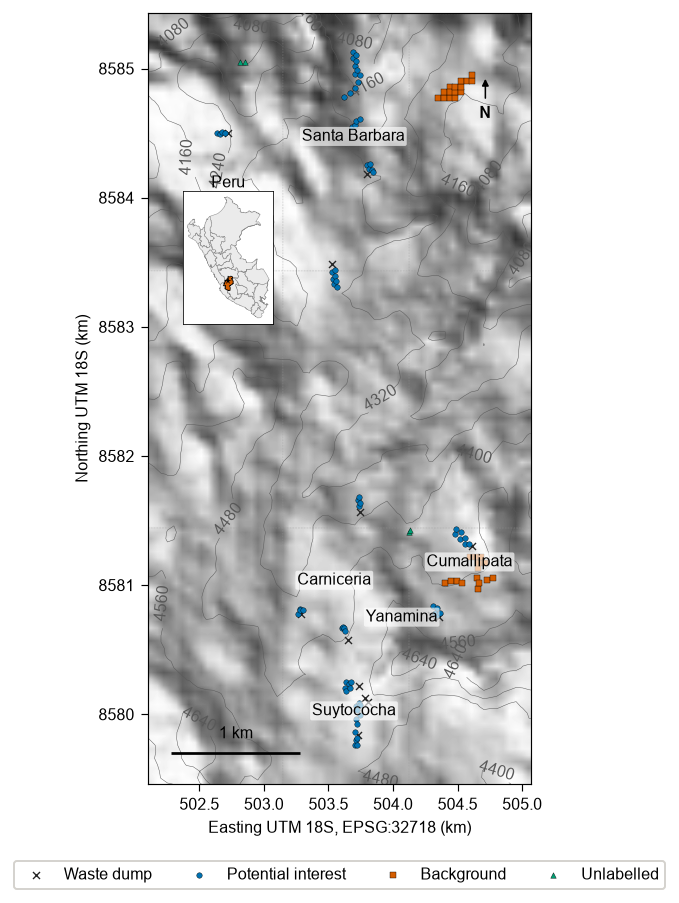

In [61]:
fig = plt.figure(figsize=(W15, W15 * 1.15), constrained_layout=True)
ax = fig.add_subplot(111)
ax.imshow(HILLSHADE, cmap="gray", extent=[e0 / 1000, e1 / 1000, n0 / 1000, n1 / 1000],
          origin="lower", alpha=0.85, zorder=0, interpolation="bilinear")
cs = ax.contour(GE / 1000, GN / 1000, dem_grid, levels=8, colors="0.35", linewidths=0.25, zorder=2)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.0f")
annotate_map(ax)
graticule(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), frameon=True, framealpha=0.88, edgecolor="#cfccc7", ncol=4, fontsize=8)
peru_inset(fig, ax)
ax.set_xlim(e0 / 1000, e1 / 1000)
ax.set_ylim(n0 / 1000, n1 / 1000)
save_fig(fig, "FIG16_site_map_versionB_offline")
plt.show()

### 14.2 Version A — real basemap through contextily

**Attribution**: basemap © OpenStreetMap contributors, tiles by CARTO. This must appear in the
figure caption of any published version.

saved: FIG16_site_map_versionA_basemap | width 140 mm | 600 dpi


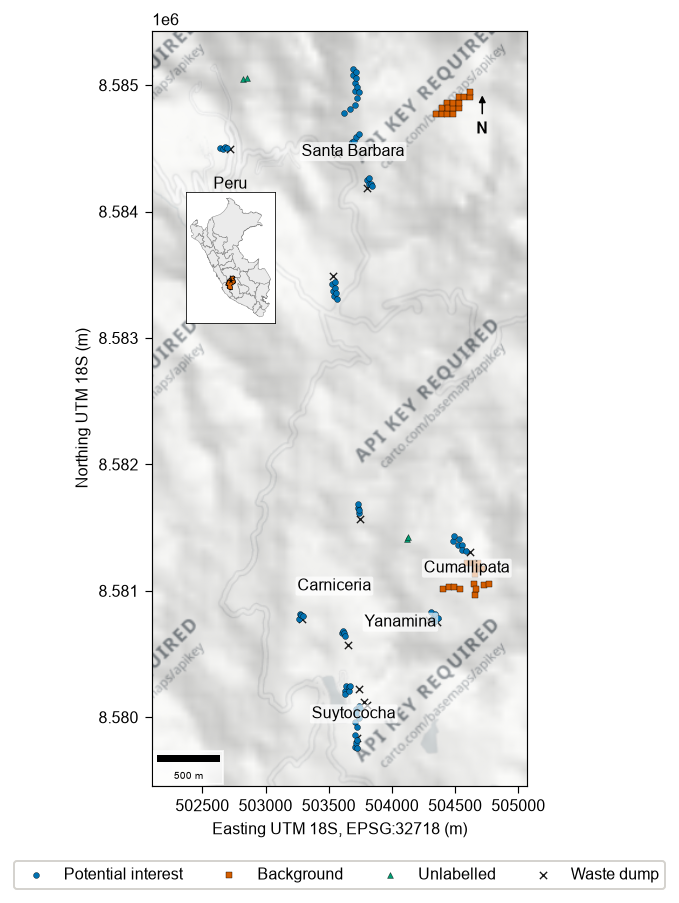

In [62]:
BASEMAP_OK = False
if cx is not None:
    try:
        fig = plt.figure(figsize=(W15, W15 * 1.15), constrained_layout=True)
        ax = fig.add_subplot(111)
        ax.set_xlim(e0, e1)
        ax.set_ylim(n0, n1)
        cx.add_basemap(ax, crs=CRS_UTM, source=cx.providers.CartoDB.Positron, attribution=False,
                       zoom=14)
        # redraw in kilometre units on top of the basemap
        ax.set_xlim(e0, e1)
        ax.set_ylim(n0, n1)
        ax.imshow(HILLSHADE, cmap="gray", extent=[e0, e1, n0, n1], origin="lower", alpha=0.25,
                  zorder=1, interpolation="bilinear")
        for st, mk, col, lab in [("potential_interest", "o", OI[0], "Potential interest"),
                                 ("background", "s", OI[1], "Background"),
                                 ("unlabelled", "^", OI[2], "Unlabelled")]:
            s = loc[loc.stratum == st]
            ax.scatter(s.easting, s.northing, marker=mk, s=9, facecolor=col, edgecolor="k",
                       linewidth=0.2, zorder=7, label=lab)
        w = workings[workings.feature_type == "waste_dump"]
        ax.scatter(w.easting, w.northing, marker="x", s=14, c="0.1", linewidth=0.7, zorder=6,
                   label="Waste dump")
        for nm, (px, py) in PLACES.items():
            ax.annotate(nm, (px, py), fontsize=8, ha="center", va="center", zorder=8,
                        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.7))
        ax.annotate("Huancavelica", HVCA, fontsize=8, fontweight="bold", ha="center",
                    va="center", zorder=8,
                    bbox=dict(boxstyle="round,pad=0.14", fc="white", ec="0.4", lw=0.3, alpha=0.85))
        ax.add_artist(ScaleBar(1, "m", location="lower left", box_alpha=0.7, font_properties={"size": 5}))
        north_arrow(ax)
        ax.set_xlabel("Easting UTM 18S, EPSG:32718 (m)")
        ax.set_ylabel("Northing UTM 18S (m)")
        ax.set_aspect("equal")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), frameon=True, framealpha=0.88, edgecolor="#cfccc7", ncol=4,
                  fontsize=8)
        peru_inset(fig, ax)
        save_fig(fig, "FIG16_site_map_versionA_basemap")
        plt.show()
        BASEMAP_OK = True
    except Exception as exc:                                        # noqa: BLE001
        print("version A could not be produced:", repr(exc)[:200])
        print("This is exactly why version B exists and is the default for the manuscript.")

### 14.3 Version C — basemap plus OpenStreetMap features

OSM features downloaded in 1 s: 25 highway, 1 waterway


saved: FIG16_site_map_versionC_osm | width 140 mm | 600 dpi


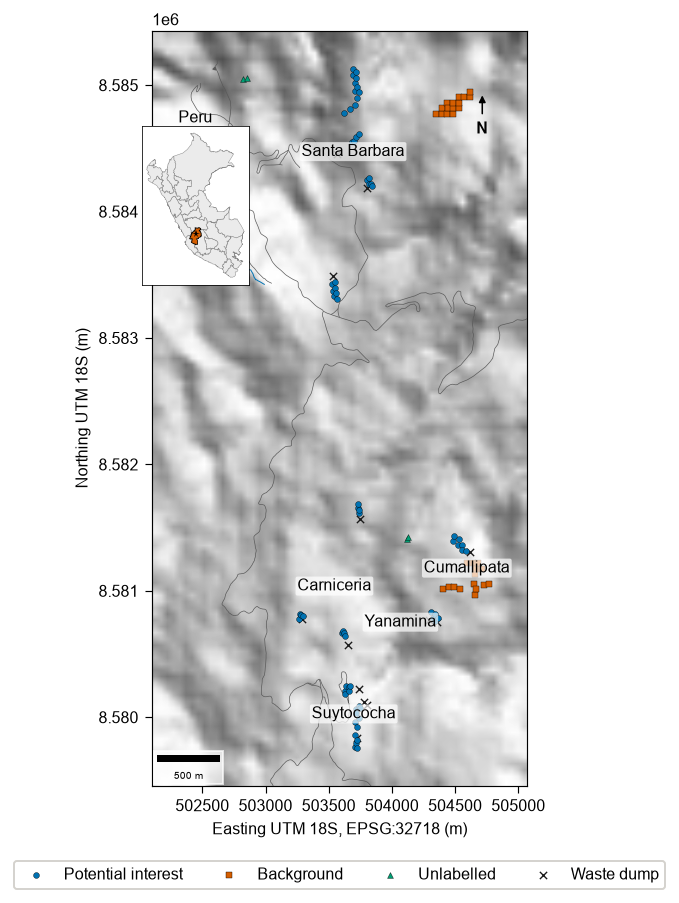


map versions produced: B (offline) always; A (basemap) True; C (OSM) True


In [63]:
OSM_OK = False
try:
    import osmnx as ox
    bbox_geo = (glon.min(), glat.min(), glon.max(), glat.max())
    t0 = time.time()
    roads = ox.features_from_bbox(bbox=bbox_geo, tags={"highway": True})
    water = ox.features_from_bbox(bbox=bbox_geo, tags={"waterway": True})
    print(f"OSM features downloaded in {time.time()-t0:.0f} s: "
          f"{len(roads)} highway, {len(water)} waterway")
    roads = roads.to_crs(CRS_UTM)
    water = water.to_crs(CRS_UTM)

    fig = plt.figure(figsize=(W15, W15 * 1.15), constrained_layout=True)
    ax = fig.add_subplot(111)
    ax.imshow(HILLSHADE, cmap="gray", extent=[e0, e1, n0, n1], origin="lower", alpha=0.7,
              zorder=0, interpolation="bilinear")
    roads.plot(ax=ax, color="0.35", linewidth=0.35, zorder=3)
    water.plot(ax=ax, color="#0072B2", linewidth=0.5, zorder=4)
    for st, mk, col, lab in [("potential_interest", "o", OI[0], "Potential interest"),
                             ("background", "s", OI[1], "Background"),
                             ("unlabelled", "^", OI[2], "Unlabelled")]:
        s = loc[loc.stratum == st]
        ax.scatter(s.easting, s.northing, marker=mk, s=9, facecolor=col, edgecolor="k",
                   linewidth=0.2, zorder=7, label=lab)
    w = workings[workings.feature_type == "waste_dump"]
    ax.scatter(w.easting, w.northing, marker="x", s=14, c="0.1", linewidth=0.7, zorder=6,
               label="Waste dump")
    for nm, (px, py) in PLACES.items():
        ax.annotate(nm, (px, py), fontsize=8, ha="center", va="center", zorder=8,
                    bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.7))
    ax.annotate("Huancavelica", HVCA, fontsize=8, fontweight="bold", ha="center", va="center",
                zorder=8, bbox=dict(boxstyle="round,pad=0.14", fc="white", ec="0.4", lw=0.3,
                                    alpha=0.85))
    ax.set_xlim(e0, e1)
    ax.set_ylim(n0, n1)
    ax.add_artist(ScaleBar(1, "m", location="lower left", box_alpha=0.7,
                           font_properties={"size": 5}))
    north_arrow(ax)
    ax.set_xlabel("Easting UTM 18S, EPSG:32718 (m)")
    ax.set_ylabel("Northing UTM 18S (m)")
    ax.set_aspect("equal")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), frameon=True, framealpha=0.88, edgecolor="#cfccc7", ncol=4, fontsize=8)
    peru_inset(fig, ax)
    save_fig(fig, "FIG16_site_map_versionC_osm")
    plt.show()
    OSM_OK = True
except Exception as exc:                                            # noqa: BLE001
    print("version C could not be produced:", repr(exc)[:200])

print(f"\nmap versions produced: B (offline) always; A (basemap) {BASEMAP_OK}; C (OSM) {OSM_OK}")

### 14.4 Posterior mean and uncertainty

Two panels per figure at most, and the extrapolation is masked: cells beyond 1.5 length scales
from the nearest sample are hatched, so interpolation between clusters cannot be mistaken for
evidence.

saved: FIG17_Hg_mean_and_uncertainty | width 140 mm | 600 dpi


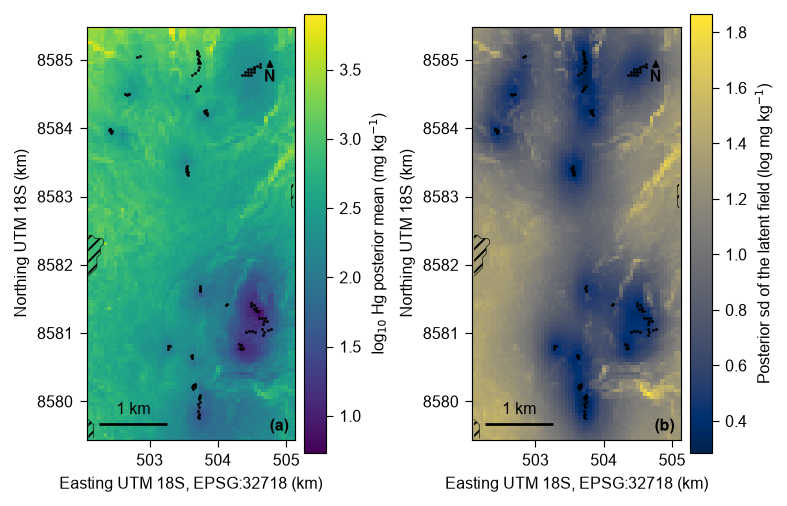

saved: FIG17_Pb_mean_and_uncertainty | width 140 mm | 600 dpi


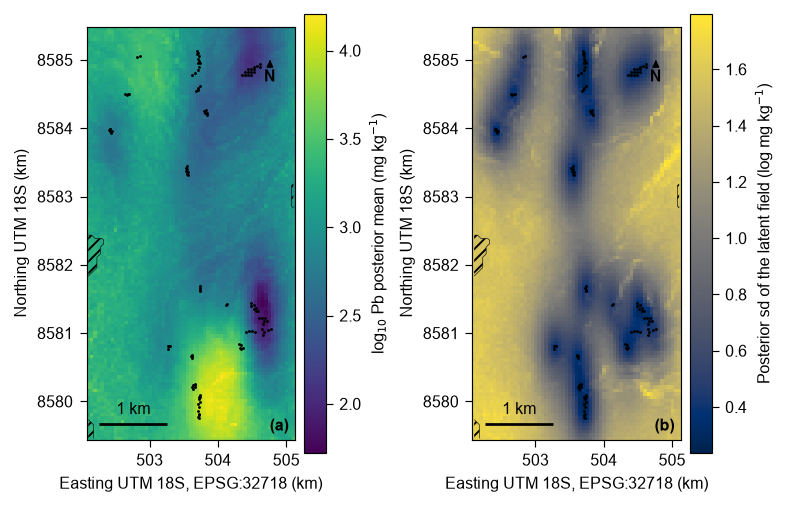

saved: FIG17_As_mean_and_uncertainty | width 140 mm | 600 dpi


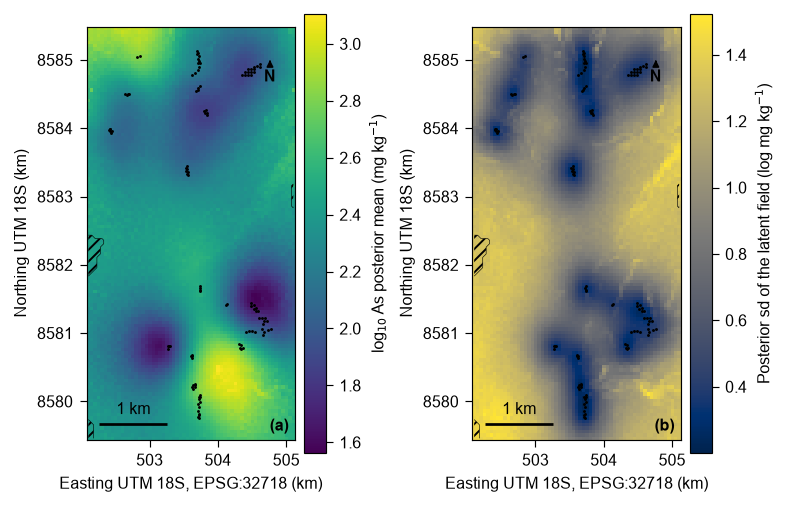

saved: FIG17_Ba_mean_and_uncertainty | width 140 mm | 600 dpi


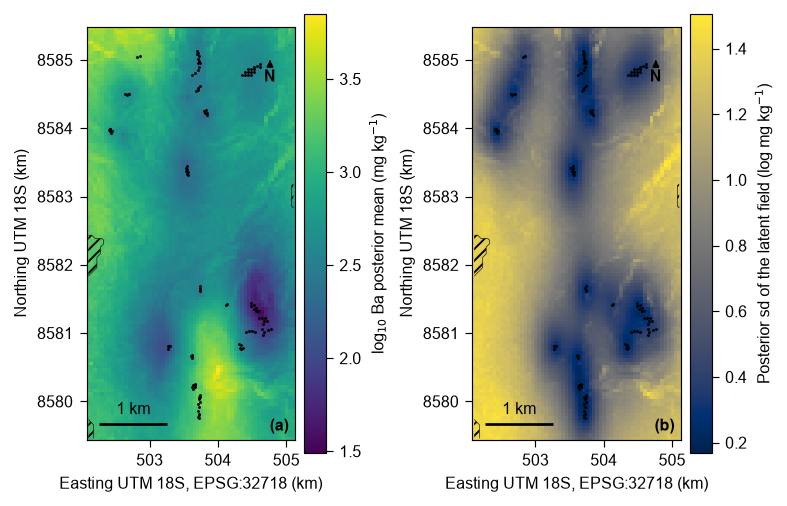

saved: FIG17_Cd_mean_and_uncertainty | width 140 mm | 600 dpi


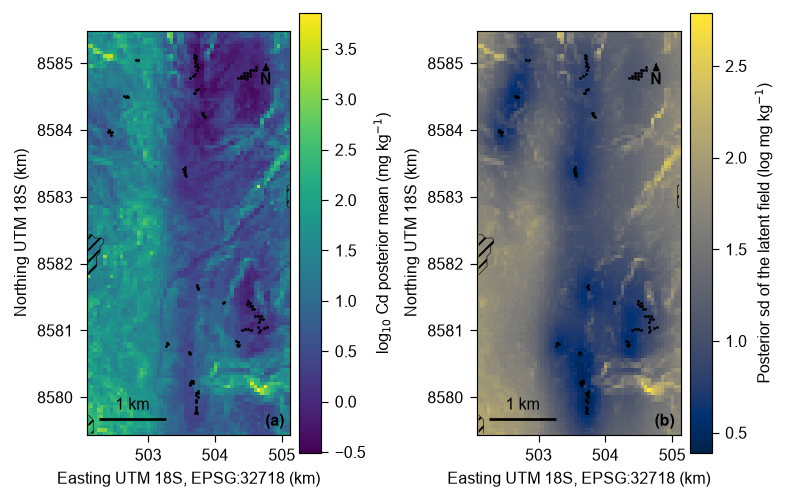

In [64]:
def map_panel(ax, values, cmap, label, *, log10=False, mask_extrap=True, vmin=None, vmax=None):
    v = values.reshape(len(gn), len(ge)).copy()
    if log10:
        v = np.log10(np.maximum(v, 1e-6))
    im = ax.pcolormesh(GE / 1000, GN / 1000, v, cmap=cmap, shading="auto", rasterized=True,
                       vmin=vmin, vmax=vmax, zorder=2)
    if mask_extrap:
        me = EXTRAP.reshape(len(gn), len(ge))
        ax.contourf(GE / 1000, GN / 1000, me.astype(float), levels=[0.5, 1.5], colors="none",
                    hatches=["////"], zorder=3)
        ax.contour(GE / 1000, GN / 1000, me.astype(float), levels=[0.5], colors="k",
                   linewidths=0.3, zorder=4)
    ax.scatter(loc.easting / 1000, loc.northing / 1000, s=2.2, c="k", marker="o", lw=0, zorder=7)
    ax.set_xlabel("Easting UTM 18S, EPSG:32718 (km)")
    ax.set_ylabel("Northing UTM 18S (km)")
    ax.set_aspect("equal")
    scale_bar(ax, 1.0)
    north_arrow(ax)
    return im


for a in MAIN_METALS:
    fig, axes = plt.subplots(1, 2, figsize=(W15, W15 * 1.05), constrained_layout=True)
    im = map_panel(axes[0], maps[f"{a}_mean"], "viridis", "", log10=True)
    cb = fig.colorbar(im, ax=axes[0], shrink=0.55, pad=0.02)
    cb.set_label(f"log$_{{10}}$ {a} posterior mean (mg kg$^{{-1}}$)")
    axes[0].text(0.97, 0.015, "(a)", transform=axes[0].transAxes, ha="right", va="bottom",
                 fontweight="bold")

    im = map_panel(axes[1], maps[f"{a}_sd_f"], "cividis", "")
    cb = fig.colorbar(im, ax=axes[1], shrink=0.55, pad=0.02)
    cb.set_label("Posterior sd of the latent field (log mg kg$^{-1}$)")
    axes[1].text(0.97, 0.015, "(b)", transform=axes[1].transAxes, ha="right", va="bottom",
                 fontweight="bold")
    save_fig(fig, f"FIG17_{a}_mean_and_uncertainty")
    plt.show()

### 14.5 Exceedance probability

For cadmium both thresholds are mapped, agricultural (1.4) and residential (10), and presented as
a **regulatory sensitivity analysis**: the site has dwellings within 3 km and also farmland and
high-Andean wetlands, so which standard applies is a decision, not a fact. Both are shown.

saved: FIG18_Hg_exceedance | width 140 mm | 600 dpi


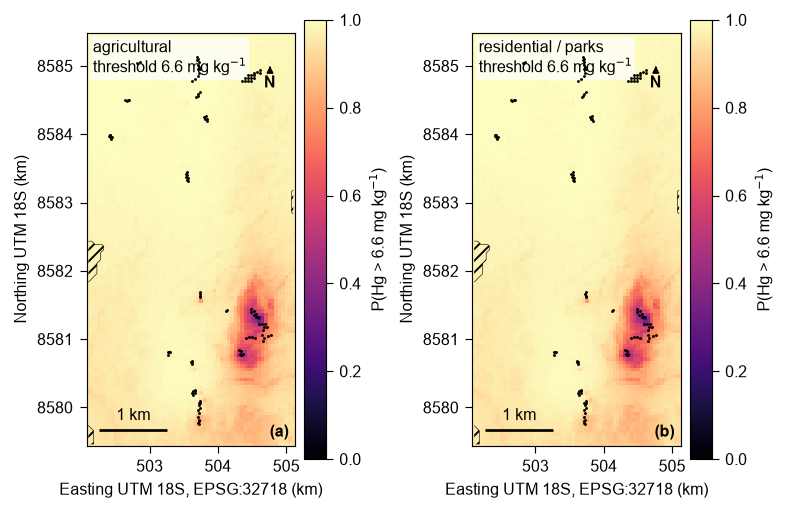

saved: FIG18_Pb_exceedance | width 140 mm | 600 dpi


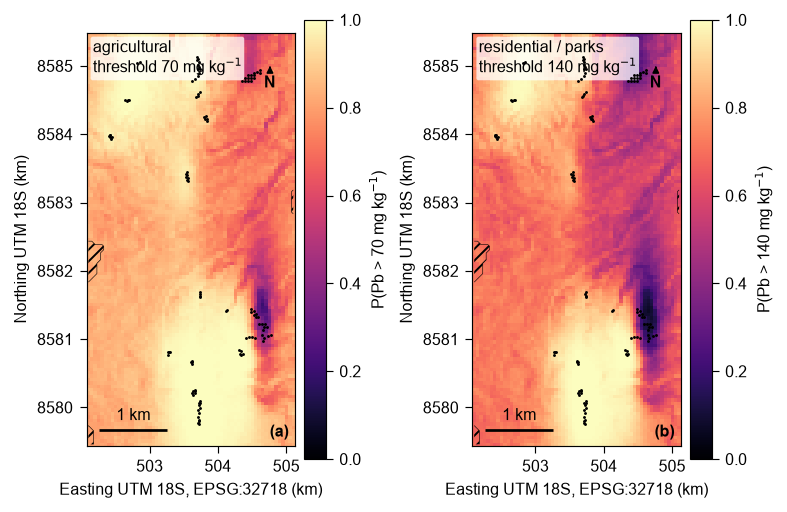

saved: FIG18_As_exceedance | width 140 mm | 600 dpi


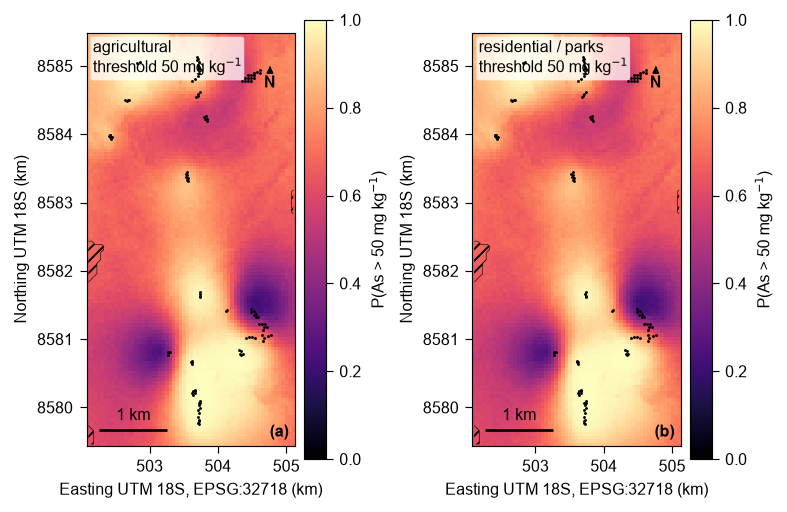

saved: FIG18_Ba_exceedance | width 140 mm | 600 dpi


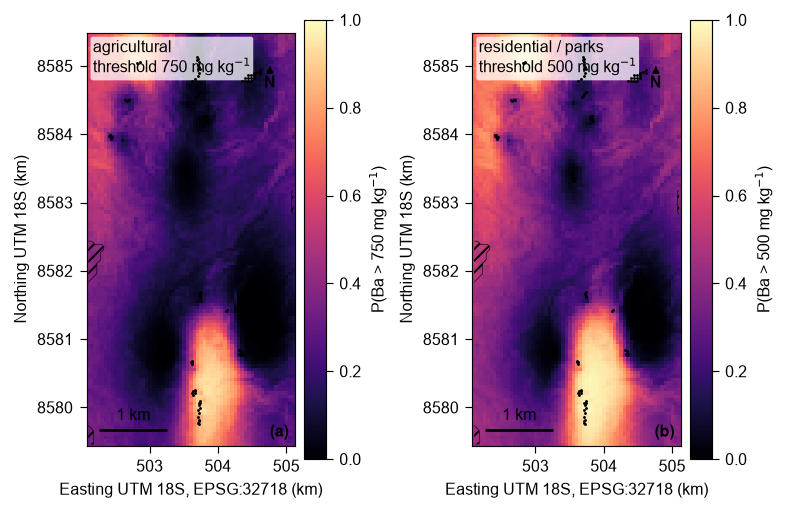

saved: FIG18_Cd_exceedance | width 140 mm | 600 dpi


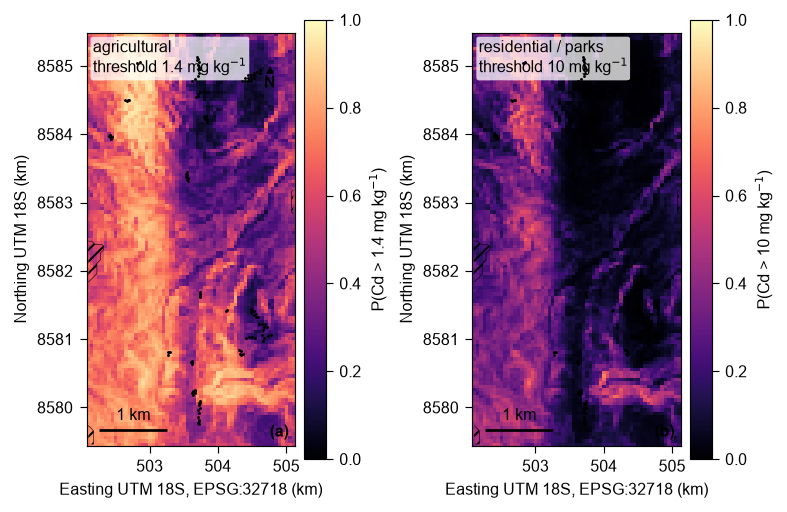

In [65]:
for a in MAIN_METALS:
    fig, axes = plt.subplots(1, 2, figsize=(W15, W15 * 1.05), constrained_layout=True)
    for ax, key, thr, tag in [(axes[0], "p_agri", ECA[a][0], "agricultural"),
                              (axes[1], "p_resid", ECA[a][1], "residential / parks")]:
        im = map_panel(ax, maps[f"{a}_{key}"], "magma", "", vmin=0, vmax=1)
        cb = fig.colorbar(im, ax=ax, shrink=0.55, pad=0.02)
        cb.set_label(f"P({a} > {thr:g} mg kg$^{{-1}}$)")
        ax.text(0.03, 0.985, f"{tag}\nthreshold {thr:g} mg kg$^{{-1}}$", transform=ax.transAxes,
                ha="left", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))
    axes[0].text(0.97, 0.015, "(a)", transform=axes[0].transAxes, ha="right", va="bottom",
                 fontweight="bold")
    axes[1].text(0.97, 0.015, "(b)", transform=axes[1].transAxes, ha="right", va="bottom",
                 fontweight="bold")
    save_fig(fig, f"FIG18_{a}_exceedance")
    plt.show()

## 15. Closing summary of the notebook

In [66]:
summary = {
    "seed": SEED,
    "n_locations": int(len(XY)),
    "kernel": h2["kernel"],
    "anisotropy_ratio": ANISO_MAX,
    "recovery_test_passes": bool(RECOVERY_PASSES),
    "all_main_models_converge": bool(diag["passes"].all()),
    "stratum_support_separable": bool(SEPARABLE),
    "masking_cells": int(len(design)),
    "masking_divergence_slopes_significant": int(slopes["diverges"].sum()),
    "coverage_80pct_all_replicates_won": bool(CAL80_ALL_WON),
    "coverage_80pct_comparisons": int(len(CAL80)),
    "coverage_80pct_max_p": float(CAL80["p_wilcoxon"].max()),
    "picp95_at_80pct": {f"{r.metal}|{r.model}": float(r.picp95) for r in
                        h6[h6["level"] == 0.8].groupby(["metal", "model"], as_index=False)
                        ["picp95"].mean().itertuples()},
    "masking_slopes_total": int(len(slopes)),
    "cv_best_by_joint_score": {m: str(g.loc[g["joint_log_score"].idxmax(), "model"])
                               for m, g in cvsum.groupby("metal")},
    "n_map_cells": int(N_CELLS),
    "map_samples": int(N_MAP_SAMPLES),
    "grid_resolution_m": float(GRID_RES_M),
    "exceedance_max": {a: float(maps[f"{a}_p_agri"].max()) for a in MAIN_METALS},
    "pct_domain_above_half": {a: float(100 * (maps[f"{a}_p_agri"] > 0.5).mean())
                              for a in MAIN_METALS},
    "lmc_identified": bool(lmc["identified"].any()),
    "map_versions": {"A_basemap": BASEMAP_OK, "B_offline": True, "C_osm": OSM_OK},
    "monitoring_reduction_20_points_pct": float(red.loc[20, "reduction_pct"]),
    "predictor_verification_max_error": float(VERIFY_ERR),
}
(DIR_OUT / "nb02_summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False),
                                           encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "seed": 20260906,
  "n_locations": 114,
  "kernel": "anisotropic ARD Matern 5/2",
  "anisotropy_ratio": 3.552,
  "recovery_test_passes": true,
  "all_main_models_converge": false,
  "stratum_support_separable": true,
  "masking_cells": 120,
  "masking_divergence_slopes_significant": 3,
  "coverage_80pct_all_replicates_won": true,
  "coverage_80pct_comparisons": 6,
  "coverage_80pct_max_p": 0.001953125,
  "picp95_at_80pct": {
    "As|GP with L/2": 0.6601093351093351,
    "As|censored GP": 0.9527972027972028,
    "As|ordinary kriging L/2": 0.5234543234543234,
    "Hg|GP with L/2": 0.47316849816849815,
    "Hg|censored GP": 0.8316516816516817,
    "Hg|ordinary kriging L/2": 0.4785880785880786,
    "Pb|GP with L/2": 0.3405261405261405,
    "Pb|censored GP": 0.7383893883893884,
    "Pb|ordinary kriging L/2": 0.35235320235320233
  },
  "masking_slopes_total": 12,
  "cv_best_by_joint_score": {
    "As": "GP with L/2",
    "Cd": "global mean with L/2",
    "Hg": "censored GP",
    "Pb": "c